# Introduction to Machine Learning - Final Project

## Course Cancellation Prediction

### Group 04

Submitted by:

* Eden Lagziel
* Ron Kotser

---

## Project Overview

The goal of this project is to build a machine learning model that predicts the probability that a course registration will be cancelled.

The target variable is:

* `Dropped_Course`

The final output of the model is a cancellation probability for each observation in the external test set.

---

## Project Workflow

The notebook follows a CRISP-DM-inspired workflow, adapted to the structure of the assignment and the available dataset.

The main stages of the notebook are:

1.⁠ ⁠Business understanding and definition of the prediction task

2.⁠ ⁠Data loading and train-validation split

3.⁠ ⁠Data understanding through exploratory data analysis

4.⁠ ⁠Data cleaning and feature-engineering decisions

5.⁠ ⁠Construction of a preprocessing pipeline

6.⁠ ⁠Training and comparison of several classification models

7.⁠ ⁠Hyperparameter tuning and final model selection

8.⁠ ⁠Model evaluation using ROC-AUC, confusion matrix, classification report, cross-validation, and SHAP values interpretation

9.⁠ ⁠Generation of probability predictions for the external test set

---

The main evaluation metric used throughout the project is ROC-AUC, since the task focuses on predicting cancellation probabilities rather than only assigning hard class labels.

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif
from sklearn.base import BaseEstimator, TransformerMixin

import shap
shap.initjs()


In [177]:
RANDOM_STATE = 42
VALIDATION_SIZE = 0.20
TARGET = "Dropped_Course"

pd.set_option("display.max_columns", None)

In [178]:
data = pd.read_csv("Train_Data.csv")

X = data.drop(columns=[TARGET])
y = data[TARGET]

print("Full training data shape:", data.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

data.head()

Full training data shape: (63464, 29)
Features shape: (63464, 28)
Target shape: (63464,)


,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,Welcome_Gift_Type,Requested_Lab_Config,Assigned_Lab_Config,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,0,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,USB Drive,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,0,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


## Train-Validation Split

Before performing EDA and preprocessing decisions, the provided training data was split into a training set and a validation set.

All exploratory analysis and preprocessing decisions are based only on the training split, in order to avoid data leakage from the validation set.

A stratified split was used to preserve the target class distribution in both subsets.

In [179]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (50771, 28)
X_val shape: (12693, 28)
y_train shape: (50771,)
y_val shape: (12693,)


## Initial Data Structure

We first inspect the structure of the training split, including column types and non-null counts. This helps identify numeric, categorical, date-based, and missing-value patterns before detailed exploratory analysis.

In [180]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 50771 entries, 8022 to 41357
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    50771 non-null  int64  
 1   Professionals_Count          50771 non-null  int64  
 2   Students_Count               50767 non-null  float64
 3   Observers_Count              50771 non-null  int64  
 4   Course_Start_Date            50771 non-null  str    
 5   Practical_Hours              50771 non-null  int64  
 6   Theory_Hours                 50771 non-null  int64  
 7   Registration_Days_Before     48645 non-null  float64
 8   Origin_Country               50333 non-null  str    
 9   Catering_Package             50434 non-null  str    
 10  Welcome_Gift_Type            50771 non-null  str    
 11  Requested_Lab_Config         49377 non-null  str    
 12  Assigned_Lab_Config          50771 non-null  str    
 13  Prev_Course_Dropouts         

# Part A - Data Understanding, Exploratory Data Analysis and Missing Values

## Data Understanding and Exploratory Data Analysis

In this section, we analyze the training split in order to understand the structure, quality, and main patterns of the data before building the preprocessing pipeline and training the models.

The exploratory analysis focuses on:

- The distribution of the target variable
- Missing values
- Basic descriptive statistics
- Numeric feature distributions
- Sparsity and zero-inflated features
- Categorical value consistency
- Initial relationships between selected features and the target variable

All analyses in this section are performed only on the training split, in order to avoid data leakage from the validation set.

## Target Distribution

Before analyzing the explanatory variables, we examine the distribution of the target variable, `Dropped_Course`.

This helps us understand whether the classification problem is balanced or imbalanced, and supports the choice of evaluation metrics later in the modeling stage.

In [181]:
# ============================================================
# 1. Target Distribution
# ============================================================
target_distribution = y_train.value_counts().to_frame("count")
target_distribution["proportion"] = y_train.value_counts(normalize=True)

target_distribution

,count,proportion
Dropped_Course,,
0,29732,0.58561
1,21039,0.41439


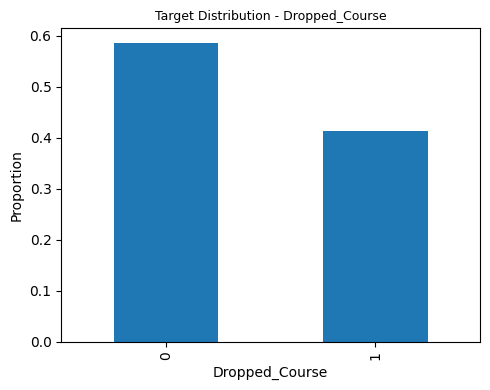

In [182]:
plt.figure(figsize=(5, 4))

y_train.value_counts(normalize=True).sort_index().plot(kind="bar")

plt.title("Target Distribution - Dropped_Course")
plt.xlabel("Dropped_Course")
plt.ylabel("Proportion")

plt.tight_layout()
plt.show()

The target variable is moderately imbalanced, with the non-cancelled class being more frequent than the cancelled class.

Since the task is focused on predicting cancellation probabilities rather than only assigning class labels, ROC-AUC will be used as the main evaluation metric. In addition, precision, recall, F1-score, and the confusion matrix will be examined later to better understand classification performance.

## Basic Descriptive Statistics

We examine descriptive statistics for numeric features in the training split, including ranges, means, standard deviations, quartiles, and extreme values.

This step helps identify skewed distributions, sparse variables, and potentially invalid values that require further investigation.

In [183]:
# ============================================================
# 4. Basic Descriptive Statistics
# ============================================================

# Descriptive statistics for numeric columns.
# This helps us understand ranges, averages, medians, and possible outliers.
X_train.describe()

,Client_ID,Professionals_Count,Students_Count,Observers_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Returning_Client,Agent_ID,Company_ID,Daily_Tuition_Cost
count,50771.000000,50771.000000,50767.000000,50771.000000,50771.000000,50771.000000,48645.000000,50771.000000,50771.000000,50771.000000,49952.000000,50771.000000,50771.000000,50771.000000,41843.000000,2476.000000,50706.000000
mean,39750.063855,1.833704,8.553824,0.005456,6.785941,2.165725,103.203721,0.095606,0.123023,0.513246,0.026445,4.003526,0.179965,0.026748,197.662381,5118.024637,98.872264
std,22881.558843,0.507865,290.882083,0.094093,220.691243,1.470058,109.548377,0.436784,1.547270,0.764046,0.160956,23.206229,0.586646,0.161346,47.283238,70.391142,43.109057
min,1.000000,0.000000,0.000000,0.000000,-5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,5003.000000,0.000000
25%,19947.500000,2.000000,0.000000,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5035.000000,75.000000
50%,39783.000000,2.000000,0.000000,0.000000,1.000000,2.000000,65.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,184.000000,5142.000000,94.500000
75%,59573.000000,2.000000,0.000000,0.000000,1.000000,3.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,218.000000,5181.000000,117.000000
max,79330.000000,4.000000,9999.000000,10.000000,10000.000000,41.000000,629.000000,21.000000,61.000000,5.000000,3.000000,391.000000,21.000000,1.000000,322.000000,5206.000000,5400.000000


The descriptive statistics reveal several potential data-quality issues and highly skewed numeric features. For example, some count and duration variables contain extreme maximum values that are not business-plausible and will be examined in the outlier analysis section.

## Numeric Feature Distributions

We visualize the distributions of numeric variables in the training split using histograms.

This step helps identify:

- Skewed distributions
- Zero-inflated variables
- Unusual value ranges
- Potential invalid values or outliers
- Features that may later require transformation or binarization

At this stage, the plots are used only for exploratory analysis. Any preprocessing decisions will later be implemented consistently inside the preprocessing pipeline or documented as training-data cleaning decisions.

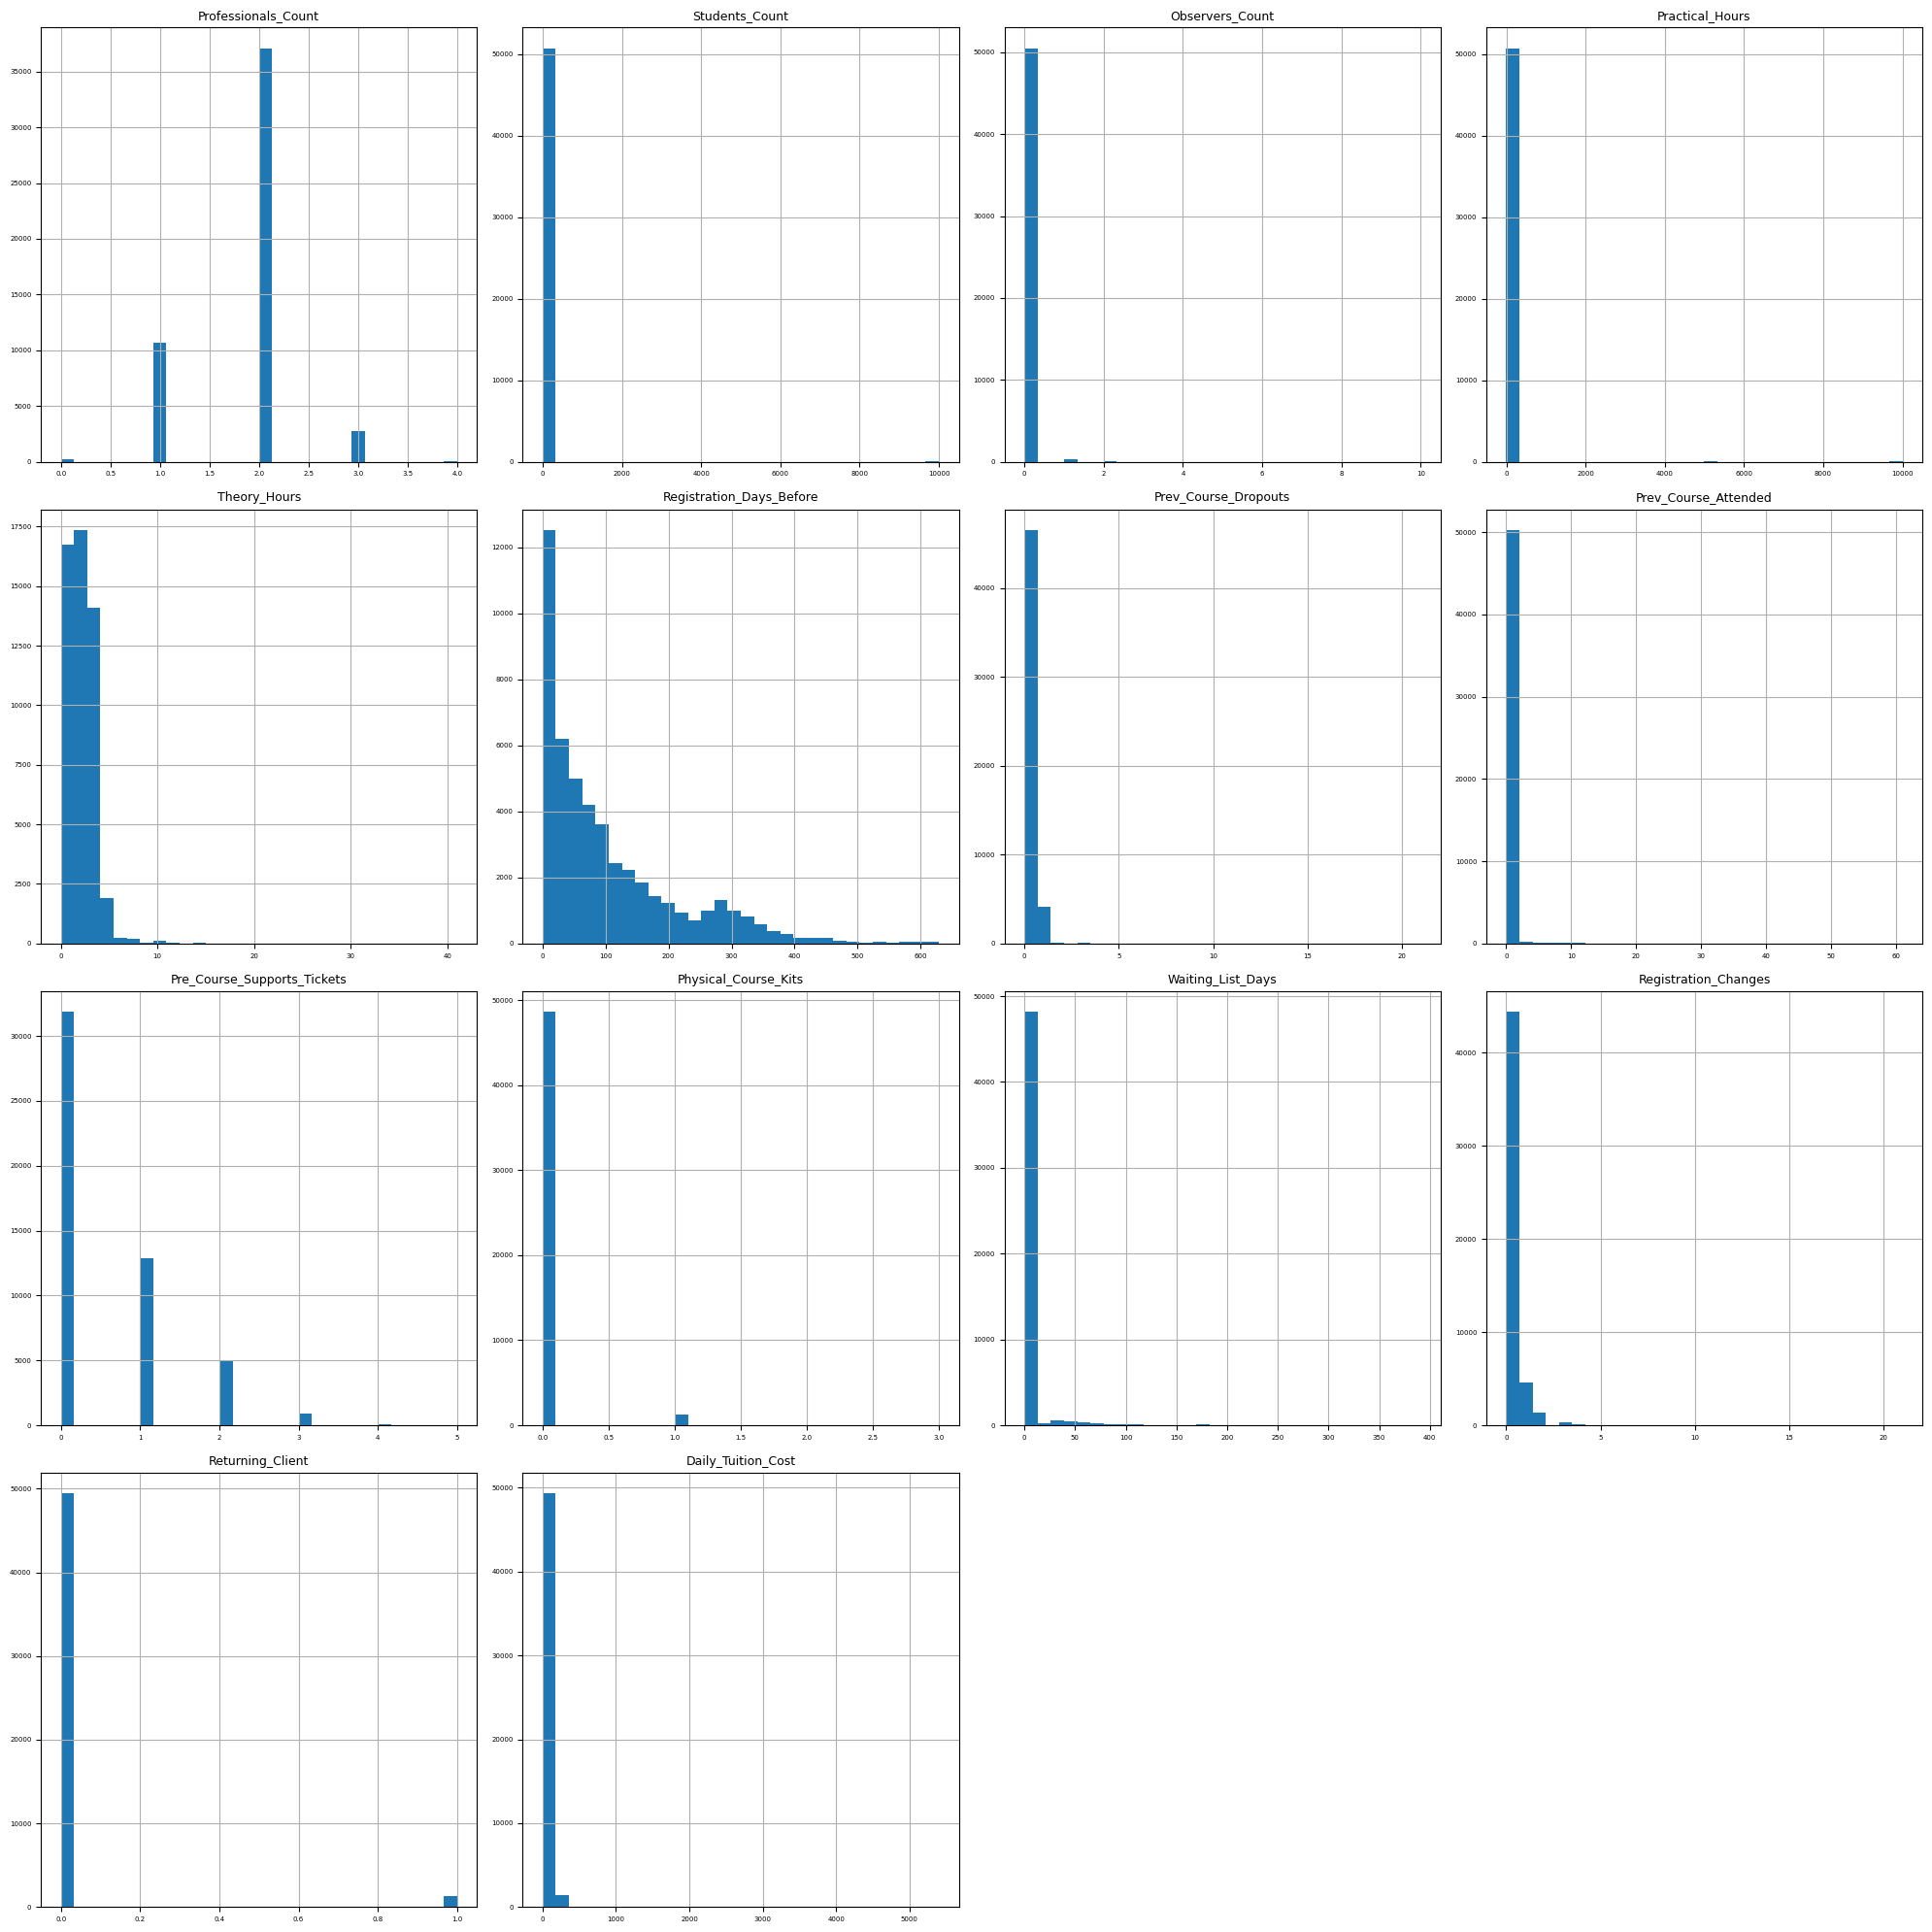

In [184]:
# ============================================================
# 5. Numeric Distributions
# ============================================================
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
id_like_cols = ["Client_ID", "Company_ID", "Agent_ID"]

numeric_cols_for_distribution = [
    col for col in numeric_cols
    if col not in id_like_cols
]

plt.rcParams.update({"axes.titlesize": 9})

X_train[numeric_cols_for_distribution].hist(
    figsize=(20, 20),
    xlabelsize=5,
    ylabelsize=5,
    bins=30
)

plt.tight_layout()
plt.show()

### Numeric Distribution Conclusions

The numeric feature distributions reveal several important patterns.

First, several variables are highly zero-inflated, meaning that most observations contain a value of zero and only a small number contain positive values. These variables will be examined further in the sparsity analysis section.

Second, some numeric variables are strongly right-skewed, especially features related to registration timing and count-based behavior. These features may require transformation, such as `log1p`, or conversion into binary indicators.

Finally, several variables contain extreme values that are not immediately business-plausible. These values will be examined more carefully in the numeric outlier analysis section before deciding whether they should be removed, capped, transformed, or treated as invalid data.

## Sparsity Analysis

After examining the numeric distributions, we further analyze selected numeric and binary features that may contain many zero values.

A high percentage of zeros does not necessarily mean that a feature is uninformative. In some cases, the rare non-zero values may carry important predictive information, especially when they represent previous activity, waiting-list behavior, registration changes, or operational requirements.

Therefore, at this stage, sparse features are only flagged for further investigation and are not removed automatically.

In [185]:
# ============================================================
# 6. Sparsity Analysis - Percentage of Zeros
# ============================================================

sparse_cols = [
    "Registration_Changes",
    "Returning_Client",
    "Daily_Tuition_Cost",
    "Waiting_List_Days",
    "Physical_Course_Kits",
    "Prev_Course_Attended",
    "Prev_Course_Dropouts",
    "Practical_Hours",
    "Students_Count",
    "Observers_Count"
]

# Calculate the percentage of zero values in each sparse column.
zeros_pct = (X_train[sparse_cols] == 0).mean() * 100

zeros_sorted = (
    zeros_pct
    .to_frame(name="zeros_percentage")
    .sort_values("zeros_percentage", ascending=False)
)

zeros_sorted

,zeros_percentage
Observers_Count,99.499714
Prev_Course_Attended,98.002797
Returning_Client,97.325245
Physical_Course_Kits,95.790904
Waiting_List_Days,94.672155
Students_Count,93.939454
Prev_Course_Dropouts,91.640897
Registration_Changes,87.408166
Practical_Hours,48.405586
Daily_Tuition_Cost,1.687971


The following visualization shows the percentage of zero values in each selected feature.  
A 90% threshold is marked as a reference point for identifying highly sparse features.

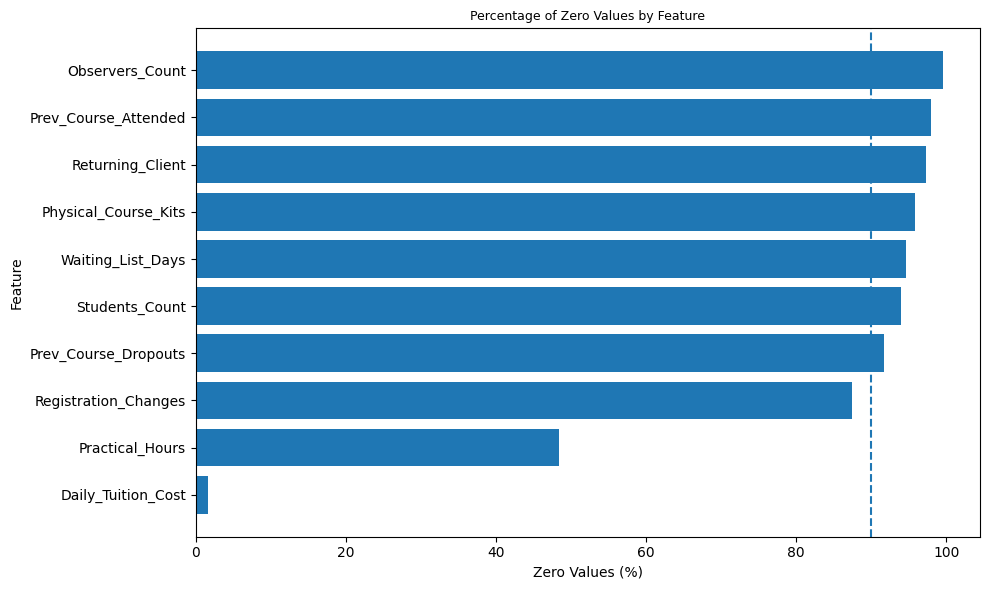

In [186]:
# ============================================================
# 7. Sparsity Visualization
# ============================================================

zeros_sorted_for_plot = zeros_sorted.sort_values(
    "zeros_percentage",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    zeros_sorted_for_plot.index,
    zeros_sorted_for_plot["zeros_percentage"]
)

plt.axvline(
    x=90,
    linestyle="--"
)

plt.title("Percentage of Zero Values by Feature")
plt.xlabel("Zero Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [187]:
# ============================================================
# 8. Flag High-Zero Features for Later Consideration
# ============================================================

high_zero_features = (
    zeros_sorted[zeros_sorted["zeros_percentage"] >= 90]
    .index
    .tolist()
)

print(f"Number of high-zero features: {len(high_zero_features)}")
print(high_zero_features)

Number of high-zero features: 7
['Observers_Count', 'Prev_Course_Attended', 'Returning_Client', 'Physical_Course_Kits', 'Waiting_List_Days', 'Students_Count', 'Prev_Course_Dropouts']


### Sparsity Analysis Conclusions

Several features contain a very high percentage of zero values, indicating strong sparsity or zero inflation.

These features will not be removed automatically, since their non-zero values may still contain meaningful business information. For example, previous course attendance, previous dropouts, registration changes, waiting-list behavior, and physical kit requirements may represent rare but important events.

Instead, highly sparse count features will be examined further. Depending on their distribution and relationship with the target variable, some of them may later be converted into binary indicators that preserve the main signal while reducing sparsity.

##numeric correlation analysis

In this section, we examine linear relationships between numeric features and the target variable.

The goal is to identify:

- Numeric features that are more strongly associated with `Dropped_Course`
- Potential redundancy between numeric features
- Initial patterns that may be useful for later feature-engineering decisions

Identifier-like columns are excluded from the correlation analysis, since their numeric values do not represent meaningful continuous quantities.



In [188]:
# Select numeric columns for correlation analysis

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

# Exclude identifier-like columns
id_like_cols = [
    "Client_ID",
    "Company_ID",
    "Agent_ID"
]

numeric_corr_cols = [
    col for col in numeric_cols
    if col not in id_like_cols
]

numeric_corr_cols

['Professionals_Count',
 'Students_Count',
 'Observers_Count',
 'Practical_Hours',
 'Theory_Hours',
 'Registration_Days_Before',
 'Prev_Course_Dropouts',
 'Prev_Course_Attended',
 'Pre_Course_Supports_Tickets',
 'Physical_Course_Kits',
 'Waiting_List_Days',
 'Registration_Changes',
 'Returning_Client',
 'Daily_Tuition_Cost']

In [189]:
# Create a temporary dataframe for correlation analysis
corr_data = X_train[numeric_corr_cols].copy()
corr_data["Dropped_Course"] = y_train

corr_matrix = corr_data.corr(method="pearson")

# Identify strongest pairwise correlations between numeric features

numeric_feature_corr = corr_matrix.drop(
    index="Dropped_Course",
    columns="Dropped_Course"
)

upper_triangle_mask = np.triu(
    np.ones(numeric_feature_corr.shape),
    k=1
).astype(bool)

strong_pairwise_correlations = (
    numeric_feature_corr
    .where(upper_triangle_mask)
    .stack()
    .reset_index()
)

strong_pairwise_correlations.columns = [
    "feature_1",
    "feature_2",
    "pearson_correlation"
]

strong_pairwise_correlations["absolute_correlation"] = (
    strong_pairwise_correlations["pearson_correlation"].abs()
)

strong_pairwise_correlations = (
    strong_pairwise_correlations
    .sort_values("absolute_correlation", ascending=False)
    .head(10)
)

strong_pairwise_correlations

,feature_1,feature_2,pearson_correlation,absolute_correlation
110,Prev_Course_Attended,Returning_Client,0.443719,0.443719
91,Prev_Course_Dropouts,Prev_Course_Attended,0.367656,0.367656
96,Prev_Course_Dropouts,Returning_Client,0.245439,0.245439
13,Professionals_Count,Daily_Tuition_Cost,0.226151,0.226151
80,Registration_Days_Before,Waiting_List_Days,0.221273,0.221273
78,Registration_Days_Before,Pre_Course_Supports_Tickets,-0.176228,0.176228
76,Registration_Days_Before,Prev_Course_Dropouts,0.168328,0.168328
125,Pre_Course_Supports_Tickets,Daily_Tuition_Cost,0.164375,0.164375
8,Professionals_Count,Pre_Course_Supports_Tickets,0.161181,0.161181
83,Registration_Days_Before,Daily_Tuition_Cost,-0.160242,0.160242


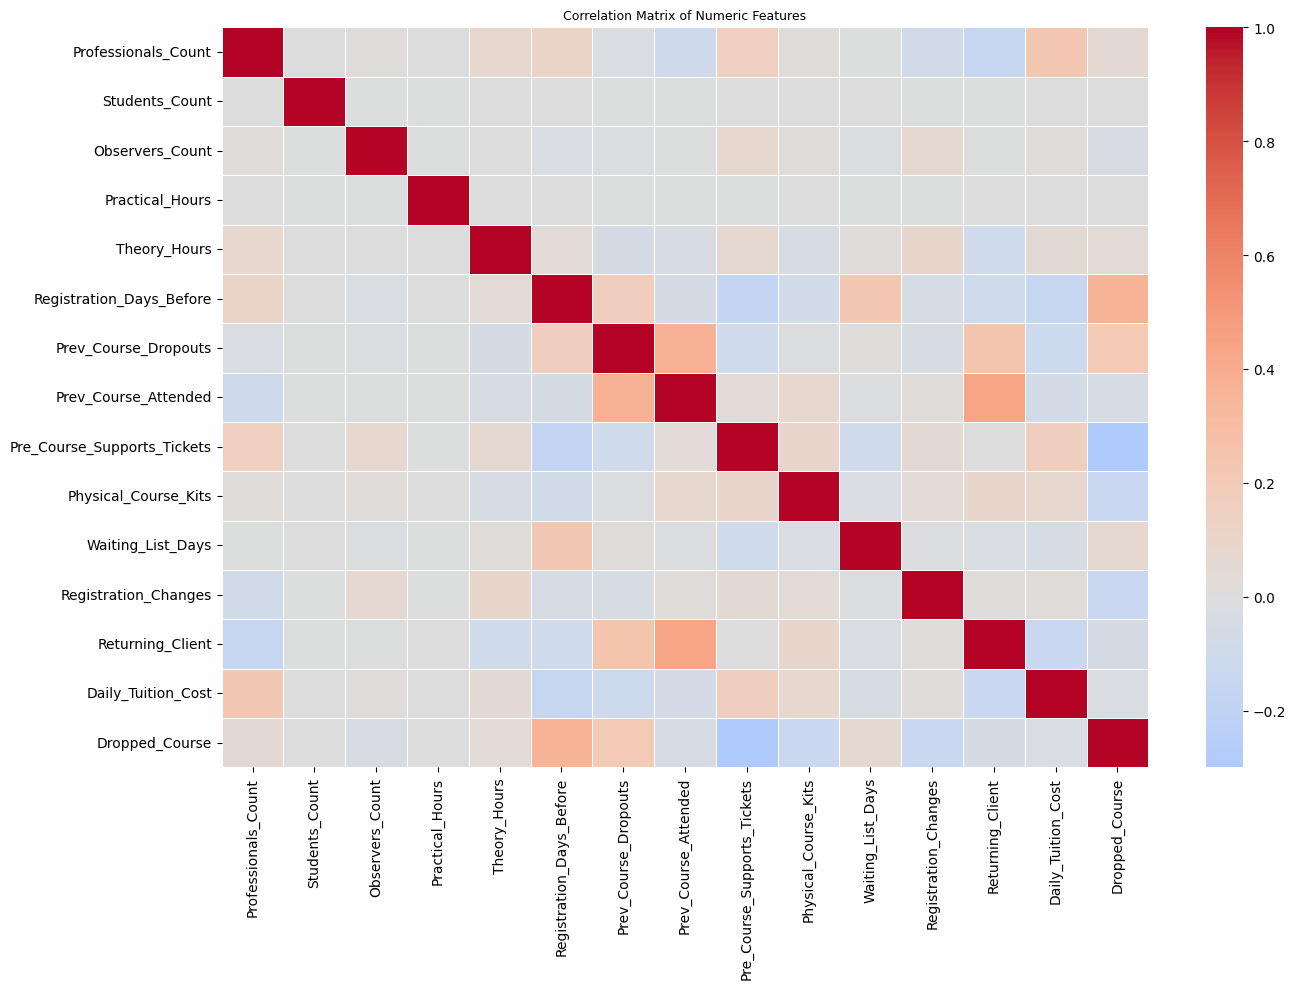

In [190]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

In [191]:
target_correlation = (
    corr_matrix["Dropped_Course"]
    .drop("Dropped_Course")
    .to_frame(name="pearson_correlation_with_target")
)

target_correlation["absolute_correlation"] = (
    target_correlation["pearson_correlation_with_target"].abs()
)

target_correlation = target_correlation.sort_values(
    "absolute_correlation",
    ascending=False
)

target_correlation

,pearson_correlation_with_target,absolute_correlation
Registration_Days_Before,0.351319,0.351319
Pre_Course_Supports_Tickets,-0.299710,0.299710
Prev_Course_Dropouts,0.203728,0.203728
Registration_Changes,-0.147032,0.147032
Physical_Course_Kits,-0.138375,0.138375
Waiting_List_Days,0.068491,0.068491
Returning_Client,-0.059163,0.059163
Professionals_Count,0.055794,0.055794
Prev_Course_Attended,-0.050010,0.050010
Theory_Hours,0.044261,0.044261


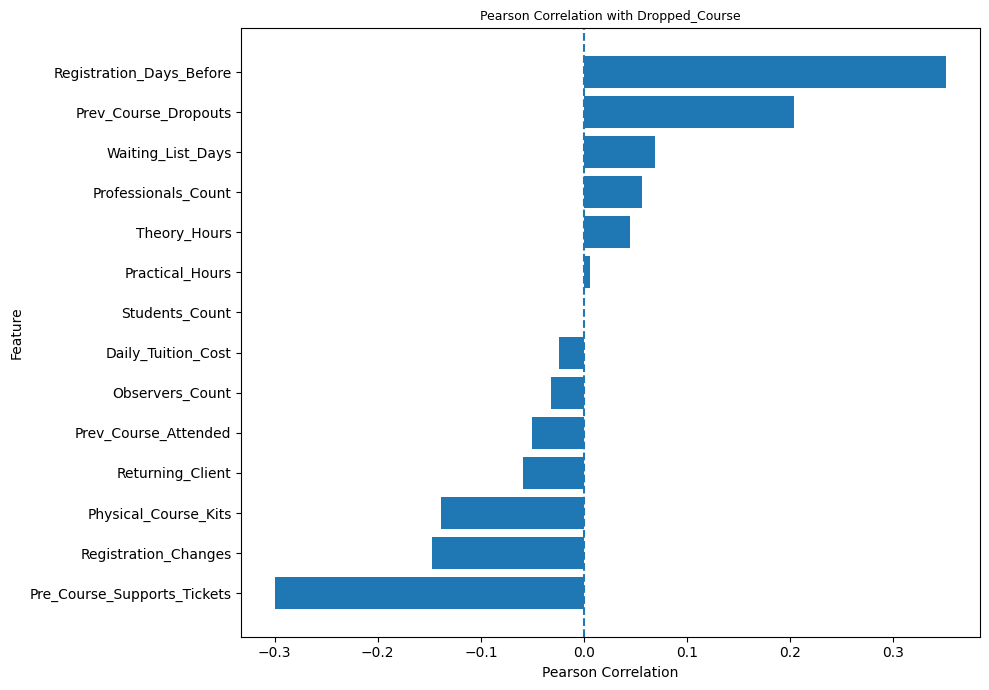

In [192]:
target_correlation_for_plot = target_correlation.sort_values(
    "pearson_correlation_with_target"
)

plt.figure(figsize=(10, 7))

plt.barh(
    target_correlation_for_plot.index,
    target_correlation_for_plot["pearson_correlation_with_target"]
)

plt.axvline(0, linestyle="--")

plt.title("Pearson Correlation with Dropped_Course")
plt.xlabel("Pearson Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Numeric Correlation Analysis Conclusions

The numeric correlation analysis was used to examine both relationships between numeric features and the target variable, and relationships among numeric features.

The strongest positive correlation with `Dropped_Course` is observed for `Registration_Days_Before` (`r ≈ 0.35`). This suggests that earlier registrations are associated with a higher cancellation probability.

`Prev_Course_Dropouts` also shows a positive correlation with the target (`r ≈ 0.20`), which is consistent with the business intuition that clients with previous dropout history may be more likely to cancel again.

The strongest negative correlation is observed for `Pre_Course_Supports_Tickets` (`r ≈ -0.30`). This suggests that clients with more pre-course support interactions are associated with a lower cancellation probability, possibly reflecting higher engagement or better operational alignment before the course.

Most other numeric features show weak linear correlations with the target. This does not necessarily mean that they are uninformative, since non-linear models may still capture useful patterns, thresholds, or interactions between features.

The pairwise correlation analysis between numeric features does not show severe multicollinearity.

Furtheremore, the analysis shows moderate correlations between several history-related variables, especially `Returning_Client`, `Prev_Course_Attended`, and `Prev_Course_Dropouts`.

This is expected, since all three variables describe different aspects of previous client interaction with the company.

However, correlation alone is not sufficient to determine how these features should be treated. Therefore, their consistency and relationship with the target variable are examined more directly in the following history-specific EDA sections.

No numeric features are removed based only on the correlation analysis. The findings are used as exploratory evidence for later preprocessing, feature-engineering, and modeling decisions.

## Top Numeric Features vs Target

The numeric correlation analysis showed that several numeric features have the strongest relative association with `Dropped_Course` among the numeric variables.

In this section, we examine these features more directly by grouping their values into bins and calculating the cancellation probability within each bin.

The goal is to understand whether the relationship suggested by the correlation analysis is also visible across value ranges, rather than relying only on a single linear correlation coefficient.

History-related variables are analyzed separately in the dedicated client-history EDA sections.

In [193]:
# ============================================================
# Top Numeric Features vs Target - EDA
# ============================================================

top_numeric_target_cols = [
    "Registration_Days_Before",
    "Pre_Course_Supports_Tickets",
    "Registration_Changes"
]

top_numeric_target_cols = [
    col for col in top_numeric_target_cols
    if col in X_train.columns
]

top_numeric_target_cols

['Registration_Days_Before',
 'Pre_Course_Supports_Tickets',
 'Registration_Changes']

In [194]:
def numeric_feature_target_bins(feature, n_bins=15, min_count_reliable=30):
    """
    Summarize cancellation probability across value ranges of a numeric feature.

    This function is used for EDA only.
    Missing values are excluded here because missingness is analyzed separately
    in the Missing Values section.
    """

    temp = pd.DataFrame({
        feature: X_train[feature],
        "Dropped_Course": y_train
    }).dropna(subset=[feature])

    if temp[feature].nunique() <= n_bins:
        temp["value_bin"] = temp[feature].astype("string")
    else:
        temp["value_bin"] = pd.qcut(
            temp[feature],
            q=n_bins,
            duplicates="drop"
        ).astype("string")

    summary = (
        temp
        .groupby("value_bin", observed=False)
        .agg(
            count=("Dropped_Course", "count"),
            cancellation_probability=("Dropped_Course", "mean"),
            min_value=(feature, "min"),
            max_value=(feature, "max"),
            mean_value=(feature, "mean")
        )
        .reset_index()
    )

    summary["difference_from_overall_rate"] = (
        summary["cancellation_probability"] - y_train.mean()
    )

    summary["low_count_flag"] = summary["count"] < min_count_reliable
    summary = summary.sort_values("min_value").reset_index(drop=True)
    return summary

In [195]:
for col in top_numeric_target_cols:
    print(f"\n--- {col} ---")
    display(numeric_feature_target_bins(col))


--- Registration_Days_Before ---


,value_bin,count,cancellation_probability,min_value,max_value,mean_value,difference_from_overall_rate,low_count_flag
0,"(-0.001, 1.0]",3326,0.106133,0.0,1.0,0.378833,-0.308257,False
1,"(1.0, 6.0]",3397,0.137180,2.0,6.0,3.885782,-0.277210,False
2,"(6.0, 13.0]",3101,0.236698,7.0,13.0,9.829410,-0.177692,False
3,"(13.0, 22.0]",3229,0.294209,14.0,22.0,17.624032,-0.120181,False
4,"(22.0, 34.0]",3563,0.385069,23.0,34.0,28.806624,-0.029321,False
5,"(34.0, 45.0]",3066,0.391716,35.0,45.0,39.727658,-0.022675,False
6,"(45.0, 58.0]",3131,0.389013,46.0,58.0,52.206643,-0.025377,False
7,"(58.0, 72.0]",3179,0.426549,59.0,72.0,65.567159,0.012159,False
8,"(72.0, 91.0]",3308,0.397823,73.0,91.0,81.684401,-0.016567,False
9,"(91.0, 112.0]",3170,0.491483,92.0,112.0,101.177918,0.077093,False



--- Pre_Course_Supports_Tickets ---


,value_bin,count,cancellation_probability,min_value,max_value,mean_value,difference_from_overall_rate,low_count_flag
0,0,31873,0.543564,0,0,0.0,0.129173,False
1,1,12903,0.196388,1,1,1.0,-0.218002,False
2,2,4966,0.204390,2,2,2.0,-0.210000,False
3,3,909,0.168317,3,3,3.0,-0.246073,False
4,4,104,0.115385,4,4,4.0,-0.299005,False
5,5,16,0.000000,5,5,5.0,-0.414390,True



--- Registration_Changes ---


,value_bin,count,cancellation_probability,min_value,max_value,mean_value,difference_from_overall_rate,low_count_flag
0,"(-0.001, 1.0]",48932,0.421789,0,1,0.093068,0.007399,False
1,"(1.0, 21.0]",1839,0.217510,2,21,2.492115,-0.196881,False


In [196]:
def plot_numeric_feature_target_bins(feature, n_bins=15):
    summary = numeric_feature_target_bins(feature, n_bins=n_bins)

    plt.figure(figsize=(10, 5))

    plt.bar(
        summary["value_bin"].astype(str),
        summary["cancellation_probability"]
    )

    plt.axhline(
        y_train.mean(),
        linestyle="--",
        label="Overall cancellation probability"
    )

    plt.title(f"Cancellation Probability by {feature} Bins")
    plt.xlabel(feature)
    plt.ylabel("Cancellation Probability")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

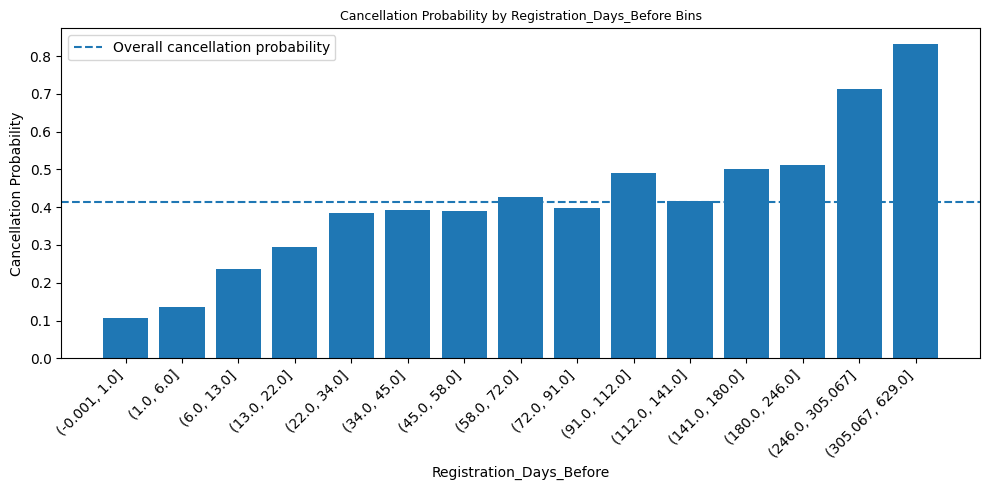

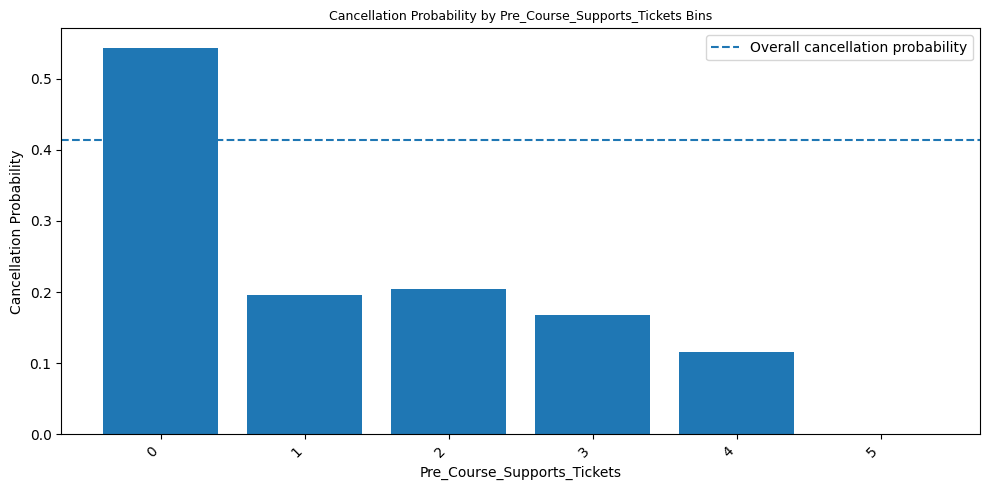

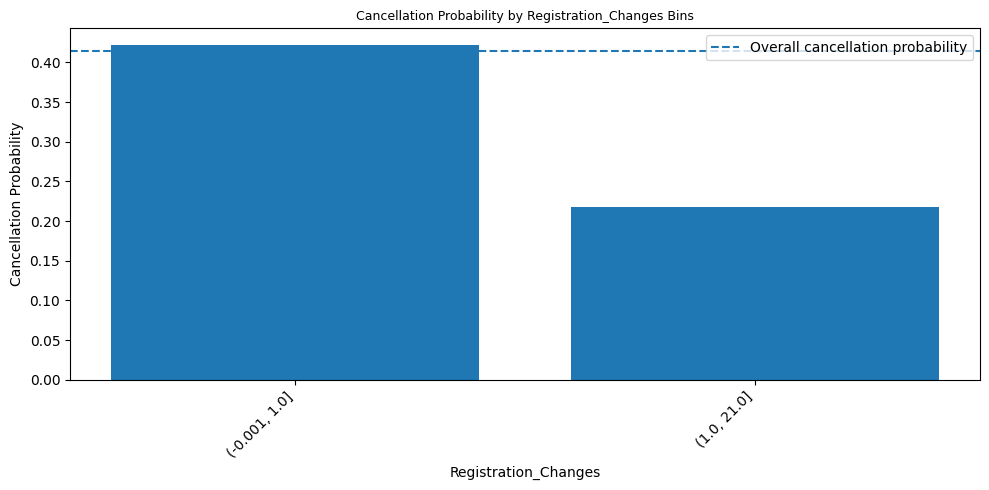

In [197]:
for col in top_numeric_target_cols:
    plot_numeric_feature_target_bins(col)

In [198]:
# Compact summary for top numeric features

numeric_feature_signal_summary = []

for col in top_numeric_target_cols:

    summary = numeric_feature_target_bins(col)

    reliable_summary = summary[
        summary["low_count_flag"] == False
    ].copy()

    if reliable_summary.empty:
        continue

    highest_row = reliable_summary.loc[
        reliable_summary["cancellation_probability"].idxmax()
    ]

    lowest_row = reliable_summary.loc[
        reliable_summary["cancellation_probability"].idxmin()
    ]

    numeric_feature_signal_summary.append({
        "feature": col,
        "highest_risk_bin": highest_row["value_bin"],
        "highest_risk_count": highest_row["count"],
        "highest_risk_cancellation_probability": highest_row["cancellation_probability"],
        "highest_risk_difference_from_overall": highest_row["difference_from_overall_rate"],
        "lowest_risk_bin": lowest_row["value_bin"],
        "lowest_risk_count": lowest_row["count"],
        "lowest_risk_cancellation_probability": lowest_row["cancellation_probability"],
        "lowest_risk_difference_from_overall": lowest_row["difference_from_overall_rate"],
        "risk_range": (
            highest_row["cancellation_probability"]
            - lowest_row["cancellation_probability"]
        )
    })

numeric_feature_signal_summary = (
    pd.DataFrame(numeric_feature_signal_summary)
    .sort_values("risk_range", ascending=False)
)

numeric_feature_signal_summary

,feature,highest_risk_bin,highest_risk_count,highest_risk_cancellation_probability,highest_risk_difference_from_overall,lowest_risk_bin,lowest_risk_count,lowest_risk_cancellation_probability,lowest_risk_difference_from_overall,risk_range
0,Registration_Days_Before,"(305.067, 629.0]",3243,0.831637,0.417247,"(-0.001, 1.0]",3326,0.106133,-0.308257,0.725504
1,Pre_Course_Supports_Tickets,0,31873,0.543564,0.129173,4,104,0.115385,-0.299005,0.428179
2,Registration_Changes,"(-0.001, 1.0]",48932,0.421789,0.007399,"(1.0, 21.0]",1839,0.217510,-0.196881,0.204280


### Top Numeric Features vs Target Conclusions


The binned target analysis confirms that the numeric features with the strongest relative correlations also show meaningful differences in cancellation probability across value ranges.

`Registration_Days_Before` shows the strongest numeric signal. Courses registered very close to the start date have a much lower cancellation probability (`≈ 0.106` for the lowest bin), while registrations made far in advance show a much higher cancellation probability (`≈ 0.832` for the highest-risk bin). This supports the positive correlation observed earlier, but the relationship appears non-linear rather than smoothly increasing across all ranges. Therefore, this feature will be retained, and a `log1p` transformation will be considered later in the feature-engineering stage to reduce the effect of the wide numeric range.

`Pre_Course_Supports_Tickets` shows a clear negative relationship with cancellation. Observations with zero pre-course support tickets have a relatively high cancellation probability (`≈ 0.544`), while observations with support interactions show much lower cancellation probabilities. This suggests that the main signal may be whether any pre-course support interaction occurred, rather than the exact number of tickets. Therefore, this feature motivates a later binary indicator for the existence of pre-course support activity.

`Registration_Changes` also contains signal, but it is weaker than the previous two features. Most observations have zero or one registration change and show a cancellation probability close to the overall rate, while observations with more than one change show a lower cancellation probability (`≈ 0.218`). This suggests a threshold-like relationship. Therefore, this feature will be examined later using a `log1p` transformation, and a binary based representation will also be considered in the feature-engineering stage.

Overall, these features should be retained for modeling. The observed relationships are not purely linear and often appear threshold-based, which supports the use of tree-based models and motivates later feature-engineering steps such as `log1p` transformations and binary indicators. No target-based binning is applied at this EDA stage.

## Sparse and Low-Correlation Numeric Features vs Target

The numeric correlation analysis provides a useful first indication of linear relationships with the target. However, a low Pearson correlation does not necessarily imply that a feature has no predictive value.

This is particularly relevant for sparse or count-based operational variables, where most observations may have a value of zero and only a relatively small number of observations have positive values. In such cases, cancellation patterns may be unstable across exact numeric values because some values appear only rarely.

Therefore, after the general numeric correlation analysis, we further examine several sparse numeric features to better understand the nature and stability of their relationship with the target.

The following analyses focus on:

- `Waiting_List_Days`
- `Students_Count`
- `Observers_Count`
- `Physical_Course_Kits`

The objective is to determine whether the predictive signal is stable enough to preserve the original numeric values, whether extreme values should be capped to reduce instability, or whether a simpler binary representation is more appropriate.

This analysis helps ensure that later feature-engineering decisions reduce noise and instability while preserving meaningful predictive information.

### Waiting List Days - Binary Relationship With Target

`Waiting_List_Days` is a sparse numeric feature, with many observations equal to zero.

Before examining the exact number of waiting days, we first check whether the basic distinction between clients who waited and clients who did not wait is related to the target variable.

This helps determine whether the presence of waiting-list activity itself contains useful predictive information.

In [199]:
# ============================================================
# 20. Waiting List Days - Binary Relationship With Target
# ============================================================

waiting_check = X_train[["Waiting_List_Days"]].copy()
waiting_check["Dropped_Course"] = y_train

waiting_check["Had_Waiting_List"] = np.where(
    waiting_check["Waiting_List_Days"].isna(),
    np.nan,
    (waiting_check["Waiting_List_Days"] > 0).astype(int)
)

waiting_binary_relation = (
    waiting_check
    .groupby("Had_Waiting_List", dropna=False)["Dropped_Course"]
    .agg(["count", "mean"])
)

waiting_binary_relation

,count,mean
Had_Waiting_List,,
0.0,48066,0.399784
1.0,2705,0.673937


#### Waiting List Days - Binary Relationship conclusion

In a binary comparison between clients who waited and clients who did not wait, we observed a higher cancellation probability among clients who waited.

This suggests that the fact that a client waited may contain useful predictive information.

### Waiting List Days - Exact Days Relationship

After examining the binary waiting-list signal, we analyze whether the exact number of waiting days provides additional information.

This analysis focuses only on observations with positive waiting-list days, since the zero values were already captured in the binary comparison.

In [200]:
# ============================================================
# 21. Waiting List Days - Exact Days Relationship
# ============================================================

# Next, we examine whether the exact number of waiting days is related to the cancellation probability.

positive_waiting_check = waiting_check[
    waiting_check["Waiting_List_Days"] > 0
].copy()

waiting_by_day = (
    positive_waiting_check
    .groupby("Waiting_List_Days")["Dropped_Course"]
    .agg(count="count", cancellation_probability="mean")
    .reset_index()
    .sort_values("Waiting_List_Days")
)

waiting_by_day["cancellation_probability_%"] = (
    waiting_by_day["cancellation_probability"] * 100
)

waiting_by_day.head()

,Waiting_List_Days,count,cancellation_probability,cancellation_probability_%
0,1,5,0.400000,40.000000
1,2,2,0.000000,0.000000
2,3,43,1.000000,100.000000
3,4,15,0.333333,33.333333
4,5,2,0.500000,50.000000


#### Smoothed Cancellation Probability by Waiting List Days

Exact waiting-day values may have small sample sizes, making the raw cancellation probabilities noisy.

To better understand the overall pattern, we calculate a weighted rolling average of the cancellation probability across waiting-day values. The weighting is based on the number of observations for each waiting-day value.

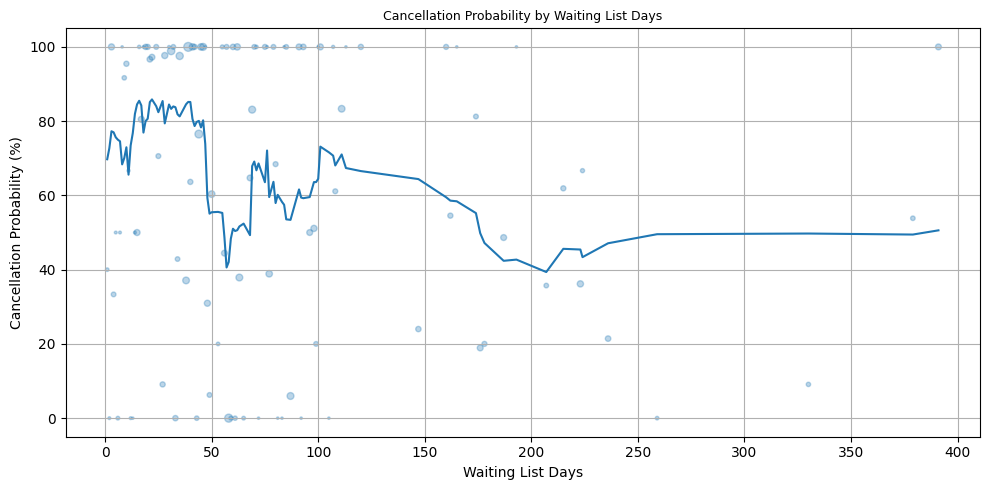

In [201]:
# ============================================================
# 22. Smoothed Cancellation Probability by Waiting List Days
# ============================================================

# Because exact waiting-day values may have very small sample sizes,
# we use a weighted rolling average to smooth the relationship.

window_size = 15

waiting_by_day["weighted_prob"] = (
    waiting_by_day["cancellation_probability_%"] *
    waiting_by_day["count"]
)

waiting_by_day["smoothed_probability_%"] = (
    waiting_by_day["weighted_prob"]
    .rolling(window=window_size, center=True, min_periods=1)
    .sum()
    /
    waiting_by_day["count"]
    .rolling(window=window_size, center=True, min_periods=1)
    .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    waiting_by_day["Waiting_List_Days"],
    waiting_by_day["smoothed_probability_%"]
)

plt.scatter(
    waiting_by_day["Waiting_List_Days"],
    waiting_by_day["cancellation_probability_%"],
    s=np.sqrt(waiting_by_day["count"]) * 3,
    alpha=0.3
)

plt.title("Cancellation Probability by Waiting List Days")
plt.xlabel("Waiting List Days")
plt.ylabel("Cancellation Probability (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Waiting List Days Analysis - conclusion

`Waiting_List_Days` is a highly sparse feature, with most observations equal to zero.

The binary comparison showed that clients with positive waiting-list days have a different cancellation probability than clients who did not wait. This suggests that waiting-list activity may contain useful predictive information.

However, this binary information is already represented within the numeric feature itself: a value of zero indicates no waiting-list activity, while positive values indicate that the client waited.

When examining the exact number of positive waiting days, the relationship with cancellation probability did not appear to be clearly monotonic. In addition, some high waiting-day values are relatively rare and may introduce instability.

Therefore, we will consider capping the values by the 95 precentile.

### Sparse Count Variables: Exact Count vs Binary Signal

Next, we examine three sparse count-based variables:

- `Students_Count`
- `Observers_Count`
- `Physical_Course_Kits`

For each feature, we compare two possible views of the relationship with the target:

1. Cancellation probability by exact count value.
2. Cancellation probability by a binary split of `0` versus `>0`.

This analysis helps determine whether the exact numeric count provides stable additional information, or whether the main signal is simply whether the count is zero or positive.

Since sparse count variables may contain rare values with very few observations, exact-count cancellation rates can be unstable. Therefore, we also flag exact values with low counts, so they are not over-interpreted.

In [202]:
# ============================================================
# Sparse Count Variables: Exact Count vs Binary Signal
# ============================================================

sparse_count_target_cols = [
    "Students_Count",
    "Observers_Count",
    "Physical_Course_Kits"
]

sparse_count_target_cols = [
    col for col in sparse_count_target_cols
    if col in X_train.columns
]

target_series = pd.Series(
    np.asarray(y_train),
    index=X_train.index,
    name="Dropped_Course"
)

# Diagnostic validity rules for this analysis only.
# These prevent clearly invalid values from distorting the exact-count summaries.
SPARSE_COUNT_ANALYSIS_VALIDITY_RULES = {
    "Students_Count": {"min_value": 0, "max_value": 100},
    "Observers_Count": {"min_value": 0},
    "Physical_Course_Kits": {"min_value": 0}
}


def prepare_sparse_count_analysis_data(feature):
    temp = pd.DataFrame({
        feature: pd.to_numeric(X_train[feature], errors="coerce"),
        "Dropped_Course": target_series
    })

    rules = SPARSE_COUNT_ANALYSIS_VALIDITY_RULES.get(feature, {})
    invalid_mask = pd.Series(False, index=temp.index)

    if "min_value" in rules:
        invalid_mask = invalid_mask | (temp[feature] < rules["min_value"]).fillna(False)

    if "max_value" in rules:
        invalid_mask = invalid_mask | (temp[feature] > rules["max_value"]).fillna(False)

    temp["invalid_value_flag"] = invalid_mask

    valid_temp = temp[
        temp[feature].notna()
        & (temp["invalid_value_flag"] == False)
    ].copy()

    return temp, valid_temp


def sparse_count_exact_value_summary(feature, min_count_reliable=30):
    _, valid_temp = prepare_sparse_count_analysis_data(feature)

    summary = (
        valid_temp
        .groupby(feature)
        .agg(
            count=("Dropped_Course", "count"),
            cancellation_probability=("Dropped_Course", "mean")
        )
        .reset_index()
        .sort_values(feature)
    )

    summary["difference_from_overall_rate"] = (
        summary["cancellation_probability"] - target_series.mean()
    )

    summary["positive_value_flag"] = summary[feature] > 0
    summary["low_count_flag"] = summary["count"] < min_count_reliable

    return summary


def sparse_count_binary_summary(feature):
    _, valid_temp = prepare_sparse_count_analysis_data(feature)

    valid_temp["binary_group"] = np.where(
        valid_temp[feature] > 0,
        "count > 0",
        "count = 0"
    )

    summary = (
        valid_temp
        .groupby("binary_group")
        .agg(
            count=("Dropped_Course", "count"),
            cancellation_probability=("Dropped_Course", "mean")
        )
        .reset_index()
    )

    summary["difference_from_overall_rate"] = (
        summary["cancellation_probability"] - target_series.mean()
    )

    return summary


def plot_sparse_count_exact_values(feature):
    summary = sparse_count_exact_value_summary(feature)

    plt.figure(figsize=(10, 5))

    plt.bar(
        summary[feature].astype(str),
        summary["cancellation_probability"]
    )

    plt.axhline(
        target_series.mean(),
        linestyle="--",
        label="Overall cancellation probability"
    )

    plt.title(f"Cancellation Probability by Exact {feature} Value")
    plt.xlabel(feature)
    plt.ylabel("Cancellation Probability")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return summary

In [203]:
# ============================================================
# Exact Count Value Summaries
# ============================================================

for col in sparse_count_target_cols:
    print(f"\n--- {col}: Exact Count Values ---")
    display(sparse_count_exact_value_summary(col))


--- Students_Count: Exact Count Values ---


,Students_Count,count,cancellation_probability,difference_from_overall_rate,positive_value_flag,low_count_flag
0,0.0,47694,0.418648,0.004258,False,False
1,1.0,1792,0.317522,-0.096868,True,False
2,2.0,1211,0.389761,-0.024630,True,False
3,3.0,27,0.333333,-0.081057,True,True



--- Observers_Count: Exact Count Values ---


,Observers_Count,count,cancellation_probability,difference_from_overall_rate,positive_value_flag,low_count_flag
0,0,50517,0.415702,0.001312,False,False
1,1,246,0.158537,-0.255854,True,False
2,2,6,0.000000,-0.414390,True,True
3,9,1,0.000000,-0.414390,True,True
4,10,1,0.000000,-0.414390,True,True



--- Physical_Course_Kits: Exact Count Values ---


,Physical_Course_Kits,count,cancellation_probability,difference_from_overall_rate,positive_value_flag,low_count_flag
0,0.0,48634,0.426204,0.011814,False,False
1,1.0,1316,0.000000,-0.414390,True,False
2,2.0,1,0.000000,-0.414390,True,True
3,3.0,1,0.000000,-0.414390,True,True


In [204]:
# ============================================================
# Binary Split Summaries: Zero vs Positive
# ============================================================

for col in sparse_count_target_cols:
    print(f"\n--- {col}: Binary Split ---")
    display(sparse_count_binary_summary(col))


--- Students_Count: Binary Split ---


,binary_group,count,cancellation_probability,difference_from_overall_rate
0,count = 0,47694,0.418648,0.004258
1,count > 0,3030,0.346535,-0.067855



--- Observers_Count: Binary Split ---


,binary_group,count,cancellation_probability,difference_from_overall_rate
0,count = 0,50517,0.415702,0.001312
1,count > 0,254,0.153543,-0.260847



--- Physical_Course_Kits: Binary Split ---


,binary_group,count,cancellation_probability,difference_from_overall_rate
0,count = 0,48634,0.426204,0.011814
1,count > 0,1318,0.000000,-0.414390


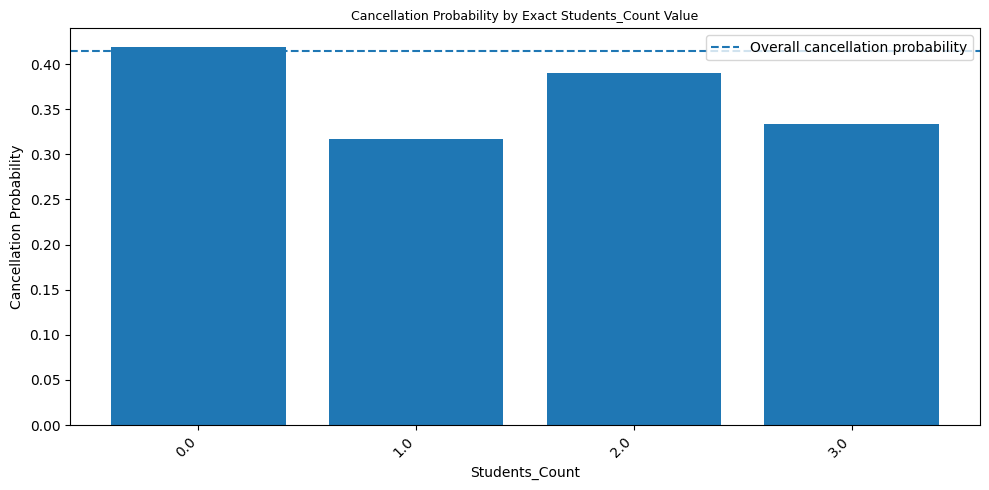

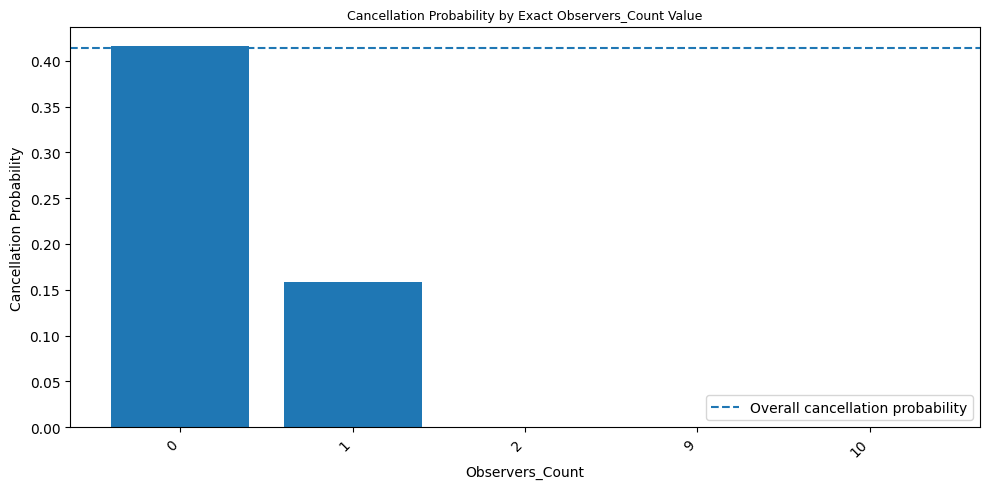

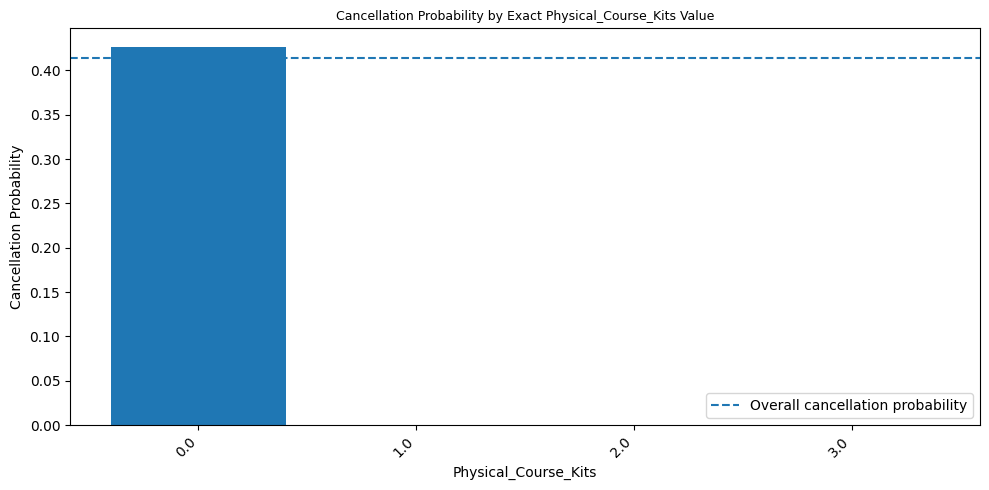

In [205]:
# ============================================================
# Exact Count Value Plots
# ============================================================

for col in sparse_count_target_cols:
    plot_sparse_count_exact_values(col)

In [206]:
# ============================================================
# Sparse Count Signal Stability Summary
# ============================================================

sparse_count_signal_summary = []

for col in sparse_count_target_cols:

    exact_summary = sparse_count_exact_value_summary(col)
    binary_summary = sparse_count_binary_summary(col)

    reliable_positive_exact_summary = exact_summary[
        (exact_summary["positive_value_flag"] == True)
        & (exact_summary["low_count_flag"] == False)
    ]

    if len(reliable_positive_exact_summary) > 1:
        positive_exact_risk_range = (
            reliable_positive_exact_summary["cancellation_probability"].max()
            - reliable_positive_exact_summary["cancellation_probability"].min()
        )
    else:
        positive_exact_risk_range = np.nan

    binary_risk_range = (
        binary_summary["cancellation_probability"].max()
        - binary_summary["cancellation_probability"].min()
    )

    sparse_count_signal_summary.append({
        "feature": col,
        "n_valid_exact_values": exact_summary[col].nunique(),
        "n_reliable_positive_exact_values": len(reliable_positive_exact_summary),
        "zero_vs_positive_risk_range": binary_risk_range,
        "positive_exact_value_risk_range": positive_exact_risk_range
    })

sparse_count_signal_summary_df = pd.DataFrame(sparse_count_signal_summary)

sparse_count_signal_summary_df[
    [
        "zero_vs_positive_risk_range",
        "positive_exact_value_risk_range"
    ]
] = sparse_count_signal_summary_df[
    [
        "zero_vs_positive_risk_range",
        "positive_exact_value_risk_range"
    ]
].round(4)

sparse_count_signal_summary_df

,feature,n_valid_exact_values,n_reliable_positive_exact_values,zero_vs_positive_risk_range,positive_exact_value_risk_range
0,Students_Count,4,2,0.0721,0.0722
1,Observers_Count,5,1,0.2622,NaN
2,Physical_Course_Kits,4,1,0.4262,NaN


### Sparse Count Variables: Conclusion

The sparse count analysis shows that the three examined variables do contain target-related signal, even though their simple linear correlations with the target are relatively low.

For `Students_Count`, the cancellation probability is higher when the count is `0` and lower when the count is positive. The exact positive values show some variation, but the pattern is not clearly monotonic, and the value `3` appears in only a small number of observations. Therefore, the most stable signal is the distinction between `0` and `>0`.

For `Observers_Count`, almost all observations have a value of `0`, while positive values are rare. The cancellation probability is substantially lower when the count is positive, but most positive exact values have very low counts. This makes the exact count values unstable and difficult to rely on directly.

For `Physical_Course_Kits`, the difference between `0` and positive values is especially strong. Observations with positive kit counts have a much lower cancellation probability. However, positive values above `1` are extremely rare, so the exact count values do not provide stable additional information beyond the binary distinction.

Overall, the analysis suggests that these variables are informative, but their exact count values are sparse and partly unstable. The most robust signal is whether the count is zero or positive.

Therefore, in the feature-engineering stage, these variables will be converted into binary indicators:

- `Students_Count` → `Has_Students`
- `Observers_Count` → `Has_Observers`
- `Physical_Course_Kits` → `Has_Physical_Kits`

This preserves the main predictive signal while reducing sparsity, noise, and sensitivity to rare exact count values.

## Categorical Value Consistency Check

Before encoding categorical variables, we check whether textual inconsistencies exist in categorical values, such as extra spaces, different letter casing, repeated spaces, or special characters.

The cleaning is applied only to a temporary copy of the training split for exploratory analysis.  
The actual cleaning logic will later be implemented inside the preprocessing pipeline.

In [207]:
# ============================================================
# 9. Cleaning Categorical Values - EDA Check
# ============================================================

# Identify categorical columns based on the original training data.
categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns.tolist()


def clean_categorical_values(df, categorical_cols):
    """
    Clean textual categorical values by:
    - converting values to string dtype
    - removing leading and trailing spaces
    - converting text to lowercase
    - removing selected special characters
    - replacing multiple spaces with a single space
    - converting empty strings to missing values
    """

    df = df.copy()

    for col in categorical_cols:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .str.replace("?", "", regex=False)
            .str.replace("*", "", regex=False)
            .str.replace("#", "", regex=False)
            .str.replace(")", "", regex=False)
            .str.replace("(", "", regex=False)
            .str.replace("!", "", regex=False)
            .str.replace(r"\s+", " ", regex=True)
        )

        df[col] = df[col].replace("", pd.NA)

    return df

In [208]:
# Apply cleaning only on a temporary copy for EDA comparison.
# We do not overwrite X_train at this stage.
X_train_before_cleaning = X_train.copy()

X_train_cleaned_for_eda = clean_categorical_values(
    X_train,
    categorical_cols
)

In [209]:
# Compare number of unique values before and after cleaning.
# A decrease in unique values indicates that cleaning reduced inconsistencies.
comparison = pd.DataFrame({
    "unique_before": X_train_before_cleaning[categorical_cols].nunique(dropna=False),
    "unique_after": X_train_cleaned_for_eda[categorical_cols].nunique(dropna=False)
})

comparison["difference"] = (
    comparison["unique_before"] - comparison["unique_after"]
)

comparison = comparison.sort_values(
    "difference",
    ascending=False
)

comparison

,unique_before,unique_after,difference
Origin_Country,667,149,518
Client_Category,455,8,447
Catering_Package,300,5,295
Submission_Source,290,6,284
Enrollment_Type,264,5,259
Lanyard_Color,225,5,220
Payment_Terms,215,5,210
Course_Start_Date,666,666,0
Welcome_Gift_Type,4,4,0
Requested_Lab_Config,9,9,0


### Categorical Value Consistency Conclusions

The comparison between the number of unique values before and after text cleaning shows that several categorical features contain substantial formatting inconsistencies.

Large reductions were observed in features such as `Origin_Country`, `Client_Category`, `Catering_Package`, `Submission_Source`, `Enrollment_Type`, `Lanyard_Color`, and `Payment_Terms`. This suggests that many categories appeared in multiple textual formats, likely due to differences in capitalization, extra spaces, repeated spaces, or special characters.

These inconsistencies should not be treated as meaningful separate categories. Therefore, categorical text cleaning will be included later inside the preprocessing pipeline before categorical encoding.

Some object-type columns, such as `Course_Start_Date`, did not change after text cleaning. This feature will later be handled separately as a date feature rather than as a regular categorical variable.

`Agent_ID` is not included in this comparison because it is numeric-looking in the original dataset. However, it represents an identifier-like categorical feature rather than a continuous numeric variable, and will therefore be converted and handled as a categorical feature later in the preprocessing pipeline.

The original `X_train` was not modified at this stage. The cleaning was applied only to a temporary copy for exploratory analysis.

## Categorical value inspection

In this section, we inspect categorical and categorical-like features in the training split.

The goal is to understand which category values appear in each feature, identify high-cardinality features, and detect rare or inconsistent category labels.

This section is exploratory only. No grouping, imputation, or feature transformation is applied at this stage.

The analysis is performed on `X_train_categorical_eda`, the cleaned EDA copy created earlier. The original `X_train` is not modified.

Although `Agent_ID` is numeric-looking, it is included in this inspection because it represents a categorical identifier rather than a continuous numeric feature.

In [210]:
# ============================================================
# 14. Categorical value inspection - EDA
# ============================================================

# Use the cleaned categorical EDA copy created earlier
X_train_categorical_eda = X_train_cleaned_for_eda.copy()

# Identify regular categorical columns
categorical_cols = X_train_categorical_eda.select_dtypes(
    include=["object", "string"]
).columns.tolist()

# Course_Start_Date will be handled later as a date feature,
# so it is excluded from regular categorical value inspection.
categorical_cols_for_analysis = [
    col for col in categorical_cols
    if col != "Course_Start_Date"
]

# Agent_ID is numeric-looking, but represents a categorical identifier.
# Therefore, it is manually included in the categorical inspection.
categorical_like_identifier_cols = ["Agent_ID"]

for col in categorical_like_identifier_cols:
    if col in X_train_categorical_eda.columns and col not in categorical_cols_for_analysis:
        categorical_cols_for_analysis.append(col)

categorical_cols_for_analysis

['Origin_Country',
 'Catering_Package',
 'Welcome_Gift_Type',
 'Requested_Lab_Config',
 'Assigned_Lab_Config',
 'Enrollment_Type',
 'Lanyard_Color',
 'Client_Category',
 'Submission_Source',
 'Payment_Terms',
 'Agent_ID']

In [211]:
categorical_value_summary = []

for col in categorical_cols_for_analysis:

    value_counts = X_train_categorical_eda[col].value_counts(dropna=False)

    top_value = value_counts.index[0]
    top_count = value_counts.iloc[0]

    categorical_value_summary.append({
        "feature": col,
        "n_unique_including_missing": X_train_categorical_eda[col].nunique(dropna=False),
        "top_value": top_value,
        "top_value_count": top_count,
        "top_value_percentage": top_count / len(X_train_categorical_eda) * 100
    })

categorical_value_summary = (
    pd.DataFrame(categorical_value_summary)
    .sort_values("n_unique_including_missing", ascending=False)
)

categorical_value_summary

,feature,n_unique_including_missing,top_value,top_value_count,top_value_percentage
10,Agent_ID,197,184.0,17644,34.752122
0,Origin_Country,149,prt,21098,41.555219
3,Requested_Lab_Config,9,standard pc windows,39793,78.377420
4,Assigned_Lab_Config,9,standard pc windows,36779,72.440960
7,Client_Category,8,saas & software houses,23378,46.045971
8,Submission_Source,6,b2b platforms & resellers,43432,85.544898
1,Catering_Package,5,standard coffee only,40305,79.385870
5,Enrollment_Type,5,general admission,36093,71.089795
6,Lanyard_Color,5,blue,28039,55.226409
9,Payment_Terms,5,pay upon start,41404,81.550491


In [212]:
# Display number of unique values and top categories for each categorical column.
# This helps inspect category distributions, rare categories, and inconsistent labels.

for col in categorical_cols_for_analysis:

    print(f"\n--- {col} ---")
    print(
        "Number of unique values:",
        X_train_categorical_eda[col].nunique(dropna=False)
    )

    display(
        X_train_categorical_eda[col]
        .value_counts(dropna=False)
        .head(20)
        .to_frame(name="count")
    )


--- Origin_Country ---
Number of unique values: 149


,count
Origin_Country,
prt,21098
fra,5581
deu,3496
esp,3129
gbr,2803
ita,2184
bra,1118
bel,1087
nld,1009



--- Catering_Package ---
Number of unique values: 5


,count
Catering_Package,
standard coffee only,40305
no food plan,5868
lunch included,4225
<NA>,337
all inclusive,36



--- Welcome_Gift_Type ---
Number of unique values: 4


,count
Welcome_Gift_Type,
branded notebook,25789
water bottle,14797
usb drive,8084
portable charger,2101



--- Requested_Lab_Config ---
Number of unique values: 9


,count
Requested_Lab_Config,
standard pc windows,39793
linux workstation,6698
<NA>,1394
dual monitor setup,1050
macos station,792
laptop docking station,775
high-gpu unit,253
touch screen interface,11
vr/ar station,5



--- Assigned_Lab_Config ---
Number of unique values: 9


,count
Assigned_Lab_Config,
standard pc windows,36779
linux workstation,9327
laptop docking station,1471
macos station,1268
dual monitor setup,1242
high-gpu unit,400
server access terminal,191
touch screen interface,87
vr/ar station,6



--- Enrollment_Type ---
Number of unique values: 5


,count
Enrollment_Type,
general admission,36093
affiliated admission,12098
contractual agreement,1831
<NA>,563
organizational arrangement,186



--- Lanyard_Color ---
Number of unique values: 5


,count
Lanyard_Color,
blue,28039
black,11836
red,5803
orange,2918
green,2175



--- Client_Category ---
Number of unique values: 8


,count
Client_Category,
saas & software houses,23378
traditional it & telecomm,11566
big tech & multinationals,9527
fintech & banking,3741
industrial tech & iot,2065
non-profit & edutech,366
defense & govtech,126
unknown,2



--- Submission_Source ---
Number of unique values: 6


,count
Submission_Source,
b2b platforms & resellers,43432
direct website registration,4136
dedicated sales team,2280
<NA>,623
unknown,180
government procurement system,120



--- Payment_Terms ---
Number of unique values: 5


,count
Payment_Terms,
pay upon start,41404
prepaid non-refundable,8560
<NA>,628
unknown,174
refundable deposit,5



--- Agent_ID ---
Number of unique values: 197


,count
Agent_ID,
184.0,17644
NaN,8928
218.0,5263
104.0,2087
264.0,1895
219.0,1584
224.0,1040
205.0,874
320.0,814


### Categorical Value Inspection Conclusions

The categorical value inspection shows that the dataset contains both low-cardinality categorical features and high-cardinality categorical-like features.

Several features, such as `Requested_Lab_Config`, `Assgined_Lab_Config` , `Catering_Package`, `Enrollment_Type`, `Lanyard_Color`, `Client_Category`, `Submission_Source` , `Welcome_Gift_Type`, and `Payment_Terms`,  contain a limited number of category values. These features can generally be represented as categorical variables in the modeling pipeline.

`Origin_Country` contains many distinct values and appears to have a long-tail distribution, where many countries occur only a small number of times. This suggests that the feature may require special attention later in the feature-engineering stage.

`Agent_ID` is included in this inspection even though it is numeric-looking, because it represents a categorical identifier rather than a continuous numeric measurement. Similar to other high-cardinality categorical features, it may require special handling later.

`Course_Start_Date` is excluded from this categorical inspection because it represents a date and will be analyzed separately later on

### Explicit Unknown Labels and Missing Representation

During the categorical value inspection, some features were found to contain explicit labels that represent unavailable information, such as `"unknown"`.

In some cases, the same feature may contain both standard missing values and explicit unknown-like labels. This means that unavailable information may be represented in two different ways in the dataset.

This subsection does not perform missing-value treatment and does not examine the relationship with the target variable yet. Its purpose is only to document this duplicated representation so that missing values and explicit unknown labels can later be considered together in the missingness-vs-target analysis and treatment plan.

In [213]:
unknown_like_values_for_eda = {
    "unknown",
    "unknown_agent",
    "unknown agent",
    "unknown_country",
    "unknown country",
    "na",
    "n/a",
    "none",
    "nan",
    ""
}

categorical_missing_unknown_summary = []

for col in categorical_cols_for_analysis:

    col_as_text = (
        X_train_categorical_eda[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    missing_mask = X_train_categorical_eda[col].isna()
    explicit_unknown_mask = col_as_text.isin(unknown_like_values_for_eda)
    unavailable_mask = missing_mask | explicit_unknown_mask

    categorical_missing_unknown_summary.append({
        "feature": col,
        "missing_count": missing_mask.sum(),
        "missing_percentage": missing_mask.mean() * 100,
        "explicit_unknown_label_count": explicit_unknown_mask.sum(),
        "explicit_unknown_label_percentage": explicit_unknown_mask.mean() * 100,
        "missing_or_unknown_label_count": unavailable_mask.sum(),
        "missing_or_unknown_label_percentage": unavailable_mask.mean() * 100,
        "n_unique_including_missing": X_train_categorical_eda[col].nunique(dropna=False)
    })

categorical_missing_unknown_summary = (
    pd.DataFrame(categorical_missing_unknown_summary)
    .sort_values(
        "missing_or_unknown_label_percentage",
        ascending=False
    )
)

categorical_missing_unknown_summary

,feature,missing_count,missing_percentage,explicit_unknown_label_count,explicit_unknown_label_percentage,missing_or_unknown_label_count,missing_or_unknown_label_percentage,n_unique_including_missing
10,Agent_ID,8928,17.584842,0,0.000000,8928,17.584842,197
3,Requested_Lab_Config,1394,2.745662,0,0.000000,1394,2.745662,9
8,Submission_Source,623,1.227078,180,0.354533,803,1.581612,6
9,Payment_Terms,628,1.236927,174,0.342715,802,1.579642,5
5,Enrollment_Type,563,1.108901,0,0.000000,563,1.108901,5
0,Origin_Country,438,0.862697,0,0.000000,438,0.862697,149
1,Catering_Package,337,0.663765,0,0.000000,337,0.663765,5
7,Client_Category,0,0.000000,2,0.003939,2,0.003939,8
2,Welcome_Gift_Type,0,0.000000,0,0.000000,0,0.000000,4
4,Assigned_Lab_Config,0,0.000000,0,0.000000,0,0.000000,9


### Explicit Unknown Labels and Missing Representation Conclusions

The inspection shows that some categorical features use explicit unknown-like labels, while others contain standard missing values.

For features such as `Submission_Source` and `Payment_Terms`, unavailable information appears to be represented both as missing values and as explicit unknown-like labels. This suggests that these two representations may need to be considered together later.

`Agent_ID` is also included in this check because it represents a categorical identifier. If missing agent values and explicit unknown-agent labels appear in the data, they should be interpreted as the same business situation: the responsible agent is unavailable or not identified.

## Categorical Features vs Target

In this section, we examine the relationship between selected categorical features and the target variable, `Dropped_Course`.

For each categorical feature, we calculate the number of observations in each category and the cancellation probability within that category.

The analysis is performed on `X_train_categorical_eda`, the cleaned EDA copy created earlier. Missing values are displayed as a temporary `"__missing__"` label for analysis purposes only. The original `X_train` is not modified.

For high-cardinality categorical features, such as `Origin_Country` and `Agent_ID`, only the most frequent categories are inspected to avoid drawing conclusions from very rare categories.

In [214]:
# ============================================================
# Categorical Features vs Target - EDA
# ============================================================

# Selected categorical features for target relationship analysis.
# These are low- to medium-cardinality categorical features that can be
# meaningfully summarized by category.

categorical_target_cols = [
    "Client_Category",
    "Submission_Source",
    "Payment_Terms",
    "Enrollment_Type",
    "Catering_Package",
    "Requested_Lab_Config",
    "Assigned_Lab_Config"
]

categorical_target_cols = [
    col for col in categorical_target_cols
    if col in X_train_categorical_eda.columns
]

categorical_target_cols

['Client_Category',
 'Submission_Source',
 'Payment_Terms',
 'Enrollment_Type',
 'Catering_Package',
 'Requested_Lab_Config',
 'Assigned_Lab_Config']

In [215]:
overall_cancellation_probability = y_train.mean()
overall_cancellation_probability

np.float64(0.4143901045872644)

In [216]:
def categorical_target_summary(feature, min_count_reliable=30):
    """
    Summarize cancellation probability by category for a categorical feature.

    This function is used for EDA only.
    Missing values are displayed as '__missing__' for analysis purposes,
    without modifying the original training data.
    """

    temp = pd.DataFrame({
        "category": (
            X_train_categorical_eda[feature]
            .astype("string")
            .str.strip()
            .fillna("__missing__")
        ),
        "Dropped_Course": y_train
    })

    summary = (
        temp
        .groupby("category")["Dropped_Course"]
        .agg(
            count="count",
            cancellation_probability="mean"
        )
        .reset_index()
    )

    summary["percentage_of_training_data"] = (
        summary["count"] / len(temp) * 100
    )

    summary["difference_from_overall_rate"] = (
        summary["cancellation_probability"] - overall_cancellation_probability
    )

    summary["low_count_flag"] = summary["count"] < min_count_reliable

    summary = summary.sort_values(
        ["count", "cancellation_probability"],
        ascending=[False, False]
    )

    return summary

In [217]:
for col in categorical_target_cols:

    print(f"\n--- {col} ---")

    display(
        categorical_target_summary(col)
    )


--- Client_Category ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
5,saas & software houses,23378,0.359056,46.045971,-0.055335,False
6,traditional it & telecomm,11566,0.429448,22.780721,0.015058,False
0,big tech & multinationals,9527,0.683216,18.764649,0.268826,False
2,fintech & banking,3741,0.171879,7.368380,-0.242511,False
3,industrial tech & iot,2065,0.221792,4.067283,-0.192598,False
4,non-profit & edutech,366,0.114754,0.720884,-0.299636,False
1,defense & govtech,126,0.190476,0.248173,-0.223914,False
7,unknown,2,1.000000,0.003939,0.585610,True



--- Submission_Source ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
1,b2b platforms & resellers,43432,0.445962,85.544898,0.031571,False
3,direct website registration,4136,0.176741,8.146383,-0.237649,False
2,dedicated sales team,2280,0.246491,4.490753,-0.167899,False
0,__missing__,623,0.454254,1.227078,0.039864,False
5,unknown,180,0.394444,0.354533,-0.019946,False
4,government procurement system,120,0.191667,0.236355,-0.222723,False



--- Payment_Terms ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
1,pay upon start,41404,0.294295,81.550491,-0.120095,False
2,prepaid non-refundable,8560,0.997547,16.860019,0.583157,False
0,__missing__,628,0.374204,1.236927,-0.040186,False
4,unknown,174,0.442529,0.342715,0.028139,False
3,refundable deposit,5,0.600000,0.009848,0.185610,True



--- Enrollment_Type ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
3,general admission,36093,0.450697,71.089795,0.036307,False
1,affiliated admission,12098,0.299471,23.828564,-0.114919,False
2,contractual agreement,1831,0.486619,3.606389,0.072229,False
0,__missing__,563,0.422735,1.108901,0.008345,False
4,organizational arrangement,186,0.107527,0.366351,-0.306863,False



--- Catering_Package ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
4,standard coffee only,40305,0.422925,79.385870,0.008535,False
3,no food plan,5868,0.358725,11.557779,-0.055665,False
2,lunch included,4225,0.409231,8.321680,-0.005159,False
0,__missing__,337,0.385757,0.663765,-0.028633,False
1,all inclusive,36,0.805556,0.070907,0.391165,False



--- Requested_Lab_Config ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
6,standard pc windows,39793,0.433066,78.377420,0.018676,False
4,linux workstation,6698,0.339952,13.192571,-0.074438,False
0,__missing__,1394,0.403156,2.745662,-0.011234,False
1,dual monitor setup,1050,0.388571,2.068110,-0.025819,False
5,macos station,792,0.297980,1.559946,-0.116410,False
3,laptop docking station,775,0.334194,1.526462,-0.080197,False
2,high-gpu unit,253,0.217391,0.498316,-0.196999,False
7,touch screen interface,11,0.363636,0.021666,-0.050754,True
8,vr/ar station,5,1.000000,0.009848,0.585610,True



--- Assigned_Lab_Config ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
6,standard pc windows,36779,0.474809,72.440960,0.060419,False
3,linux workstation,9327,0.262678,18.370723,-0.151712,False
2,laptop docking station,1471,0.233175,2.897323,-0.181215,False
4,macos station,1268,0.210568,2.497489,-0.203822,False
0,dual monitor setup,1242,0.346216,2.446278,-0.068174,False
1,high-gpu unit,400,0.152500,0.787851,-0.261890,False
5,server access terminal,191,0.047120,0.376199,-0.367270,False
7,touch screen interface,87,0.114943,0.171358,-0.299448,False
8,vr/ar station,6,1.000000,0.011818,0.585610,True


In [218]:
def plot_categorical_target_summary(feature, max_categories=15, min_count_for_plot=30):
    """
    Plot cancellation probability by category.

    For readability and reliability, the plot includes only categories
    with at least min_count_for_plot observations.
    If there are many categories, only the most frequent categories are shown.
    """

    summary = categorical_target_summary(feature)

    # Keep only categories with enough observations for a more stable estimate
    plot_data = summary[
        summary["count"] >= min_count_for_plot
    ].copy()

    # If many categories remain, keep the most frequent ones
    if len(plot_data) > max_categories:
        top_categories = (
            plot_data
            .sort_values("count", ascending=False)
            .head(max_categories)["category"]
        )

        plot_data = plot_data[
            plot_data["category"].isin(top_categories)
        ].copy()

    plot_data = plot_data.sort_values("cancellation_probability")

    if plot_data.empty:
        print(f"No categories with at least {min_count_for_plot} observations for {feature}.")
        return

    plt.figure(figsize=(10, max(4, 0.4 * len(plot_data))))

    plt.barh(
        plot_data["category"],
        plot_data["cancellation_probability"]
    )

    plt.axvline(
        overall_cancellation_probability,
        linestyle="--",
        label="Overall cancellation probability"
    )

    plt.title(f"Cancellation Probability by {feature}")
    plt.xlabel("Cancellation Probability")
    plt.ylabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()

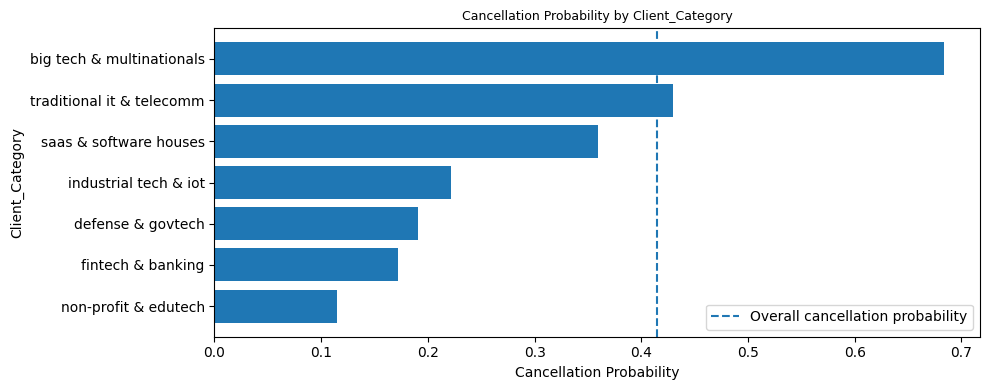

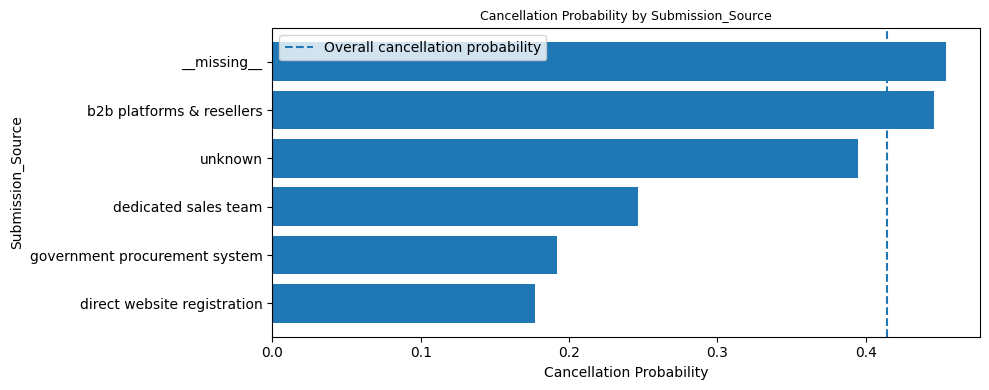

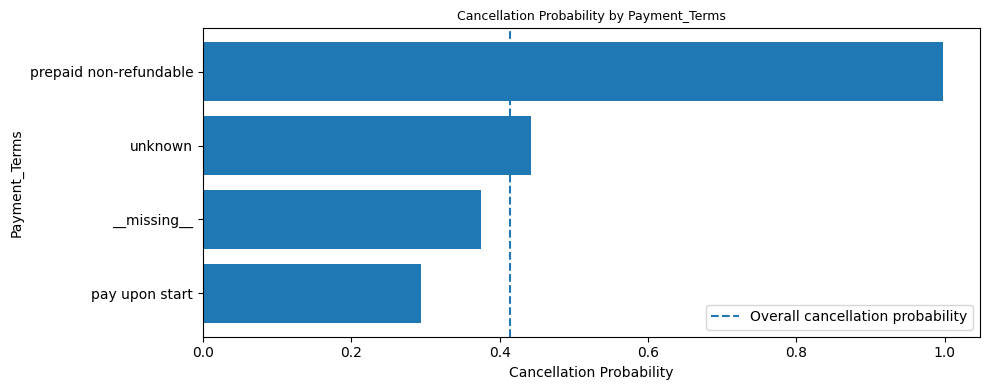

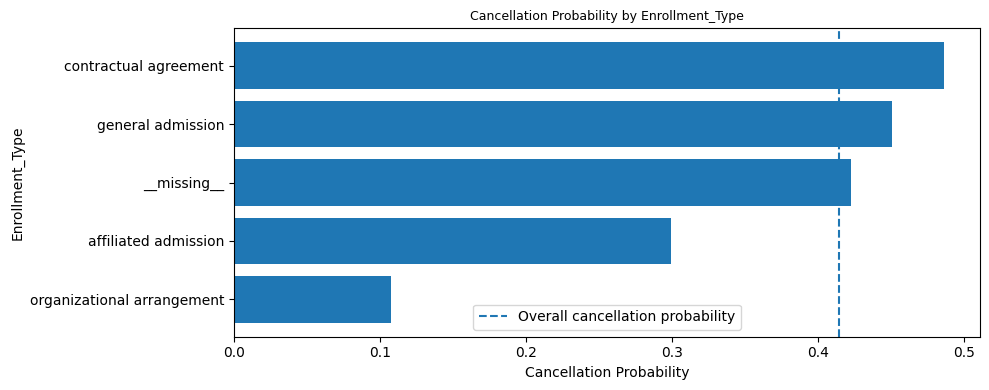

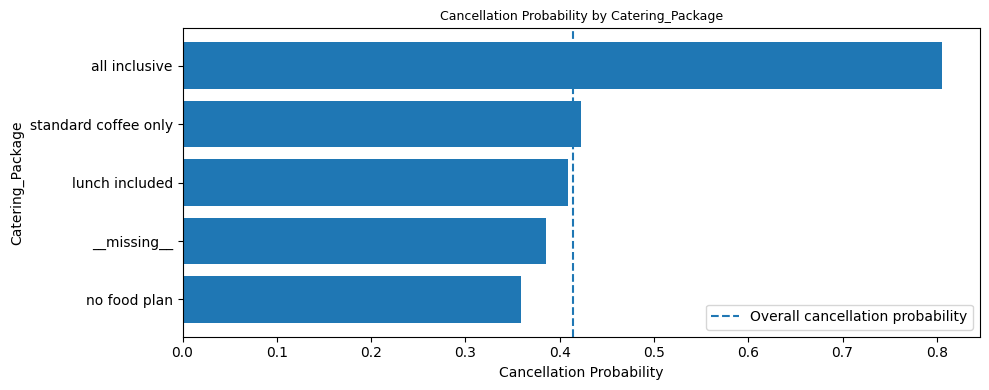

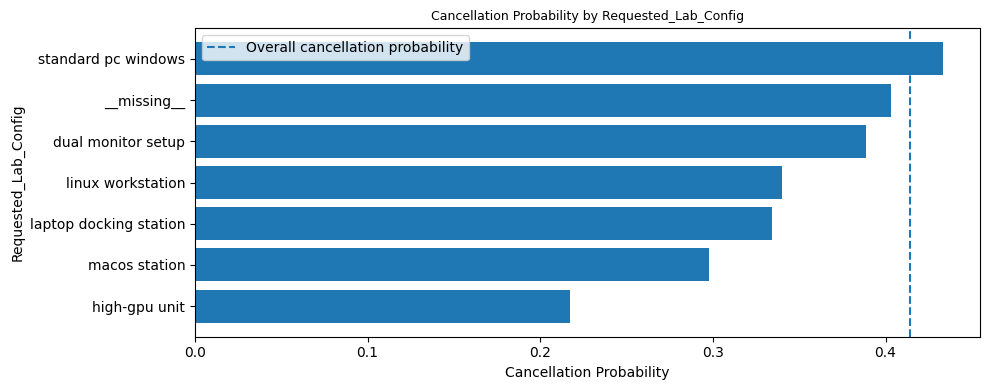

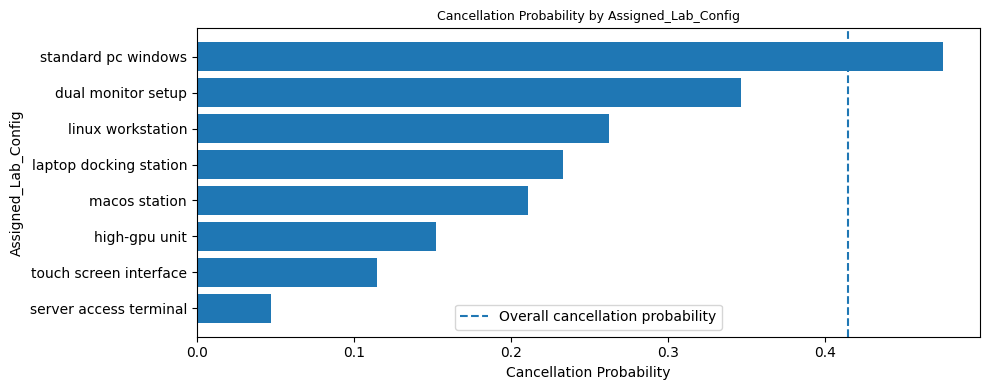

In [219]:
for col in categorical_target_cols:
    plot_categorical_target_summary(col)

In [220]:
# ============================================================
# Compact summary for selected categorical features
# ============================================================

# This table summarizes the strongest category-level target differences
# for the selected low- and medium-cardinality categorical features.
#
# Missing values are represented as "__missing__" only for EDA display.
# This allows us to inspect how missing categorical values behave before
# any missing-value treatment is applied.

TEMP_MISSING_CATEGORY_LABEL = "__missing__"
min_count_reliable = 30

categorical_feature_signal_summary = []

for col in categorical_target_cols:

    summary = categorical_target_summary(col)

    reliable_summary = summary[
        summary["count"] >= min_count_reliable
    ].copy()

    if reliable_summary.empty:
        continue

    highest_row = reliable_summary.loc[
        reliable_summary["cancellation_probability"].idxmax()
    ]

    lowest_row = reliable_summary.loc[
        reliable_summary["cancellation_probability"].idxmin()
    ]

    categorical_feature_signal_summary.append({
        "feature": col,
        "n_categories": summary["category"].nunique(),

        "highest_risk_category": highest_row["category"],
        "highest_risk_is_missing_label": highest_row["category"] == TEMP_MISSING_CATEGORY_LABEL,
        "highest_risk_count": highest_row["count"],
        "highest_risk_cancellation_probability": highest_row["cancellation_probability"],
        "highest_risk_difference_from_overall": highest_row["difference_from_overall_rate"],

        "lowest_risk_category": lowest_row["category"],
        "lowest_risk_is_missing_label": lowest_row["category"] == TEMP_MISSING_CATEGORY_LABEL,
        "lowest_risk_count": lowest_row["count"],
        "lowest_risk_cancellation_probability": lowest_row["cancellation_probability"],
        "lowest_risk_difference_from_overall": lowest_row["difference_from_overall_rate"],

        "risk_range": (
            highest_row["cancellation_probability"]
            - lowest_row["cancellation_probability"]
        )
    })

categorical_feature_signal_summary = (
    pd.DataFrame(categorical_feature_signal_summary)
    .sort_values("risk_range", ascending=False)
)

categorical_feature_signal_summary

,feature,n_categories,highest_risk_category,highest_risk_is_missing_label,highest_risk_count,highest_risk_cancellation_probability,highest_risk_difference_from_overall,lowest_risk_category,lowest_risk_is_missing_label,lowest_risk_count,lowest_risk_cancellation_probability,lowest_risk_difference_from_overall,risk_range
2,Payment_Terms,5,prepaid non-refundable,False,8560,0.997547,0.583157,pay upon start,False,41404,0.294295,-0.120095,0.703251
0,Client_Category,8,big tech & multinationals,False,9527,0.683216,0.268826,non-profit & edutech,False,366,0.114754,-0.299636,0.568462
4,Catering_Package,5,all inclusive,False,36,0.805556,0.391165,no food plan,False,5868,0.358725,-0.055665,0.446830
6,Assigned_Lab_Config,9,standard pc windows,False,36779,0.474809,0.060419,server access terminal,False,191,0.047120,-0.367270,0.427689
3,Enrollment_Type,5,contractual agreement,False,1831,0.486619,0.072229,organizational arrangement,False,186,0.107527,-0.306863,0.379092
1,Submission_Source,6,__missing__,True,623,0.454254,0.039864,direct website registration,False,4136,0.176741,-0.237649,0.277513
5,Requested_Lab_Config,9,standard pc windows,False,39793,0.433066,0.018676,high-gpu unit,False,253,0.217391,-0.196999,0.215675


### Selected Categorical Featured VS Target Conclusions

The compact categorical target summary shows meaningful differences in cancellation probability across several categorical features.

`Payment_Terms` shows the strongest categorical signal. The category `prepaid non-refundable` has an extremely high cancellation probability (`≈ 0.998`, count = 8,560), while `pay upon start` has a much lower cancellation probability (`≈ 0.294`, count = 41,404). This indicates that payment structure is strongly related to cancellation behavior.

`Client_Category` also shows a strong relationship with the target. `big tech & multinationals` has a high cancellation probability (`≈ 0.683`, count = 9,527), while `non-profit & edutech` has a much lower cancellation probability (`≈ 0.115`, count = 366). This suggests that client type is an important business factor in course cancellation.

`Enrollment_Type` differentiates cancellation risk as well. `contractual agreement` has a higher cancellation probability (`≈ 0.487`, count = 1,831), while `organizational arrangement` has a much lower cancellation probability (`≈ 0.108`, count = 186). This suggests that the structure of enrollment is related to cancellation behavior.

The lab configuration features also contain useful information. `Assigned_Lab_Config` shows a wider separation between categories than `Requested_Lab_Config`. In particular, `server access terminal` in the assigned lab configuration has a very low cancellation probability (`≈ 0.047`, count = 191), while `standard pc windows` is higher (`≈ 0.475`, count = 36,779). This suggests that the assigned technical setup may be more informative than the requested setup.

`Submission_Source` shows that `direct website registration` has a much lower cancellation probability (`≈ 0.177`, count = 4,136) than the overall cancellation rate. The temporary `"__missing__"` category has the highest cancellation probability for this feature (`≈ 0.454`, count = 623), but this missing-value pattern is analyzed more systematically in the Missing Values section.

`Catering_Package` shows a large difference for `all inclusive` (`≈ 0.806`), but this category has only 36 observations. Therefore, this result should be interpreted cautiously. The more frequent `no food plan` category has a lower cancellation probability (`≈ 0.359`, count = 5,868), suggesting that catering information may contain some signal, but it is less stable than the strongest categorical features.

Overall, the strongest selected categorical signals are found in `Payment_Terms`, `Client_Category`, `Enrollment_Type`, and `Assigned_Lab_Config`. These features show clear category-level differences and should be retained for modeling.

### High-Cardinality Categorical Features vs Target

`Origin_Country` and `Agent_ID` contain many distinct values.  
Therefore, they are analyzed only for the most frequent categories.

This avoids drawing conclusions from categories with very small sample sizes.

In [221]:
high_cardinality_categorical_cols = [
    "Origin_Country",
    "Agent_ID"
]

high_cardinality_categorical_cols = [
    col for col in high_cardinality_categorical_cols
    if col in X_train_categorical_eda.columns
]

for col in high_cardinality_categorical_cols:

    print(f"\n--- {col}: top categories ---")

    summary = categorical_target_summary(col)

    display(
        summary
        .sort_values("count", ascending=False)
        .head(20)
    )


--- Origin_Country: top categories ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
115,prt,21098,0.639824,41.555219,0.225434,False
47,fra,5581,0.174162,10.992496,-0.240228,False
36,deu,3496,0.167048,6.885821,-0.247342,False
43,esp,3129,0.272611,6.162967,-0.141779,False
49,gbr,2803,0.278630,5.520868,-0.135760,False
69,ita,2184,0.364011,4.301668,-0.050379,False
22,bra,1118,0.378354,2.202044,-0.036036,False
14,bel,1087,0.191352,2.140986,-0.223038,False
105,nld,1009,0.202180,1.987355,-0.212210,False
142,usa,854,0.216628,1.682063,-0.197762,False



--- Agent_ID: top categories ---


,category,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,low_count_flag
69,184.0,17644,0.400193,34.752122,-0.014197,False
196,__missing__,8928,0.338262,17.584842,-0.076128,False
101,218.0,5263,0.734562,10.366154,0.320172,False
4,104.0,2087,0.126018,4.110614,-0.288372,False
144,264.0,1895,0.175726,3.732446,-0.238665,False
102,219.0,1584,0.393308,3.119891,-0.021082,False
107,224.0,1040,0.053846,2.048413,-0.360544,False
88,205.0,874,0.566362,1.721455,0.151971,False
193,320.0,814,0.578624,1.603277,0.164234,False
48,158.0,705,0.323404,1.388588,-0.090986,False


In [222]:
# ============================================================
# Compact summary for high-cardinality categorical features
# ============================================================

# Origin_Country and Agent_ID contain many categories.
# To avoid drawing conclusions from very rare categories,
# this summary considers only categories with enough observations.

min_count_high_cardinality = 100

high_cardinality_signal_summary = []

for col in high_cardinality_categorical_cols:

    summary = categorical_target_summary(col)

    reliable_summary = summary[
        summary["count"] >= min_count_high_cardinality
    ].copy()

    if reliable_summary.empty:
        continue

    highest_row = reliable_summary.loc[
        reliable_summary["cancellation_probability"].idxmax()
    ]

    lowest_row = reliable_summary.loc[
        reliable_summary["cancellation_probability"].idxmin()
    ]

    high_cardinality_signal_summary.append({
        "feature": col,
        "total_n_categories": summary["category"].nunique(),
        "n_categories_with_at_least_100_observations": len(reliable_summary),
        "highest_risk_category": highest_row["category"],
        "highest_risk_count": highest_row["count"],
        "highest_risk_cancellation_probability": highest_row["cancellation_probability"],
        "highest_risk_difference_from_overall": highest_row["difference_from_overall_rate"],
        "lowest_risk_category": lowest_row["category"],
        "lowest_risk_count": lowest_row["count"],
        "lowest_risk_cancellation_probability": lowest_row["cancellation_probability"],
        "lowest_risk_difference_from_overall": lowest_row["difference_from_overall_rate"],
        "risk_range": (
            highest_row["cancellation_probability"]
            - lowest_row["cancellation_probability"]
        )
    })

high_cardinality_signal_summary = (
    pd.DataFrame(high_cardinality_signal_summary)
    .sort_values("risk_range", ascending=False)
)

high_cardinality_signal_summary

,feature,total_n_categories,n_categories_with_at_least_100_observations,highest_risk_category,highest_risk_count,highest_risk_cancellation_probability,highest_risk_difference_from_overall,lowest_risk_category,lowest_risk_count,lowest_risk_cancellation_probability,lowest_risk_difference_from_overall,risk_range
1,Agent_ID,197,40,314.0,175,1.000000,0.585610,224.0,1040,0.053846,-0.360544,0.946154
0,Origin_Country,149,32,prt,21098,0.639824,0.225434,jpn,110,0.145455,-0.268936,0.494369


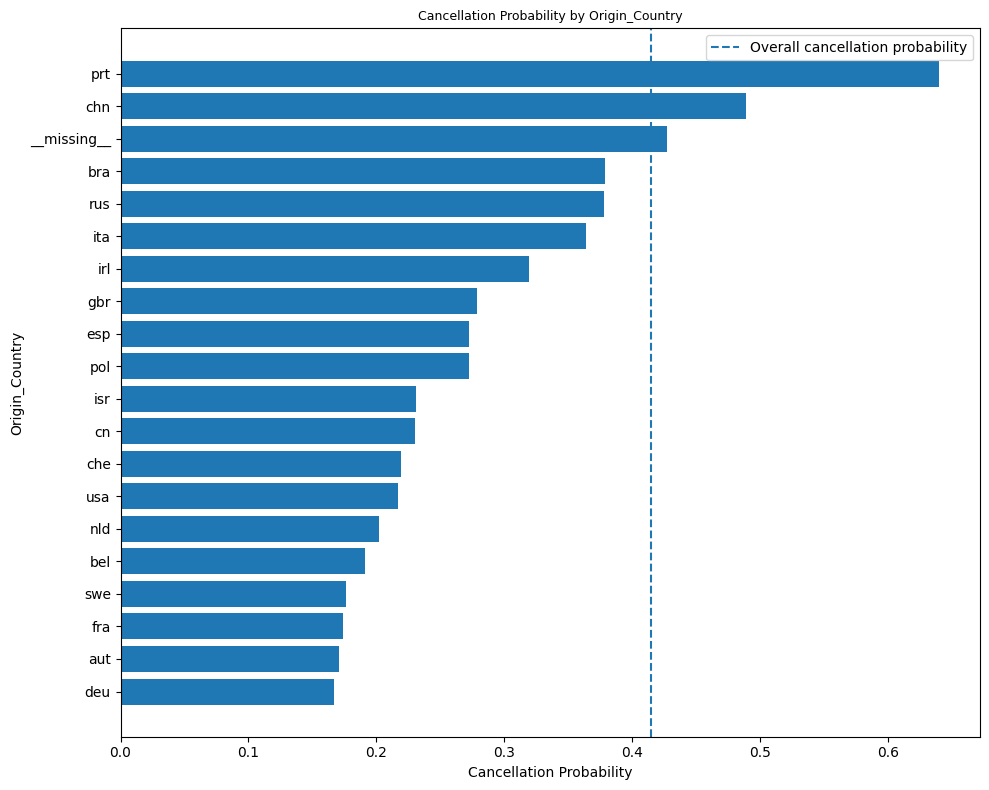

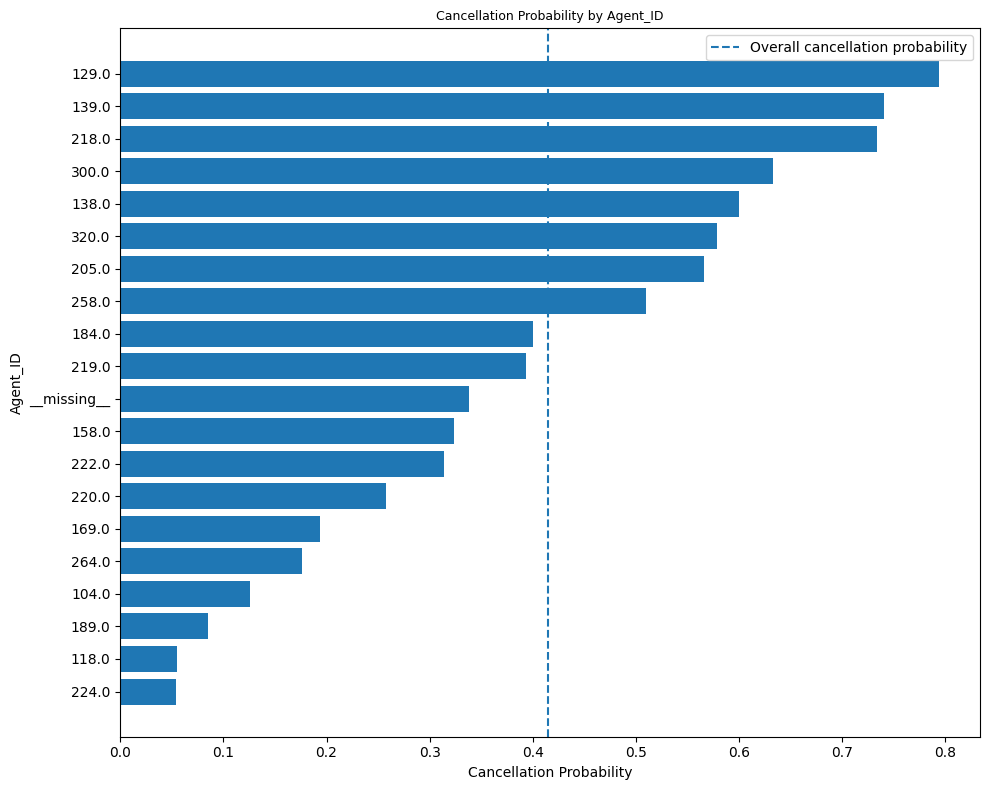

In [223]:
for col in high_cardinality_categorical_cols:
    plot_categorical_target_summary(
        feature=col,
        max_categories=20,
        min_count_for_plot=100
    )

### High-Cardinality Categorical Features vs Target Conclusions

The high-cardinality categorical analysis shows that both `Agent_ID` and `Origin_Country` contain meaningful category-level differences in cancellation probability.

`Agent_ID` contains 197 distinct values, with 40 agents having at least 100 observations. The differences between frequent agents are very large. For example, agent `314.0` has a cancellation probability of `1.000` across 175 observations, while agent `224.0` has a much lower cancellation probability (`≈ 0.054`, count = 1,040). This suggests that `Agent_ID` captures a strong operational pattern related to cancellations.

`Origin_Country` contains 149 cleaned country values, but only 32 countries have at least 100 observations. Among frequent countries, `prt` has a high cancellation probability (`≈ 0.640`, count = 21,098), while `jpn` has a much lower cancellation probability (`≈ 0.145`, count = 110). This suggests that country information is also related to cancellation behavior.

Overall, both high-cardinality features appear informative and should be retained for modeling. However, because they contain many distinct categories and a long tail of rare values, they should be handled differently from low-cardinality categorical features. Their structure motivates later feature-engineering steps such as grouping rare categories and treating `Agent_ID` as a categorical identifier rather than as a numeric variable.

## Binary Feature Analysis

In this section, we identify binary features in the training split.

Binary features are variables that contain only the values 0 and 1, excluding missing values.

This step helps us understand which features are already represented as indicators and supports later feature-engineering decisions.

In [224]:
# ============================================================
# 16. Binary Feature Analysis
# ============================================================

# Identify all binary features in the dataset.
# Binary features are features that contain only the values 0 and 1.

binary_cols = []

for col in X_train.columns:
    unique_values = set(X_train[col].dropna().unique())

    if unique_values.issubset({0, 1}) and len(unique_values) <= 2:
        binary_cols.append(col)

binary_cols

['Returning_Client']

In [225]:
binary_feature_summary = []

for col in binary_cols:

    value_counts = X_train[col].value_counts(dropna=False)

    binary_feature_summary.append({
        "feature": col,
        "n_unique_including_missing": X_train[col].nunique(dropna=False),
        "missing_values": X_train[col].isna().sum(),
        "value_0_count": value_counts.get(0, 0),
        "value_1_count": value_counts.get(1, 0),
        "value_1_percentage": value_counts.get(1, 0) / len(X_train) * 100
    })

binary_feature_summary = pd.DataFrame(binary_feature_summary)

binary_feature_summary

,feature,n_unique_including_missing,missing_values,value_0_count,value_1_count,value_1_percentage
0,Returning_Client,2,0,49413,1358,2.674755


The binary feature analysis shows which variables are already encoded as 0/1 indicators.

Most binary features can be used directly by the models after missing-value handling, if needed.  
However, `Returning_Client` requires additional investigation because it is expected to represent previous company interaction, which can also be inferred from historical course features.

### Consistency Check - Returning_Client

`Returning_Client` is expected to indicate whether the client has interacted with the company before.

To validate this feature, we compare it with the historical course variables:

- `Prev_Course_Attended`
- `Prev_Course_Dropouts`

If a client is marked as non-returning but has previous attendance or previous dropout history, this suggests an inconsistency in the historical information.

In [226]:
# ============================================================
# 17. Consistency Check - Returning_Client
# ============================================================

# Returning_Client is intended to indicate whether the client
# has interacted with the company before.
#
# We want to verify whether this information is consistent with
# the historical course information available in the dataset.

history_check = X_train[[
    "Returning_Client",
    "Prev_Course_Attended",
    "Prev_Course_Dropouts"
]].copy()

history_check["Had_Previous_Attendance"] = (
    history_check["Prev_Course_Attended"] > 0
).astype(int)

history_check["Had_Previous_Dropout"] = (
    history_check["Prev_Course_Dropouts"] > 0
).astype(int)

history_check["Had_Any_Previous_History"] = (
    (history_check["Had_Previous_Attendance"] == 1) |
    (history_check["Had_Previous_Dropout"] == 1)
).astype(int)

In [227]:
pd.crosstab(
    history_check["Returning_Client"],
    history_check["Had_Any_Previous_History"],
    margins=True
)

Had_Any_Previous_History,0,1,All
Returning_Client,,,
0,45551,3862,49413
1,218,1140,1358
All,45769,5002,50771


In [228]:
pd.crosstab(
    history_check["Returning_Client"],
    history_check["Had_Any_Previous_History"],
    normalize="index"
)

Had_Any_Previous_History,0,1
Returning_Client,,
0,0.921842,0.078158
1,0.160530,0.839470


In [229]:
inconsistent_history = history_check[
    (history_check["Returning_Client"] == 0) &
    (history_check["Had_Any_Previous_History"] == 1)
]

print("Number of inconsistent rows:", len(inconsistent_history))

print(
    "Percent of X_train:",
    len(inconsistent_history) / len(history_check) * 100
)

Number of inconsistent rows: 3862
Percent of X_train: 7.60670461483918


### Returning Client Consistency Analysis

Approximately 7% of observations contain inconsistent historical information, where the client is marked as a non-returning client while still having evidence of previous interactions with the company.

This suggests that `Returning_Client` alone does not fully capture the client's historical relationship with the company.

To address this issue, we decided to create a new feature called `Has_Any_Company_History`, which combines information from:

- Returning_Client
- Prev_Course_Attended
- Prev_Course_Dropouts

This feature is expected to provide a more reliable representation of previous company interactions.

## Previous Course History vs Target

Next, we examine whether previous course history is related to the target variable, `Dropped_Course`.

Because the previous course variables are sparse count features, we compare observations with zero previous history to observations with at least one previous event.

In [230]:
# ============================================================
# 18. Previous Course History vs Target
# ============================================================

history_cols = [
    "Prev_Course_Attended",
    "Prev_Course_Dropouts"
]

history_df = X_train[history_cols].copy()
history_df["Dropped_Course"] = y_train

for col in history_cols:

    print(f"\n--- {col} ---")

    print(
        history_df
        .groupby(history_df[col] > 0)["Dropped_Course"]
        .agg(["count", "mean"])
    )


--- Prev_Course_Attended ---
                      count      mean
Prev_Course_Attended                 
False                 49757  0.421287
True                   1014  0.075937

--- Prev_Course_Dropouts ---
                      count      mean
Prev_Course_Dropouts                 
False                 46527  0.365637
True                   4244  0.948869


### Previous Course History Analysis

Both historical course variables show a relationship with the target variable.

However, the two features represent different types of previous interaction:

- `Prev_Course_Attended` represents previous successful attendance.
- `Prev_Course_Dropouts` represents previous cancellation or dropout behavior.

Since these signals are conceptually different, both will be preserved through separate binary indicators.

At the same time, both variables are sparse count features, meaning that most observations are equal to zero.  
To reduce sparsity while preserving the main business signal, they will later be converted into binary indicators:

- `Prev_Course_Attended` → `Had_Previous_Attendance`
- `Prev_Course_Dropouts` → `Had_Previous_Dropout`

The original count features will be removed after these indicators are created.

## Feature Transformation Analysis for Dimensionality Control


The goal of this stage is to preserve meaningful predictive signal while reducing unnecessary categorical representations, sparsity, redundancy, and the risk of high-dimensional feature spaces.

This is especially important for features that may expand into many one-hot encoded columns, contain overlapping information, or represent information in a format that is not directly suitable for modeling.

The following analyses focus on features where the original representation may not be optimal:

- `Requested_Lab_Config` and `Assigned_Lab_Config`
- `Course_Start_Date`
- `Origin_Country`
- `Agent_ID`

For each feature or feature group, we examine whether the raw representation should be preserved, transformed, grouped, or replaced by a more compact derived feature.

These decisions are motivated by both the observed relationship with the target and the need to reduce dimensionality and improve model robustness.

### Requested vs Assigned Lab Configuration vs Target

The previous categorical target analysis showed that both `Requested_Lab_Config` and `Assigned_Lab_Config` are related to cancellation probability, with `Assigned_Lab_Config` showing a stronger separation between categories.

In this section, we examine the relationship between the requested lab configuration and the assigned lab configuration.

The goal is to check whether a mismatch between the requested and assigned lab setup is associated with a different cancellation probability.

Missing values are represented using a temporary `"__missing__"` label for EDA purposes only. No missing-value treatment or feature engineering is applied at this stage.

#### Data Availability Note

`Assigned_Lab_Config` may appear to raise a potential data-availability concern, since it describes the lab configuration assigned to the group in practice.

However, according to the project files, the external test set contains the same feature columns as the training set, except for the target variable. Therefore, for the purpose of this project, we assume that `Assigned_Lab_Config` is available at prediction time and can be used as a valid explanatory feature.

If the business goal were to predict cancellations earlier, before the assigned lab configuration is known, this feature would need to be excluded or the prediction timing would need to be redefined. In the current project setting, it is retained for EDA and modeling.

In [231]:
# Lab-configuration interaction feature for EDA only

lab_config_source = (
    X_train_categorical_eda
    if "X_train_categorical_eda" in globals()
    else X_train
)

lab_config_analysis = lab_config_source[
    ["Requested_Lab_Config", "Assigned_Lab_Config"]
].copy()

for col in ["Requested_Lab_Config", "Assigned_Lab_Config"]:
    lab_config_analysis[col] = (
        lab_config_analysis[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )
    lab_config_analysis[col] = lab_config_analysis[col].replace("", np.nan)

missing_lab_config = (
    lab_config_analysis["Requested_Lab_Config"].isna()
    | lab_config_analysis["Assigned_Lab_Config"].isna()
)

configs_match = (
    lab_config_analysis["Requested_Lab_Config"]
    .eq(lab_config_analysis["Assigned_Lab_Config"])
    .fillna(False)
)

lab_config_analysis["Lab_Config_Match"] = "mismatch"

lab_config_analysis.loc[
    configs_match & ~missing_lab_config,
    "Lab_Config_Match"
] = "match"

lab_config_analysis.loc[
    missing_lab_config,
    "Lab_Config_Match"
] = "missing"

lab_config_analysis["Dropped_Course"] = pd.Series(
    y_train,
    index=lab_config_analysis.index
)

lab_config_analysis["Lab_Config_Match"].value_counts(dropna=False)

Lab_Config_Match
match       44337
mismatch     5040
missing      1394
Name: count, dtype: int64

In [232]:
overall_cancellation_probability = y_train.mean()

lab_match_target_summary = (
    lab_config_analysis
    .groupby("Lab_Config_Match")["Dropped_Course"]
    .agg(
        count="count",
        cancellation_probability="mean"
    )
    .reset_index()
)

lab_match_target_summary["cancellation_probability_%"] = (
    lab_match_target_summary["cancellation_probability"] * 100
)

lab_match_target_summary["difference_from_overall_rate"] = (
    lab_match_target_summary["cancellation_probability"]
    - overall_cancellation_probability
)

lab_match_target_summary = lab_match_target_summary.sort_values(
    "cancellation_probability",
    ascending=False
)

lab_match_target_summary

,Lab_Config_Match,count,cancellation_probability,cancellation_probability_%,difference_from_overall_rate
0,match,44337,0.455466,45.546609,0.041076
2,missing,1394,0.403156,40.315638,-0.011234
1,mismatch,5040,0.056151,5.615079,-0.358239


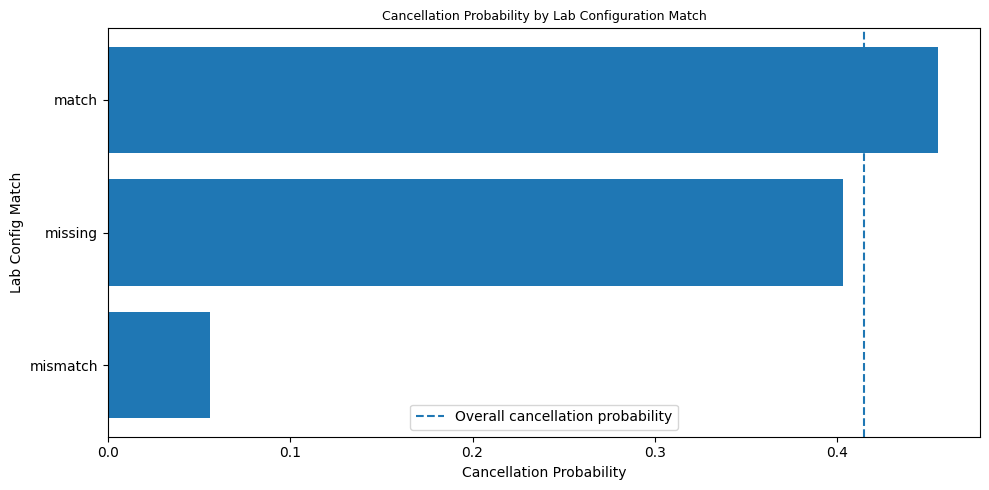

In [233]:
plot_data = lab_match_target_summary.sort_values(
    "cancellation_probability"
)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_data["Lab_Config_Match"],
    plot_data["cancellation_probability"]
)

plt.axvline(
    overall_cancellation_probability,
    linestyle="--",
    label="Overall cancellation probability"
)

plt.title("Cancellation Probability by Lab Configuration Match")
plt.xlabel("Cancellation Probability")
plt.ylabel("Lab Config Match")
plt.legend()

plt.tight_layout()
plt.show()

The match-status analysis shows a clear separation in cancellation probability.

Groups where the requested and assigned lab configurations matched had a cancellation probability of approximately 45.5%, while groups where the configurations differed had a much lower cancellation probability of approximately 5.6%.

This suggests that the relationship between the two lab-configuration variables may contain useful information beyond inspecting each variable separately.

In [234]:
lab_config_pair_summary = (
    lab_config_analysis
    .groupby(["Requested_Lab_Config", "Assigned_Lab_Config"])["Dropped_Course"]
    .agg(
        count="count",
        cancellation_probability="mean"
    )
    .reset_index()
)

lab_config_pair_summary["percentage_of_training_data"] = (
    lab_config_pair_summary["count"] / len(lab_config_analysis) * 100
)

lab_config_pair_summary["difference_from_overall_rate"] = (
    lab_config_pair_summary["cancellation_probability"]
    - overall_cancellation_probability
)

lab_config_pair_summary["is_exact_match"] = (
    lab_config_pair_summary["Requested_Lab_Config"]
    == lab_config_pair_summary["Assigned_Lab_Config"]
)

lab_config_pair_summary = lab_config_pair_summary.sort_values(
    "count",
    ascending=False
)

lab_config_pair_summary.head(20)

,Requested_Lab_Config,Assigned_Lab_Config,count,cancellation_probability,percentage_of_training_data,difference_from_overall_rate,is_exact_match
42,standard pc windows,standard pc windows,35519,0.478336,69.959229,0.063945,True
24,linux workstation,linux workstation,6159,0.364994,12.130941,-0.049396,True
39,standard pc windows,linux workstation,2881,0.043041,5.674499,-0.371349,False
0,dual monitor setup,dual monitor setup,980,0.412245,1.930236,-0.002145,True
16,laptop docking station,laptop docking station,715,0.359441,1.408284,-0.054950,True
33,macos station,macos station,715,0.325874,1.408284,-0.088516,True
38,standard pc windows,laptop docking station,684,0.119883,1.347226,-0.294507,False
40,standard pc windows,macos station,314,0.047771,0.618463,-0.366619,False
8,high-gpu unit,high-gpu unit,236,0.224576,0.464832,-0.189814,True
25,linux workstation,macos station,209,0.066986,0.411652,-0.347404,False


The pair-level inspection shows that the largest exact-match pairs account for a substantial share of the training data and often have cancellation rates above the overall average.

In contrast, many common mismatch pairs have substantially lower cancellation rates.

This supports the idea that the match relationship itself is meaningful and may be represented as a compact interaction feature.

#### Lab Configuration Association Comparison

After observing that the match status between `Requested_Lab_Config` and `Assigned_Lab_Config` is related to cancellation probability, we compare the target association of three lab-related representations:

1. `Requested_Lab_Config`
2. `Assigned_Lab_Config`
3. The derived interaction feature `Lab_Config_Match`

This comparison is still part of the EDA and does not train a model.  
Instead, it evaluates whether the interaction feature captures a strong relationship with the target while using fewer categorical levels.

In [235]:

def prepare_categorical_for_association(series):
    return (
        series
        .astype("object")
        .where(series.notna(), "__missing__")
        .astype(str)
    )


def cramers_v_with_target(feature, target):
    contingency_table = pd.crosstab(feature, target)

    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        return np.nan, np.nan

    chi2, p_value, _, _ = chi2_contingency(
        contingency_table,
        correction=False
    )

    n = contingency_table.to_numpy().sum()
    phi2 = chi2 / n

    r, k = contingency_table.shape
    cramers_v = np.sqrt(phi2 / min(k - 1, r - 1))

    return cramers_v, p_value


features_to_compare = [
    "Requested_Lab_Config",
    "Assigned_Lab_Config",
    "Lab_Config_Match"
]

association_rows = []

for col in features_to_compare:

    feature_values = prepare_categorical_for_association(
        lab_config_analysis[col]
    )

    cramers_v, p_value = cramers_v_with_target(
        feature_values,
        lab_config_analysis["Dropped_Course"]
    )

    encoded_feature, _ = pd.factorize(feature_values)

    mutual_info = mutual_info_classif(
        encoded_feature.reshape(-1, 1),
        lab_config_analysis["Dropped_Course"],
        discrete_features=True,
        random_state=42
    )[0]

    target_rates = (
        pd.DataFrame({
            "feature": feature_values,
            "Dropped_Course": lab_config_analysis["Dropped_Course"]
        })
        .groupby("feature")["Dropped_Course"]
        .agg(["count", "mean"])
    )

    association_rows.append({
        "feature": col,
        "n_categories": feature_values.nunique(),
        "min_cancellation_rate": target_rates["mean"].min(),
        "max_cancellation_rate": target_rates["mean"].max(),
        "cancellation_rate_range": (
            target_rates["mean"].max()
            - target_rates["mean"].min()
        ),
        "weighted_cancellation_rate_std": np.sqrt(
            np.average(
                (
                    target_rates["mean"]
                    - lab_config_analysis["Dropped_Course"].mean()
                ) ** 2,
                weights=target_rates["count"]
            )
        ),
        "cramers_v": cramers_v,
        "chi_square_p_value": p_value,
        "mutual_information": mutual_info
    })

lab_config_association_comparison = (
    pd.DataFrame(association_rows)
    .sort_values("cramers_v", ascending=False)
)

lab_config_association_comparison

,feature,n_categories,min_cancellation_rate,max_cancellation_rate,cancellation_rate_range,weighted_cancellation_rate_std,cramers_v,chi_square_p_value,mutual_information
2,Lab_Config_Match,3,0.056151,0.455466,0.399315,0.119234,0.242041,0.000000e+00,0.036598
1,Assigned_Lab_Config,9,0.047120,1.000000,0.952880,0.101081,0.205192,0.000000e+00,0.022368
0,Requested_Lab_Config,9,0.217391,1.000000,0.782609,0.039483,0.080150,1.106584e-65,0.003316


In [236]:
original_lab_categories = (
    prepare_categorical_for_association(
        lab_config_analysis["Requested_Lab_Config"]
    ).nunique()
    +
    prepare_categorical_for_association(
        lab_config_analysis["Assigned_Lab_Config"]
    ).nunique()
)

match_feature_categories = prepare_categorical_for_association(
    lab_config_analysis["Lab_Config_Match"]
).nunique()

lab_config_dimensionality_comparison = pd.DataFrame({
    "representation": [
        "Original lab-configuration columns",
        "Derived Lab_Config_Match feature"
    ],
    "features_used": [
        "Requested_Lab_Config + Assigned_Lab_Config",
        "Lab_Config_Match"
    ],
    "number_of_categories_before_one_hot": [
        original_lab_categories,
        match_feature_categories
    ]
})

lab_config_dimensionality_comparison

,representation,features_used,number_of_categories_before_one_hot
0,Original lab-configuration columns,Requested_Lab_Config + Assigned_Lab_Config,18
1,Derived Lab_Config_Match feature,Lab_Config_Match,3


#### Lab Configuration EDA Conclusion

The analysis shows that the derived `Lab_Config_Match` feature captures a strong relationship with the target.

The cancellation probability is approximately 45.5% when the requested and assigned configurations match, compared with only approximately 5.6% when they differ. Missing requested or assigned configuration information also shows a cancellation probability close to the overall rate.

The association comparison further supports this finding. `Lab_Config_Match` has the strongest association with the target among the three lab-related representations according to Cramér's V and mutual information.

Although the original `Requested_Lab_Config` and `Assigned_Lab_Config` variables contain information about the specific lab configurations, the derived interaction feature provides a compact representation of the main relationship between them.

In addition, this representation reduces the categorical dimensionality from 18 combined categories before one-hot encoding to only 3 categories.

Therefore, this EDA supports creating `Lab_Config_Match` as a feature-engineering step in Part B, while dropping the two original lab-configuration columns from the modeling pipeline.

### Course Start Day Analysis

In [237]:
# ============================================================
# 24. Course Start Date Analysis
# ============================================================

# Work on a copy only
date_check = X_train[["Course_Start_Date"]].copy()
date_check["Dropped_Course"] = y_train

# Convert to datetime
date_check["Course_Start_Date"] = pd.to_datetime(
    date_check["Course_Start_Date"],
    errors="coerce"
)

In [238]:
# Create candidate date features

date_check["Course_Start_Month"] = (
    date_check["Course_Start_Date"].dt.month
)

date_check["Course_Start_DayOfWeek"] = (
    date_check["Course_Start_Date"].dt.dayofweek
)

date_check["Course_Start_Quarter"] = (
    date_check["Course_Start_Date"].dt.quarter
)

date_check["Course_Start_IsWeekend"] = (
    date_check["Course_Start_DayOfWeek"]
    .isin([5, 6])
    .astype(int)
)

date_features = [
    "Course_Start_Month",
    "Course_Start_DayOfWeek",
    "Course_Start_Quarter",
    "Course_Start_IsWeekend"
]

In [239]:
for col in date_features:

    print(f"\n--- {col} ---")

    result = (
        date_check
        .groupby(col)["Dropped_Course"]
        .agg(
            count="count",
            cancellation_probability="mean"
        )
        .reset_index()
    )

    result["cancellation_probability_%"] = (
        result["cancellation_probability"] * 100
    )

    print(result)


--- Course_Start_Month ---
    Course_Start_Month  count  cancellation_probability  \
0                    1   3035                  0.393410   
1                    2   3996                  0.376627   
2                    3   5156                  0.373933   
3                    4   5476                  0.457633   
4                    5   2922                  0.381930   
5                    6   3140                  0.440446   
6                    7   3619                  0.439072   
7                    8   4674                  0.423192   
8                    9   5932                  0.422117   
9                   10   6045                  0.431762   
10                  11   3459                  0.383637   
11                  12   3317                  0.421767   

    cancellation_probability_%  
0                    39.341021  
1                    37.662663  
2                    37.393328  
3                    45.763331  
4                    38.193018  
5     

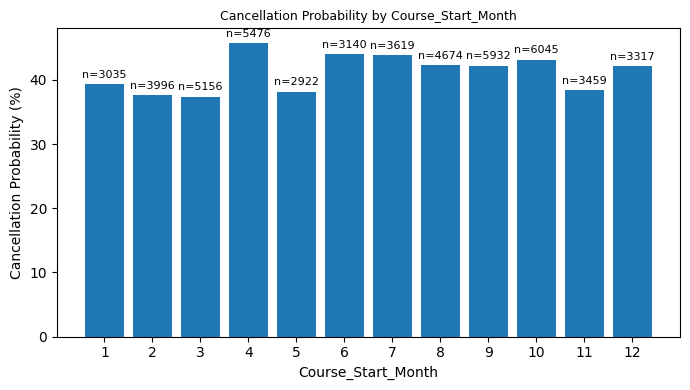

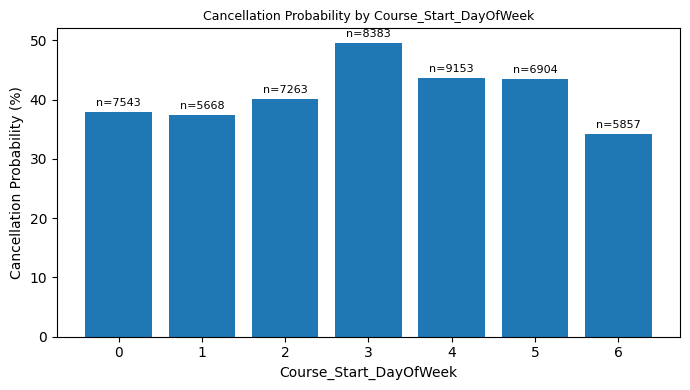

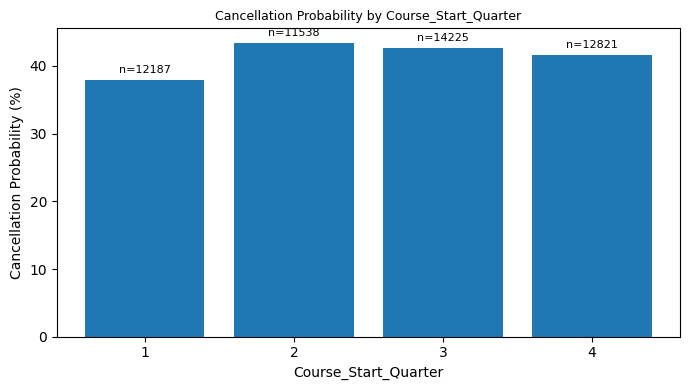

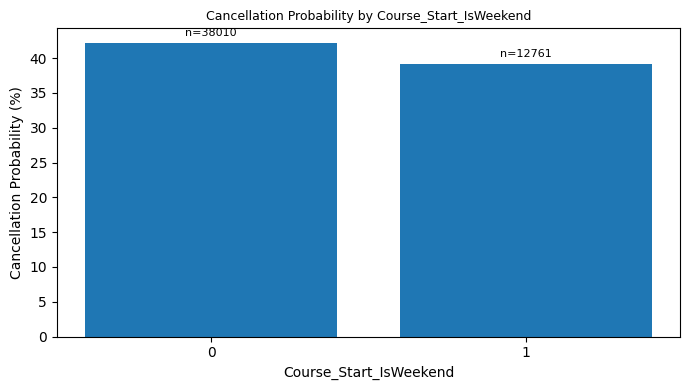

In [240]:
for col in date_features:

    result = (
        date_check
        .groupby(col)["Dropped_Course"]
        .agg(
            count="count",
            cancellation_probability="mean"
        )
        .reset_index()
    )

    result["cancellation_probability_%"] = (
        result["cancellation_probability"] * 100
    )

    plt.figure(figsize=(7, 4))

    plt.bar(
        result[col].astype(str),
        result["cancellation_probability_%"]
    )

    plt.title(
        f"Cancellation Probability by {col}"
    )

    plt.xlabel(col)
    plt.ylabel(
        "Cancellation Probability (%)"
    )

    for i, row in result.iterrows():

        plt.text(
            i,
            row["cancellation_probability_%"] + 1,
            f'n={int(row["count"])}',
            ha="center",
            fontsize=8
        )

    plt.tight_layout()
    plt.show()

#### Course Start Date Analysis - conclusions

Course_Start_Date will be transformed into several candidate date-based features in order to capture potential temporal patterns in course cancellations.

The exploratory analysis revealed meaningful differences in cancellation probability across days of the week, as well as moderate differences across months.

Quarter and IsWeekend provided weaker or more redundant representations of the same temporal information.

This motivates extracting month/day of the week later

### Origin Country Distribution Analysis

In [241]:
# ============================================================
# 27. Origin Country Distribution Analysis
# ============================================================

country_counts = X_train["Origin_Country"].value_counts(
    dropna=False
)

print(
    "Number of unique countries:",
    X_train["Origin_Country"].nunique(dropna=False)
)

country_counts

Number of unique countries: 667


Origin_Country
PRT         19381
FRA          5129
DEU          3205
ESP          2870
GBR          2596
            ...  
  PRT#          1
 ARG            1
GGY             1
  JOR           1
chn!            1
Name: count, Length: 667, dtype: int64

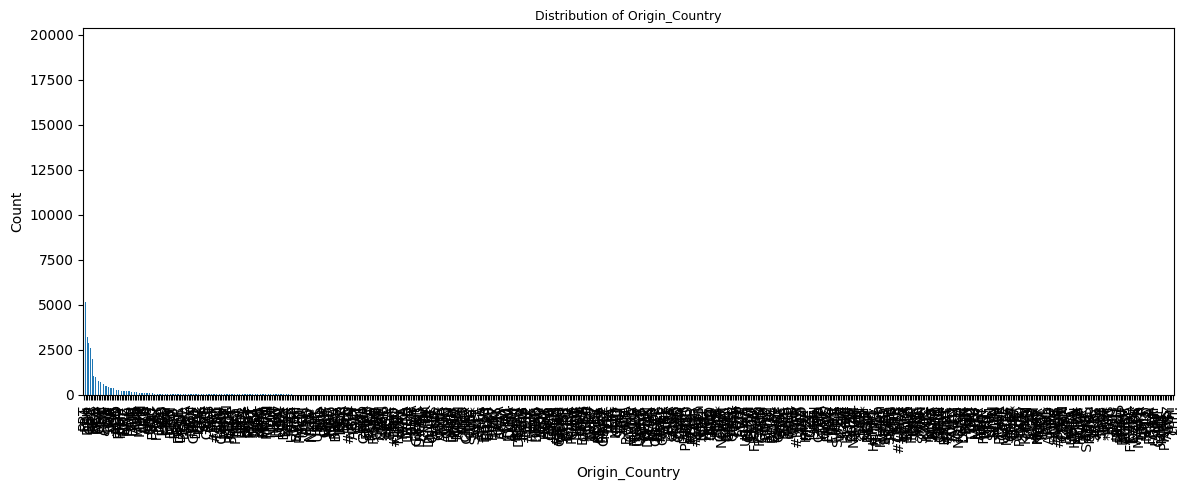

In [242]:
plt.figure(figsize=(12, 5))

country_counts.plot(kind="bar")

plt.title("Distribution of Origin_Country")
plt.xlabel("Origin_Country")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

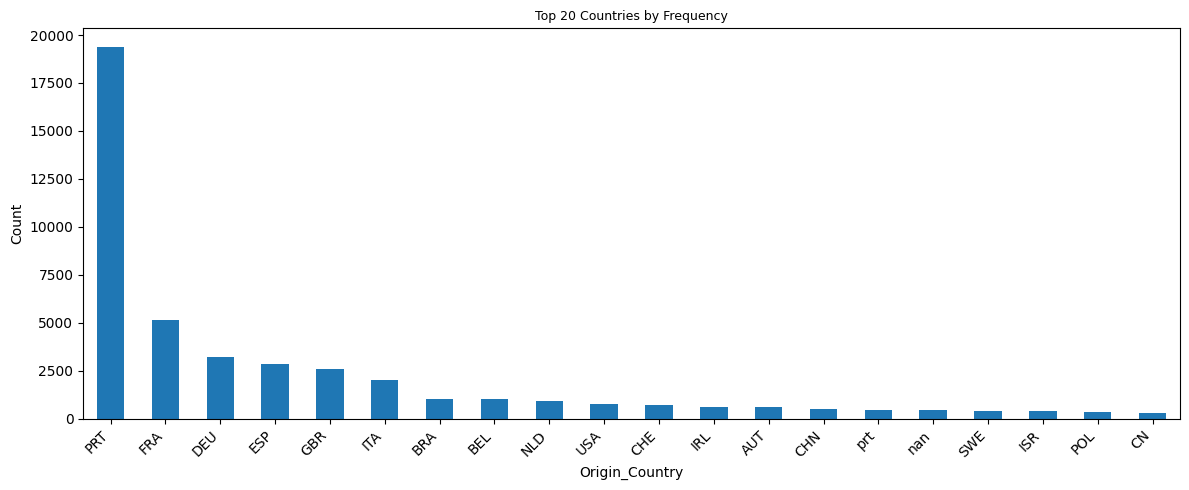

In [243]:
top_n = 20

plt.figure(figsize=(12, 5))

country_counts.head(top_n).plot(
    kind="bar"
)

plt.title(
    f"Top {top_n} Countries by Frequency"
)

plt.xlabel("Origin_Country")
plt.ylabel("Count")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

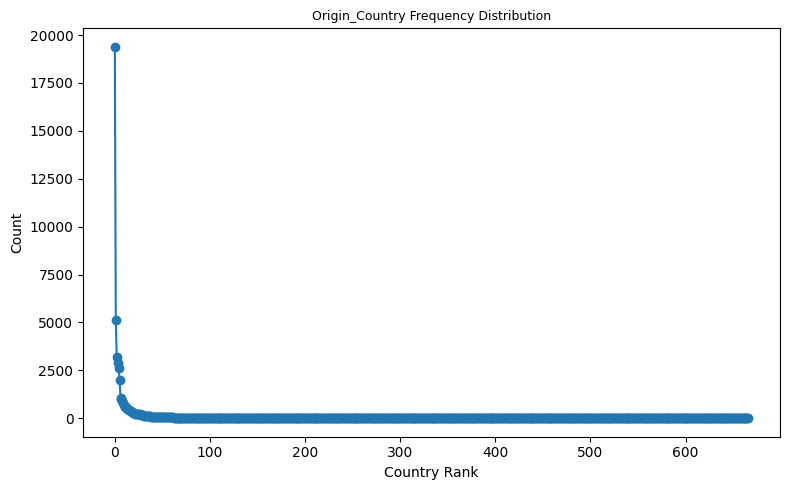

In [244]:
plt.figure(figsize=(8, 5))

country_counts.reset_index(
    drop=True
).plot(
    kind="line",
    marker="o"
)

plt.title(
    "Origin_Country Frequency Distribution"
)

plt.xlabel("Country Rank")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Origin Country comulative examination  

Origin_Country exhibits a highly imbalanced long-tail distribution.

A small number of countries account for most observations, while many countries appear only a few times.

Keeping every country as a separate category would generate many sparse dummy variables and increase the risk of unstable model estimates.

Therefore, we examined cumulative country coverage in order to determine whether rare countries should be grouped into a common category.

In [245]:
country_summary = pd.DataFrame({

    "count":
        country_counts,

    "percentage":
        country_counts /
        len(X_train) * 100,

    "cumulative_percentage":
        country_counts.cumsum() /
        len(X_train) * 100
})

country_summary.head(40)

,count,percentage,cumulative_percentage
Origin_Country,,,
PRT,19381,38.173367,38.173367
FRA,5129,10.102224,48.275590
DEU,3205,6.312659,54.588249
ESP,2870,5.652833,60.241083
GBR,2596,5.113155,65.354238
ITA,1996,3.931378,69.285616
BRA,1028,2.024778,71.310394
BEL,1006,1.981446,73.291840
NLD,919,1.810088,75.101928


#### Origin Country Grouping Conclusion

Origin_Country follows a long-tail distribution, motivates rare category grouping later. we can see that the threshold of 100 observations keeps approximatly 90% precent of the data. therefore, all categories with less than 100 observations were grouped into "other" category.

### Agent ID

In [246]:
# ============================================================
# 29. Agent ID Distribution Analysis
# ============================================================

agent_counts = X_train["Agent_ID"].value_counts(dropna=False)

print(
    "Number of unique agents:",
    X_train["Agent_ID"].nunique(dropna=False)
)

agent_counts

Number of unique agents: 197


Agent_ID
184.0    17644
NaN       8928
218.0     5263
104.0     2087
264.0     1895
         ...  
241.0        1
198.0        1
176.0        1
319.0        1
240.0        1
Name: count, Length: 197, dtype: int64

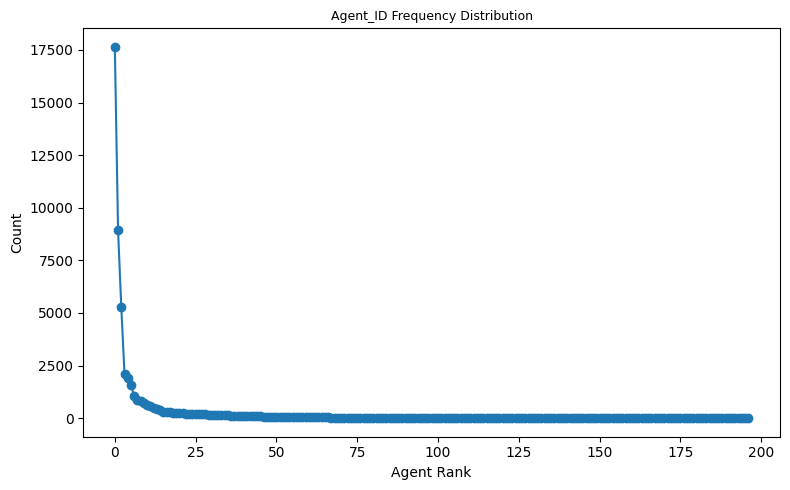

In [247]:
plt.figure(figsize=(8, 5))

agent_counts.reset_index(drop=True).plot(
    kind="line",
    marker="o"
)

plt.title("Agent_ID Frequency Distribution")
plt.xlabel("Agent Rank")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [248]:
agent_summary = pd.DataFrame({
    "count": agent_counts,
    "percentage": agent_counts / len(X_train) * 100,
    "cumulative_percentage": agent_counts.cumsum() / len(X_train) * 100
})

agent_summary.head(50)

,count,percentage,cumulative_percentage
Agent_ID,,,
184.0,17644,34.752122,34.752122
NaN,8928,17.584842,52.336964
218.0,5263,10.366154,62.703118
104.0,2087,4.110614,66.813732
264.0,1895,3.732446,70.546178
219.0,1584,3.119891,73.666069
224.0,1040,2.048413,75.714483
205.0,874,1.721455,77.435938
320.0,814,1.603277,79.039215


In [249]:
print("Top 10 coverage:", agent_summary.head(10)["percentage"].sum())
print("Top 20 coverage:", agent_summary.head(20)["percentage"].sum())
print("Top 30 coverage:", agent_summary.head(30)["percentage"].sum())
print("Top 50 coverage:", agent_summary.head(50)["percentage"].sum())

Top 10 coverage: 80.42780327352227
Top 20 coverage: 88.01087234838788
Top 30 coverage: 91.92846309901321
Top 50 coverage: 96.22225286088515


In [250]:
# ============================================================
# 30. Agent ID Relationship With Target
# ============================================================

agent_target = X_train[["Agent_ID"]].copy()
agent_target["Dropped_Course"] = y_train

agent_target_summary = (
    agent_target
    .groupby("Agent_ID", dropna=False)["Dropped_Course"]
    .agg(
        count="count",
        cancellation_probability="mean"
    )
    .reset_index()
)

agent_target_summary["cancellation_probability_%"] = (
    agent_target_summary["cancellation_probability"] * 100
)

agent_target_summary = agent_target_summary.sort_values(
    "count",
    ascending=False
)

agent_target_summary.head(50)

,Agent_ID,count,cancellation_probability,cancellation_probability_%
69,184.0,17644,0.400193,40.019270
196,NaN,8928,0.338262,33.826165
101,218.0,5263,0.734562,73.456204
4,104.0,2087,0.126018,12.601821
144,264.0,1895,0.175726,17.572559
102,219.0,1584,0.393308,39.330808
107,224.0,1040,0.053846,5.384615
88,205.0,874,0.566362,56.636156
193,320.0,814,0.578624,57.862408
48,158.0,705,0.323404,32.340426


#### Agent ID Analysis

`Agent_ID` has a highly imbalanced long-tail distribution.

A small number of agents cover most observations, while many agents appear only rarely.

Although `Agent_ID` is an identifier-like feature, the cancellation rates vary substantially across frequent agents, suggesting that the feature may contain useful predictive information.

However, keeping all agents as separate dummy variables may create many sparse and unstable features.

Therefore, agents with fewer than 100 observations will be grouped into an `other_agent` category before encoding.

## Missing Values

### Missing Values Analysis and Treatment Plan

This section analyzes missing values after the exploratory data analysis and categorical value inspection.

First, we summarize standard missing values (`NaN`) in the training split.  
Then, we examine whether missingness is related to the target variable, `Dropped_Course`.

For categorical and categorical-like features, the previous categorical value inspection showed that unavailable information may sometimes be represented both as standard missing values and as explicit unknown-like labels. Therefore, a separate analysis later in this section combines these two representations and checks their relationship with the target.

No missing-value treatment is applied at this stage. The results of this section will be used to justify the treatment plan below.

### Missing Value Summary

In [251]:
# ============================================================
# Missing Value Summary
# ============================================================

# Check standard missing values in the training split only.
# We use X_train because all EDA and preprocessing decisions should be based
# only on the training data, not on the validation or external test data.

missing_values = (
    X_train
    .isna()
    .sum()
    .to_frame(name="missing_count")
)

missing_values["missing_percentage"] = (
    missing_values["missing_count"] / len(X_train) * 100
)

missing_values = (
    missing_values[missing_values["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
)

missing_cols = missing_values.index.tolist()

missing_values

,missing_count,missing_percentage
Company_ID,48295,95.123200
Agent_ID,8928,17.584842
Registration_Days_Before,2126,4.187430
Requested_Lab_Config,1394,2.745662
Physical_Course_Kits,819,1.613126
Enrollment_Type,563,1.108901
Submission_Source,474,0.933604
Payment_Terms,463,0.911938
Origin_Country,438,0.862697
Catering_Package,337,0.663765


### Missingness vs Target Analysis

Before deciding how to handle missing values, we examine whether standard missing values (`NaN`) are related to the target variable, `Dropped_Course`.

For each feature with missing values, we compare the cancellation probability between observations where the feature is missing and observations where the feature is available.

This analysis is performed only on the training split.

In [252]:
missingness_target_summary = []

for col in missing_cols:

    temp = pd.DataFrame({
        "is_missing": X_train[col].isna(),
        "Dropped_Course": y_train
    })

    grouped = (
        temp
        .groupby("is_missing")["Dropped_Course"]
        .agg(["count", "mean"])
    )

    missing_count = grouped.loc[True, "count"] if True in grouped.index else 0
    not_missing_count = grouped.loc[False, "count"] if False in grouped.index else 0

    missing_rate = grouped.loc[True, "mean"] if True in grouped.index else np.nan
    not_missing_rate = grouped.loc[False, "mean"] if False in grouped.index else np.nan

    missingness_target_summary.append({
        "feature": col,
        "missing_count": missing_count,
        "not_missing_count": not_missing_count,
        "cancellation_probability_missing": missing_rate,
        "cancellation_probability_not_missing": not_missing_rate,
        "difference_missing_minus_not_missing": missing_rate - not_missing_rate
    })

missingness_target_summary = pd.DataFrame(missingness_target_summary)

missingness_target_summary["absolute_difference"] = (
    missingness_target_summary["difference_missing_minus_not_missing"].abs()
)

missingness_target_summary = (
    missingness_target_summary
    .sort_values("absolute_difference", ascending=False)
)

missingness_target_summary

,feature,missing_count,not_missing_count,cancellation_probability_missing,cancellation_probability_not_missing,difference_missing_minus_not_missing,absolute_difference
11,Students_Count,4,50767,1.000000,0.414344,0.585656,0.585656
0,Company_ID,48295,2476,0.424682,0.213651,0.211031,0.211031
10,Daily_Tuition_Cost,65,50706,0.523077,0.414251,0.108826,0.108826
1,Agent_ID,8928,41843,0.338262,0.430634,-0.092372,0.092372
6,Submission_Source,474,50297,0.459916,0.413961,0.045955,0.045955
7,Payment_Terms,463,50308,0.369330,0.414805,-0.045474,0.045474
4,Physical_Course_Kits,819,49952,0.379731,0.414958,-0.035227,0.035227
9,Catering_Package,337,50434,0.385757,0.414581,-0.028825,0.028825
8,Origin_Country,438,50333,0.426941,0.414281,0.012660,0.012660
3,Requested_Lab_Config,1394,49377,0.403156,0.414707,-0.011551,0.011551


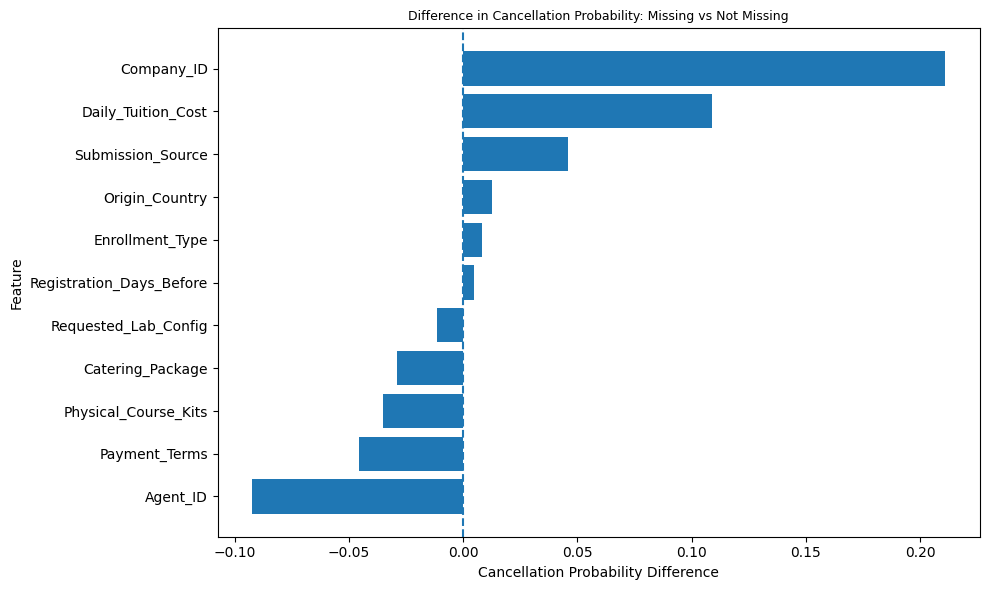

In [253]:
min_missing_count_for_plot = 30

missingness_for_plot = missingness_target_summary[
    missingness_target_summary["missing_count"] >= min_missing_count_for_plot
].copy()

missingness_for_plot = missingness_for_plot.sort_values(
    "difference_missing_minus_not_missing"
)

plt.figure(figsize=(10, 6))

plt.barh(
    missingness_for_plot["feature"],
    missingness_for_plot["difference_missing_minus_not_missing"]
)

plt.axvline(0, linestyle="--")

plt.title("Difference in Cancellation Probability: Missing vs Not Missing")
plt.xlabel("Cancellation Probability Difference")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


### Missingness vs Target Analysis Conclusions

The standard missingness-vs-target analysis shows that not all missing values carry the same level of information.

The most important finding is for `Company_ID`. This feature is missing in about 95% of the training observations, and the cancellation probability is much higher when `Company_ID` is missing than when it is available. This suggests that the availability of a company identifier is informative and should not be treated as a regular missing numeric value.

`Agent_ID` also shows a meaningful missingness pattern, but in the opposite direction: observations with missing `Agent_ID` have a lower cancellation probability than observations where `Agent_ID` is available. Since `Agent_ID` is an identifier-like feature rather than a continuous numeric variable, this supports treating missing agent information as a meaningful category rather than applying standard numeric imputation.

`Daily_Tuition_Cost` shows a noticeable difference between missing and non-missing observations, but the number of missing values is small. Therefore, this pattern should be interpreted cautiously.

`Students_Count` shows the largest difference, but it has only 4 missing values, so the result is not reliable enough to support a separate conclusion.

For the remaining features, the missingness differences are relatively small and do not suggest strong standalone missingness patterns.

These findings will be combined with the categorical unavailable-information analysis before defining the final missing-value treatment plan.

### Categorical Unavailable Information vs Target

In the categorical value inspection section, we identified that some categorical features may represent unavailable information in two ways: standard missing values and explicit unknown-like labels.

Therefore, for categorical and categorical-like features, we now create a broader unavailable-information indicator:

`unavailable = missing value OR explicit unknown-like label`

This analysis does not modify the data and does not perform imputation.  
Its purpose is to check whether unavailable categorical information is related to `Dropped_Course`, so that the later missing-value treatment plan can be better justified.

The unknown-like label list and categorical feature list are taken from the earlier categorical value inspection section.

In [254]:
# ============================================================
# Categorical unavailable information vs target
# ============================================================

# This logic follows the Categorical Value Inspection section.
# In that section, we identified explicit unknown-like labels and included
# categorical-like identifiers such as Agent_ID, even though Agent_ID is numeric-looking.
#
# Here we combine:
#   1. standard missing values
#   2. explicit unknown-like labels
#
# into one "unavailable information" indicator for target analysis.

categorical_unavailable_target_summary = []

for col in categorical_cols_for_analysis:

    col_as_text = (
        X_train_categorical_eda[col]
        .astype("string")
        .str.strip()
        .str.lower()
    )

    missing_mask = X_train_categorical_eda[col].isna()
    explicit_unknown_mask = col_as_text.isin(unknown_like_values_for_eda)

    unavailable_mask = missing_mask | explicit_unknown_mask

    # Skip features where there is no missing or unknown-like representation.
    if unavailable_mask.sum() == 0:
        continue

    temp = pd.DataFrame({
        "is_unavailable": unavailable_mask,
        "Dropped_Course": y_train
    })

    grouped = (
        temp
        .groupby("is_unavailable")["Dropped_Course"]
        .agg(["count", "mean"])
    )

    unavailable_count = grouped.loc[True, "count"] if True in grouped.index else 0
    available_count = grouped.loc[False, "count"] if False in grouped.index else 0

    unavailable_rate = grouped.loc[True, "mean"] if True in grouped.index else np.nan
    available_rate = grouped.loc[False, "mean"] if False in grouped.index else np.nan

    categorical_unavailable_target_summary.append({
        "feature": col,
        "missing_count": missing_mask.sum(),
        "explicit_unknown_label_count": explicit_unknown_mask.sum(),
        "unavailable_count": unavailable_count,
        "available_count": available_count,
        "cancellation_probability_unavailable": unavailable_rate,
        "cancellation_probability_available": available_rate,
        "difference_unavailable_minus_available": unavailable_rate - available_rate
    })

categorical_unavailable_target_summary = pd.DataFrame(
    categorical_unavailable_target_summary
)

categorical_unavailable_target_summary["absolute_difference"] = (
    categorical_unavailable_target_summary[
        "difference_unavailable_minus_available"
    ].abs()
)

categorical_unavailable_target_summary = (
    categorical_unavailable_target_summary
    .sort_values("absolute_difference", ascending=False)
)

categorical_unavailable_target_summary

,feature,missing_count,explicit_unknown_label_count,unavailable_count,available_count,cancellation_probability_unavailable,cancellation_probability_available,difference_unavailable_minus_available,absolute_difference
4,Client_Category,0,2,2,50769,1.000000,0.414367,0.585633,0.585633
7,Agent_ID,8928,0,8928,41843,0.338262,0.430634,-0.092372,0.092372
1,Catering_Package,337,0,337,50434,0.385757,0.414581,-0.028825,0.028825
5,Submission_Source,623,180,803,49968,0.440847,0.413965,0.026882,0.026882
6,Payment_Terms,628,174,802,49969,0.389027,0.414797,-0.025770,0.025770
0,Origin_Country,438,0,438,50333,0.426941,0.414281,0.012660,0.012660
2,Requested_Lab_Config,1394,0,1394,49377,0.403156,0.414707,-0.011551,0.011551
3,Enrollment_Type,563,0,563,50208,0.422735,0.414297,0.008439,0.008439


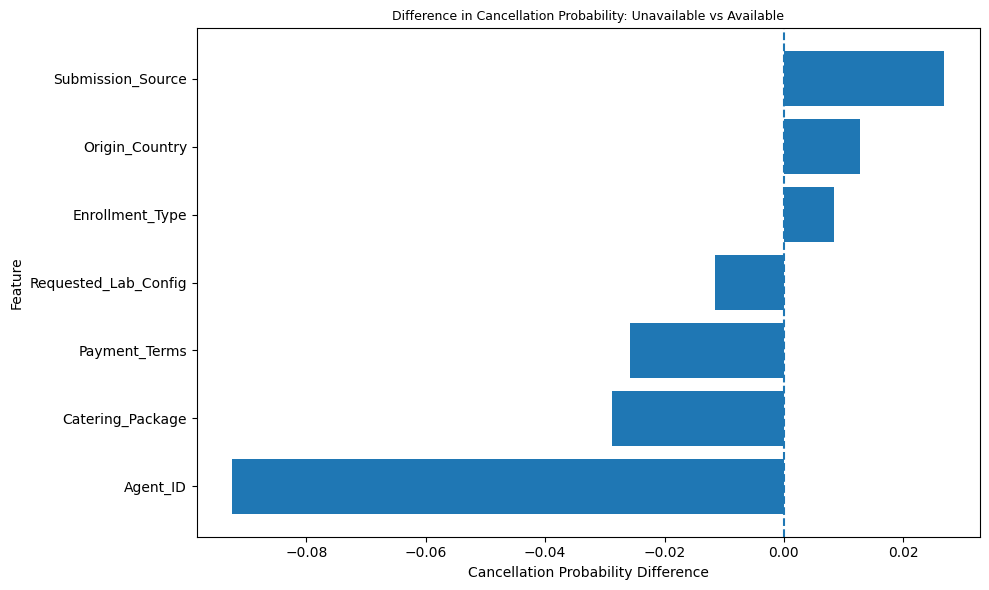

In [255]:
min_unavailable_count_for_plot = 30

categorical_unavailable_for_plot = categorical_unavailable_target_summary[
    categorical_unavailable_target_summary["unavailable_count"] >= min_unavailable_count_for_plot
].copy()

categorical_unavailable_for_plot = categorical_unavailable_for_plot.sort_values(
    "difference_unavailable_minus_available"
)

plt.figure(figsize=(10, 6))

plt.barh(
    categorical_unavailable_for_plot["feature"],
    categorical_unavailable_for_plot["difference_unavailable_minus_available"]
)

plt.axvline(0, linestyle="--")

plt.title("Difference in Cancellation Probability: Unavailable vs Available")
plt.xlabel("Cancellation Probability Difference")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Categorical Unavailable Information vs Target Conclusions

The combined unavailable-information analysis shows that only a few categorical features contain both standard missing values and explicit unknown-like labels.

The main duplicated representation appears in `Submission_Source` and `Payment_Terms`. In both features, unavailable information appears both as missing values and as explicit `"unknown"` labels. Therefore, these two representations should be treated consistently later in the preprocessing pipeline.

For `Submission_Source`, the cancellation probability is slightly higher when the information is unavailable (`0.441`) compared to when it is available (`0.414`). However, after combining missing values with explicit unknown labels, the difference is moderate rather than strong.

For `Payment_Terms`, the cancellation probability is slightly lower when the information is unavailable (`0.389`) compared to when it is available (`0.415`). This difference is also moderate.

For `Agent_ID`, the combined analysis gives the same result as the standard missingness analysis, because no explicit unknown-agent labels were found in the cleaned categorical values. The meaningful pattern for this feature comes from missing values themselves: observations with unavailable `Agent_ID` have a lower cancellation probability than observations with an available `Agent_ID`.

`Client_Category` shows a large difference, but only 2 observations contain unavailable information. Therefore, this result is not reliable and should not drive a separate preprocessing decision.

For the remaining categorical features, unavailable-information differences are small. These features do not show strong standalone evidence that missing or unknown categorical information is highly predictive.

Overall, this analysis supports unifying missing values and explicit unknown-like labels for categorical features where both representations appear, especially `Submission_Source` and `Payment_Terms`. However, the target differences are mostly modest, so the main purpose of this treatment is consistency of categorical representation rather than creating a strong predictive signal.

### Missing Values Treatment Plan

Based on the missing-value summary, the standard missingness-vs-target analysis, and the categorical unavailable-information analysis, different types of missing values require different treatment.

`Company_ID` has an extremely high missing rate and is also an identifier-like feature. Although the missingness analysis shows that the availability of `Company_ID` is informative, the raw identifier itself should not be imputed or used directly as a numeric feature. Therefore, the raw `Company_ID` column will be removed from the modeling pipeline. Its availability may be considered later in the feature-engineering stage as a separate binary indicator.

`Agent_ID` is numeric-looking, but it represents a categorical identifier rather than a continuous numeric feature. The analysis showed that unavailable `Agent_ID` information is associated with a different cancellation probability. Therefore, both missing `Agent_ID` values and explicit unknown-like agent labels will be unified into a single `"unknown_agent"` category. The feature will then be handled as categorical rather than numeric.

For `Submission_Source` and `Payment_Terms`, the categorical value inspection showed that unavailable information is represented both as standard missing values and as explicit `"unknown"` labels. Therefore, missing values and explicit unknown-like labels in these features will be unified into a single `"unknown"` category.

For other categorical features with missing values, such as `Origin_Country`, `Requested_Lab_Config`, `Enrollment_Type`, and `Catering_Package`, missing values represent unavailable category information. Therefore, they will also be filled with `"unknown"` rather than with the most frequent category.

For standard numeric features with missing values, such as `Registration_Days_Before` and `Daily_Tuition_Cost`, median imputation will be applied inside the preprocessing pipeline.

For sparse count features, such as `Students_Count` and `Physical_Course_Kits`, missing values will not be manually interpreted as zero. During feature engineering, binary indicators will be created while preserving missing values. For example, a missing count remains missing in the derived indicator, while positive counts are converted to 1 and zero counts are converted to 0. The remaining missing indicator values will then be handled inside the preprocessing pipeline.

No rows are removed due to missing values. All missing-value handling will be implemented inside the preprocessing pipeline to avoid data leakage and ensure consistent treatment of the training, validation, and external test sets.

In [256]:
# ============================================================
# Missing Values Treatment Plan - pipeline decisions
# ============================================================

# These objects summarize the missing-value treatment decisions derived from:
# 1. Missing Value Summary
# 2. Missingness vs Target Analysis
# 3. Categorical Unavailable Information vs Target
#
# The combined unavailable-information logic was prepared in the
# Categorical Value Inspection section, where we identified that some
# categorical features contain both standard missing values and explicit
# unknown-like labels.
#
# This cell does not modify X_train directly.
# The decisions will be implemented later inside the preprocessing pipeline.

RAW_IDENTIFIER_COLUMNS_TO_DROP = [
    "Company_ID"
]

# Company_ID availability was informative, but the raw identifier itself
# will not be used directly. If used, the availability signal should be
# created later in the feature-engineering stage before dropping Company_ID.
COMPANY_ID_AVAILABILITY_FEATURE = "Has_Company_ID"


# Unknown-like labels identified during the categorical value inspection.
# These labels represent unavailable categorical information.
UNKNOWN_LIKE_VALUES_FOR_PIPELINE = {
    "unknown",
    "unknown_agent",
    "unknown agent",
    "unknown_country",
    "unknown country",
    "na",
    "n/a",
    "none",
    "nan",
    ""
}


# Categorical / categorical-like features where missing values should be
# represented as an explicit unavailable-information category.
#
# For Agent_ID, both NaN values and explicit unknown-like labels will be
# unified into "unknown_agent".
#
# For other categorical features, NaN values and explicit unknown-like labels
# will be unified into "unknown".
CATEGORICAL_UNAVAILABLE_FILL_VALUES = {
    "Agent_ID": "unknown_agent",
    "Submission_Source": "unknown",
    "Payment_Terms": "unknown",
    "Origin_Country": "unknown",
    "Requested_Lab_Config": "unknown",
    "Enrollment_Type": "unknown",
    "Catering_Package": "unknown"
}

CATEGORICAL_UNAVAILABLE_FILL_VALUES = {
    col: fill_value
    for col, fill_value in CATEGORICAL_UNAVAILABLE_FILL_VALUES.items()
    if col in X_train.columns
}


# Numeric missing values will be handled by median imputation inside the
# preprocessing pipeline.
NUMERIC_MISSING_IMPUTATION_STRATEGY = "median"


# Sparse count features will be transformed later during feature engineering.
# Missing values are preserved during binary-indicator creation because
# missing does not necessarily mean zero.
SPARSE_COUNT_FEATURES_WITH_MISSING = [
    "Students_Count",
    "Physical_Course_Kits"
]

SPARSE_COUNT_FEATURES_WITH_MISSING = [
    col for col in SPARSE_COUNT_FEATURES_WITH_MISSING
    if col in X_train.columns
]


missing_value_treatment_decisions = pd.DataFrame([
    {
        "feature_group": "Company_ID",
        "treatment": "Drop raw identifier; consider availability indicator later",
        "reason": "Very high missing rate and identifier-like feature; availability is informative"
    },
    {
        "feature_group": "Agent_ID",
        "treatment": 'Unify missing and unknown-like labels as "unknown_agent"; treat as categorical',
        "reason": "Numeric-looking identifier; unavailable agent information is related to the target"
    },
    {
        "feature_group": "Submission_Source, Payment_Terms",
        "treatment": 'Unify missing values and unknown-like labels as "unknown"',
        "reason": "Both NaN and explicit unknown labels represent unavailable information"
    },
    {
        "feature_group": "Other categorical missing values",
        "treatment": 'Fill missing values with "unknown"',
        "reason": "Missing categorical values represent unavailable category information"
    },
    {
        "feature_group": "Standard numeric missing values",
        "treatment": "Median imputation inside the preprocessing pipeline",
        "reason": "Robust numeric imputation without using validation/test information"
    },
    {
        "feature_group": "Sparse count features",
        "treatment": "Preserve missing values during binary-indicator creation; impute later in pipeline",
        "reason": "Missing count values are not necessarily equivalent to zero"
    }
])

missing_value_treatment_decisions

,feature_group,treatment,reason
0,Company_ID,Drop raw identifier; consider availability ind...,Very high missing rate and identifier-like fea...
1,Agent_ID,"Unify missing and unknown-like labels as ""unkn...",Numeric-looking identifier; unavailable agent ...
2,"Submission_Source, Payment_Terms",Unify missing values and unknown-like labels a...,Both NaN and explicit unknown labels represent...
3,Other categorical missing values,"Fill missing values with ""unknown""",Missing categorical values represent unavailab...
4,Standard numeric missing values,Median imputation inside the preprocessing pip...,Robust numeric imputation without using valida...
5,Sparse count features,Preserve missing values during binary-indicato...,Missing count values are not necessarily equiv...


## Summary and Preprocessing Implications

The exploratory data analysis identified several important patterns, data-quality issues, and preprocessing implications that will guide the later feature-engineering and modeling stages.

The target variable, `Dropped_Course`, represents whether a course registration was cancelled. The target distribution is moderately imbalanced, with approximately `41.4%` cancelled observations and `58.6%` non-cancelled observations. Since the task focuses on estimating cancellation probabilities rather than only producing hard class labels, ROC-AUC will be used later as the primary evaluation metric, together with additional classification metrics.

The numeric analysis showed that several numeric features are meaningfully related to cancellation probability. `Registration_Days_Before` presented the strongest numeric signal: registrations made very close to the course start date had substantially lower cancellation rates, whereas registrations made far in advance showed considerably higher cancellation rates. Since this relationship was not entirely linear, the feature was retained for later examination of a `log1p` transformation.

`Pre_Course_Supports_Tickets` showed a clear negative relationship with cancellation. Observations with no pre-course support tickets had substantially higher cancellation rates, while observations with at least one support interaction had much lower rates. This suggests that the existence of support activity may carry more stable information than the exact number of tickets and motivates examining a binary representation. `Registration_Changes` also contained predictive information, but its relationship with the target appeared weaker and more threshold-like. Therefore, both a `log1p` transformation and a binary representation were considered for later comparison.

The sparsity analysis showed that several count-based features are highly zero-inflated. However, a low Pearson correlation or a high proportion of zero values does not necessarily imply an absence of predictive information, since positive values may represent rare but meaningful business events.

A dedicated analysis of `Waiting_List_Days` showed that waiting-list activity contains useful information. Observations with positive waiting-list days had a higher cancellation rate than observations with no waiting period. However, the relationship between the exact positive number of waiting days and cancellation was not clearly monotonic, and some high waiting-day values were supported by relatively few observations. This motivated retaining the numeric information while limiting the influence of unstable extreme values through percentile-based capping.

A separate sparse-count analysis was performed for `Students_Count`, `Observers_Count`, and `Physical_Course_Kits`. The analysis compared cancellation probability by exact count value with a simpler binary split of `0` versus `>0`. All three variables contained target-related information. In each case, positive values were associated with a lower cancellation rate than zero values. However, the exact positive counts were sparse and, in some cases, based on very few observations. Therefore, the distinction between zero and a positive value appeared to provide a more stable representation than the original exact count values.

For these sparse count features, binary indicators will be created from the distinction between zero and positive values. Missing values will not be manually converted to zero during feature engineering; instead, they will be left as missing and handled later by the numeric imputation step in the preprocessing pipeline. This avoids explicitly assuming during feature engineering that unavailable count information means that the event did not occur.

Before performing the categorical analyses, categorical text values were cleaned in a temporary EDA copy of the training split. The cleaning included standardizing casing, removing unnecessary spaces and selected special characters, replacing empty strings with missing values, and reducing duplicated category representations caused by inconsistent formatting. All subsequent categorical EDA analyses were performed on the cleaned copy, while the original `X_train` was not modified. This ensured that categorical patterns were analyzed after reducing formatting noise, while the actual cleaning logic would still be implemented later inside the preprocessing pipeline.

The categorical analysis revealed substantial differences in cancellation probability across several features. The strongest selected categorical signals were found in `Payment_Terms`, `Client_Category`, `Enrollment_Type`, and `Assigned_Lab_Config`. `Assigned_Lab_Config` appeared more informative than `Requested_Lab_Config` when each lab-configuration variable was examined separately. Other categorical variables also contained some signal, but several patterns were weaker, less stable, or based on small categories and therefore required more cautious interpretation.

The client-history analysis showed that previous interaction with the company is highly informative. Previous successful course attendance was associated with a substantially lower cancellation probability, whereas previous course dropouts were associated with a much higher cancellation probability. The consistency analysis also showed that `Returning_Client` alone did not fully capture prior company interaction. These findings support a more comprehensive representation of whether any previous company history exists, while preserving previous attendance and previous dropout as distinct signals.

The requested-versus-assigned lab configuration analysis showed that the relationship between `Requested_Lab_Config` and `Assigned_Lab_Config` is associated with cancellation probability. Although `Assigned_Lab_Config` contained a strong standalone categorical signal, the derived `Lab_Config_Match` feature captured the main interaction between the requested and assigned configurations in a more compact form.

`Lab_Config_Match`, containing the categories `match`, `mismatch`, and `missing`, showed the strongest association with the target among the lab-related representations according to Cramér’s V and mutual information. It also reduced the categorical space from 18 combined categories to only 3 categories. Therefore, the EDA supports using `Lab_Config_Match` in the feature-engineering stage while removing both original lab-configuration columns from the modeling pipeline.

The course-start-date analysis showed that temporal information is useful, particularly the month and day of the week. Quarter and weekend indicators provided weaker or partly redundant representations. Treating each exact date as a separate categorical value would generate many sparse dummy variables and intensify the curse of dimensionality. Therefore, the findings support replacing the raw date with two selected time features: `Course_Start_Month` and `Course_Start_DayOfWeek`.

The high-cardinality analysis showed that both `Origin_Country` and `Agent_ID` contain useful information but require careful treatment. `Origin_Country` follows a long-tail distribution containing many rare country values. `Agent_ID` is a numeric-looking feature, but it represents a categorical identifier rather than a quantitative variable. Encoding every raw category separately would produce a large number of sparse one-hot encoded features, increase model complexity, and intensify the curse of dimensionality.

A minimum-frequency threshold of `100` observations was examined as a practical way to preserve common categories while grouping rare categories into an `other` category. This threshold keeps the dominant category-level information while reducing the number of rare and unstable categories. Missing `Agent_ID` values are treated as a meaningful unavailable-information category rather than as numeric missingness.

The missing-values analysis showed that missingness is not equally informative across all features. `Company_ID` had an extremely high missing rate, and its availability was associated with cancellation probability. Since it is an identifier rather than a meaningful quantitative variable, the findings support removing the raw column and preserving only its availability through `Has_Company_ID`.

Missingness in `Agent_ID` was also associated with cancellation probability. Since no explicit unknown category previously existed for this feature, its missing values were assigned to a newly created `unknown_agent` category. In `Submission_Source` and `Payment_Terms`, unavailable information appeared both as standard missing values and as explicit unknown-like labels, so these representations were unified. Missing values in the remaining categorical features were represented as `unknown`, while standard numeric missing values were handled using median imputation.

Overall, the EDA supports a preprocessing strategy that combines categorical text cleaning, explicit and consistent handling of unavailable information, careful treatment of high-cardinality variables, stable representations of sparse count features, and compact transformations of interaction and date variables. These steps aim to preserve predictive information while reducing noise, sparsity, and unnecessary dimensionality. No observations were removed due to missing values, and all imputation and preprocessing parameters will be learned from the training data and applied consistently to the validation and external test sets within the pipeline.

# Part B - Feature Engineering and Outlier Analysis

In this section, we translate the findings from the exploratory data analysis into concrete preprocessing and feature-engineering decisions.

The goal of this stage is to improve the dataset before model training by:
- handling invalid or business-implausible numeric values
- reducing the influence of unstable extreme values
- creating informative derived features
- reducing dimensionality caused by sparse and high-cardinality variables
- preparing a consistent preprocessing pipeline for training, validation, and external test data

All decisions in this section are based on the training split and on the EDA conclusions from Part A. Transformations that require fitting, such as rare-category grouping or capping thresholds, are learned only from the training data.

## Goals and Connection to EDA

Part A identified several patterns that directly motivate the preprocessing and feature-engineering steps in this section.

The EDA showed that some numeric features contain invalid or business-implausible values, while other extreme values appear to be valid but highly skewed. Therefore, this section separates invalid-value handling from general outlier treatment.

The EDA also showed that several sparse count variables mainly carry information through the existence of an event rather than through the exact count. These features motivate binary indicators.

Several categorical features contain many rare values or identifier-like categories. To reduce dimensionality and avoid creating many unstable one-hot encoded columns, rare categories will be grouped later based only on the training split.

Finally, several relationships observed in the EDA, such as the non-linear behavior of `Registration_Days_Before`, the binary-like behavior of `Pre_Course_Supports_Tickets`, and the high missing rate of `Company_ID`, motivate specific feature-engineering decisions that are documented below.

## Numeric Outlier Analysis

In this section, we examine numeric features that may contain extreme or business-implausible values.

The goal is to distinguish between:

- statistically unusual values that may still be valid business observations
- clearly invalid values that likely represent data-entry or system errors
- highly skewed or sparse numeric variables that may require transformation later

Identifier-like columns are excluded from this analysis because their numeric values do not represent meaningful continuous quantities. Exact binary variables are also excluded.

Sparse count variables are kept in this analysis only to inspect their value ranges and detect potentially invalid extreme values. Their feature-engineering treatment is documented later in the dedicated sparse-feature section.

At this stage, the analysis is performed only on the training split. The original `X_train` is not modified directly.

In [257]:
# ============================================================
# Numeric Outlier Analysis
# ============================================================

# Select numeric columns
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

# Identifier-like columns should not be treated as continuous quantitative variables
id_cols = ["Client_ID", "Company_ID", "Agent_ID"]

# Identify exact binary columns automatically
binary_cols = []

for col in numeric_cols:
    unique_values = set(X_train[col].dropna().unique())

    if unique_values.issubset({0, 1}):
        binary_cols.append(col)

# Keep numeric columns that should be inspected for outliers or invalid values
numeric_outlier_cols = [
    col for col in numeric_cols
    if col not in id_cols and col not in binary_cols
]

numeric_outlier_cols

['Professionals_Count',
 'Students_Count',
 'Observers_Count',
 'Practical_Hours',
 'Theory_Hours',
 'Registration_Days_Before',
 'Prev_Course_Dropouts',
 'Prev_Course_Attended',
 'Pre_Course_Supports_Tickets',
 'Physical_Course_Kits',
 'Waiting_List_Days',
 'Registration_Changes',
 'Daily_Tuition_Cost']

In [258]:
# Compact numeric summary for outlier and invalid-value analysis

numeric_outlier_summary = pd.DataFrame(index=numeric_outlier_cols)

numeric_outlier_summary["count"] = X_train[numeric_outlier_cols].count()
numeric_outlier_summary["missing_percentage"] = (
    X_train[numeric_outlier_cols].isna().mean() * 100
)
numeric_outlier_summary["zero_percentage"] = (
    (X_train[numeric_outlier_cols] == 0).mean() * 100
)

numeric_outlier_summary["mean"] = X_train[numeric_outlier_cols].mean()
numeric_outlier_summary["std"] = X_train[numeric_outlier_cols].std()
numeric_outlier_summary["min"] = X_train[numeric_outlier_cols].min()
numeric_outlier_summary["q1"] = X_train[numeric_outlier_cols].quantile(0.25)
numeric_outlier_summary["median"] = X_train[numeric_outlier_cols].median()
numeric_outlier_summary["q3"] = X_train[numeric_outlier_cols].quantile(0.75)
numeric_outlier_summary["q95"] = X_train[numeric_outlier_cols].quantile(0.95)
numeric_outlier_summary["q99"] = X_train[numeric_outlier_cols].quantile(0.99)
numeric_outlier_summary["q999"] = X_train[numeric_outlier_cols].quantile(0.999)
numeric_outlier_summary["max"] = X_train[numeric_outlier_cols].max()

numeric_outlier_summary

,count,missing_percentage,zero_percentage,mean,std,min,q1,median,q3,q95,q99,q999,max
Professionals_Count,50771,0.000000,0.512103,1.833704,0.507865,0.0,2.0,2.0,2.0,3.0,3.0000,3.00000,4.0
Students_Count,50767,0.007879,93.939454,8.553824,290.882083,0.0,0.0,0.0,0.0,1.0,2.0000,3.00000,9999.0
Observers_Count,50771,0.000000,99.499714,0.005456,0.094093,0.0,0.0,0.0,0.0,0.0,0.0000,1.00000,10.0
Practical_Hours,50771,0.000000,48.405586,6.785941,220.691243,-5.0,0.0,1.0,1.0,2.0,3.0000,8.23000,10000.0
Theory_Hours,50771,0.000000,6.257509,2.165725,1.470058,0.0,1.0,2.0,3.0,5.0,6.0000,15.00000,41.0
Registration_Days_Before,48645,4.187430,4.069252,103.203721,109.548377,0.0,19.0,65.0,150.0,326.0,447.0000,622.00000,629.0
Prev_Course_Dropouts,50771,0.000000,91.640897,0.095606,0.436784,0.0,0.0,0.0,0.0,1.0,1.0000,4.23000,21.0
Prev_Course_Attended,50771,0.000000,98.002797,0.123023,1.547270,0.0,0.0,0.0,0.0,0.0,3.0000,25.00000,61.0
Pre_Course_Supports_Tickets,50771,0.000000,62.777964,0.513246,0.764046,0.0,0.0,0.0,1.0,2.0,3.0000,4.00000,5.0
Physical_Course_Kits,49952,1.613126,95.790904,0.026445,0.160956,0.0,0.0,0.0,0.0,0.0,1.0000,1.00000,3.0


The summary table combines general descriptive statistics with additional outlier-oriented indicators such as missing percentage, zero percentage, and high quantiles.

The comparison between high quantiles and maximum values helps distinguish between variables that are naturally skewed and variables that contain potentially invalid extreme values.

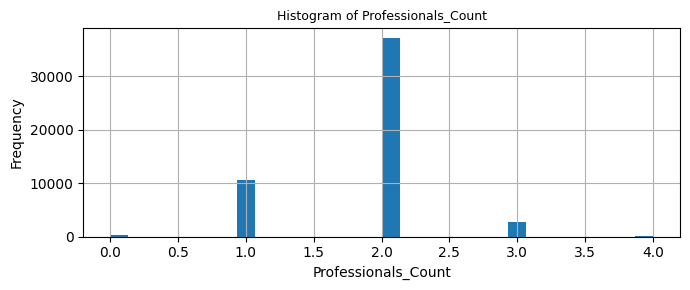

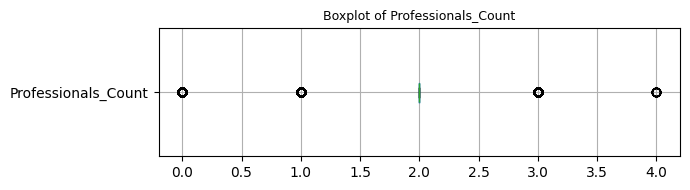

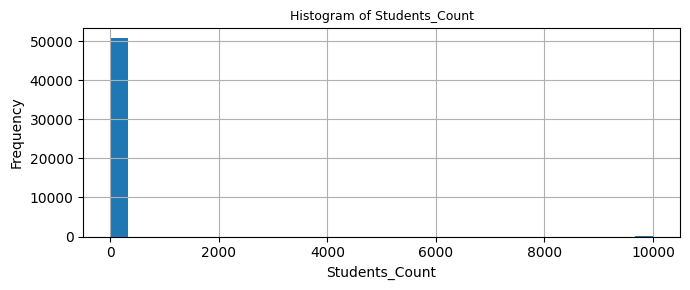

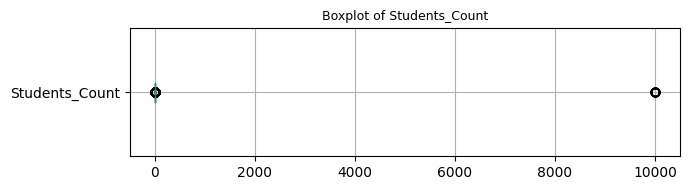

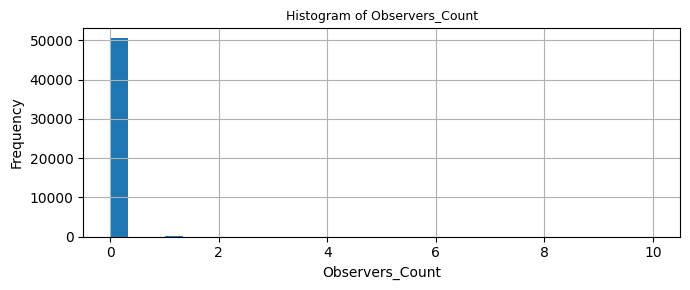

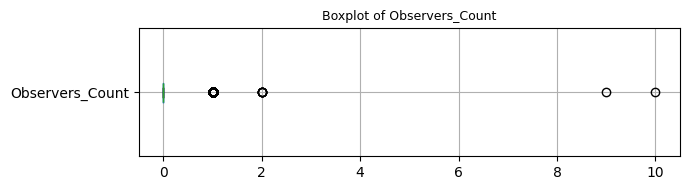

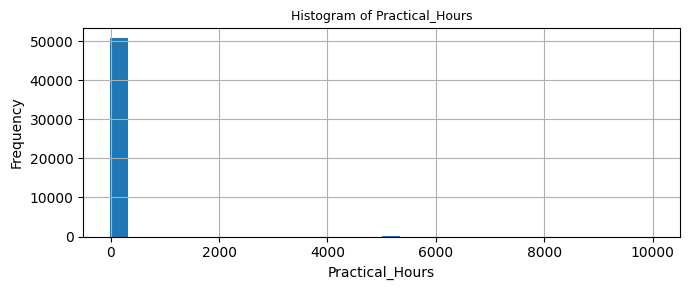

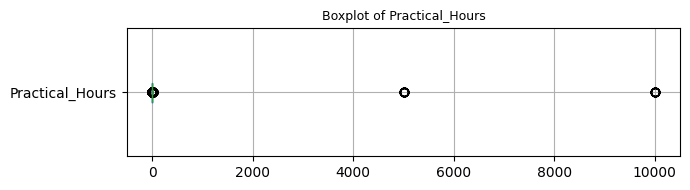

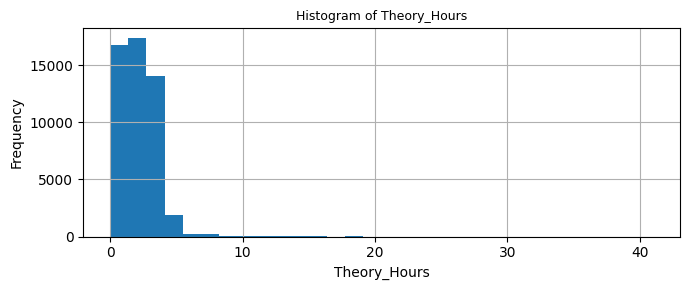

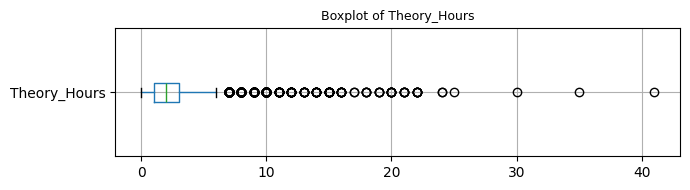

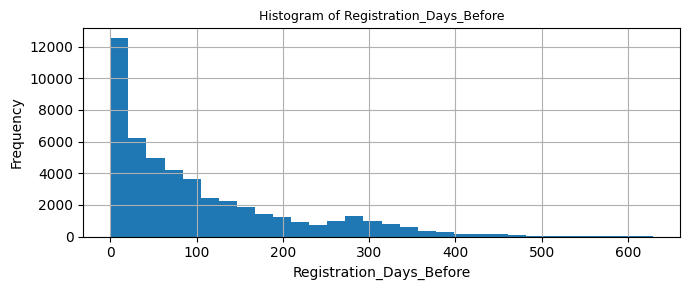

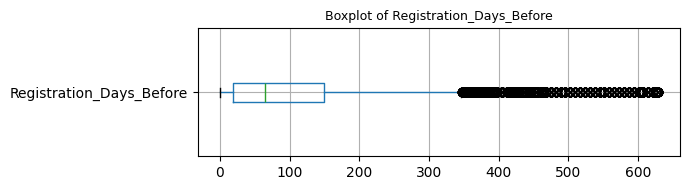

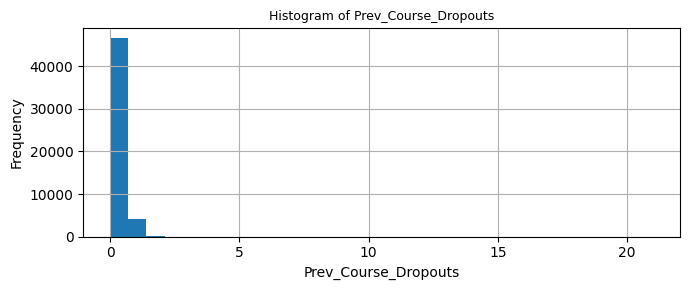

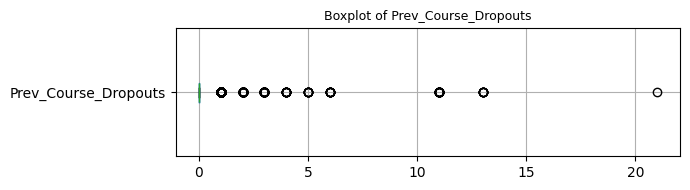

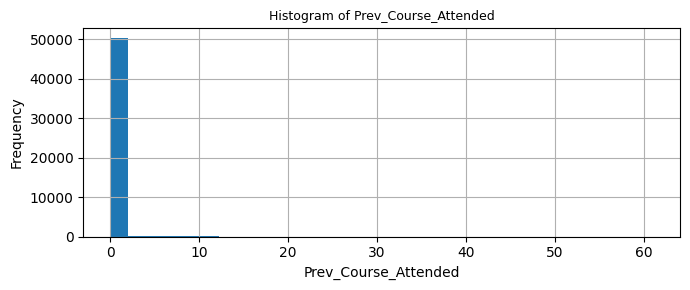

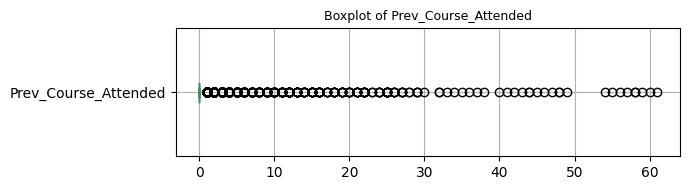

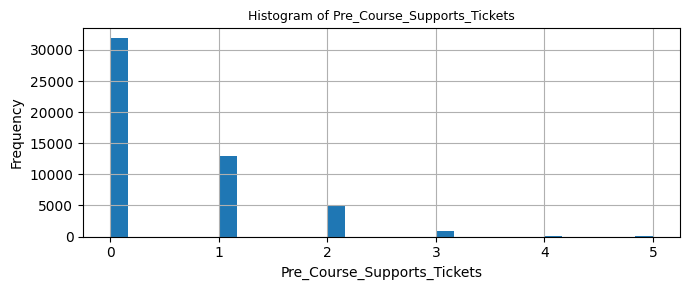

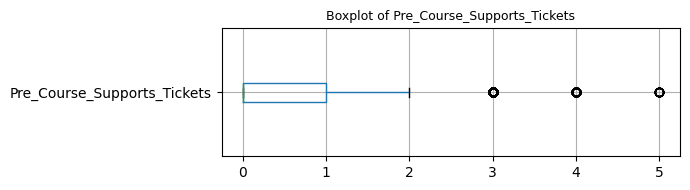

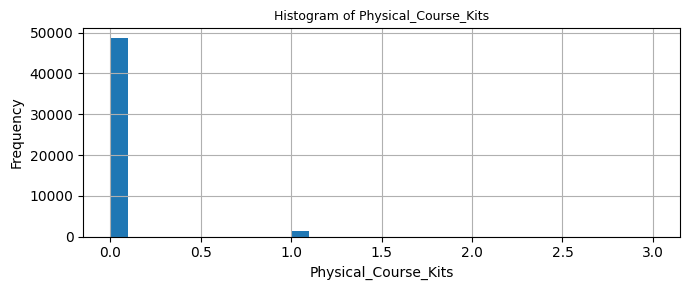

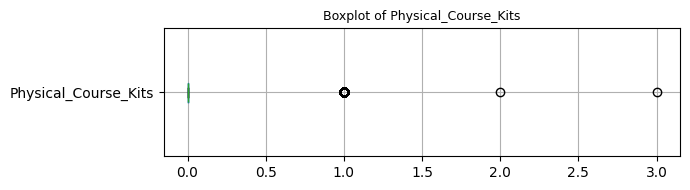

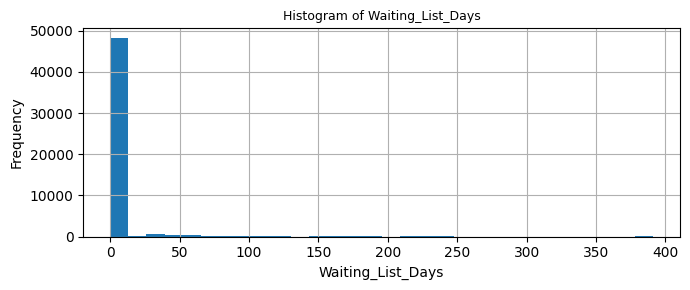

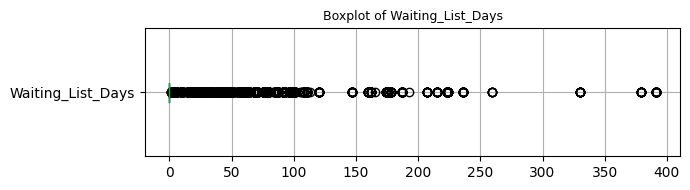

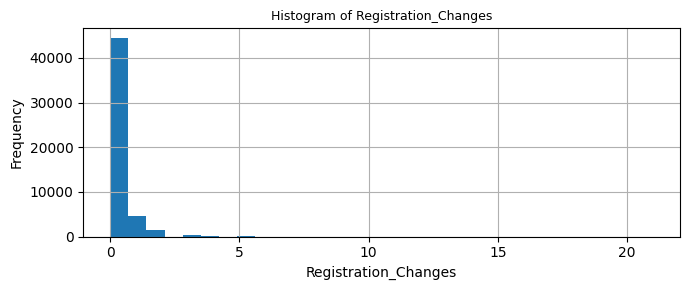

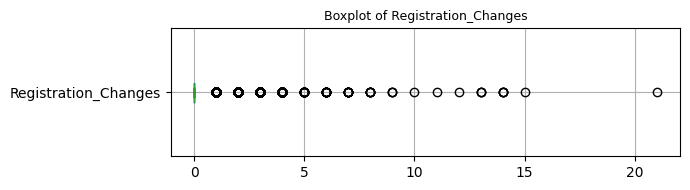

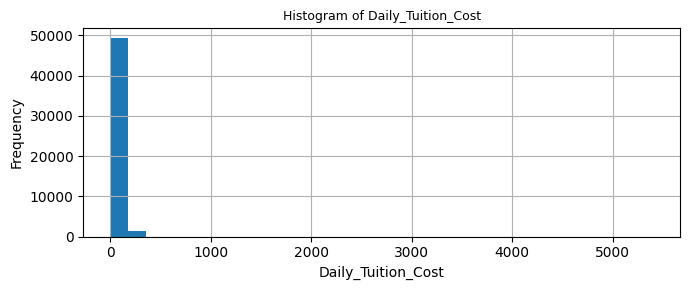

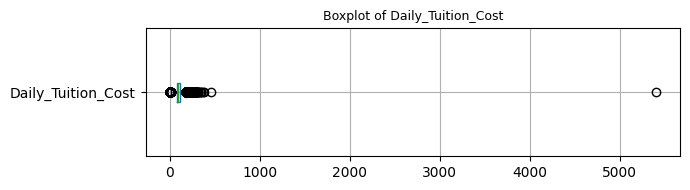

In [259]:
# Histograms and boxplots for numeric outlier analysis
# These plots are used to visually inspect skewness, sparsity, and extreme values.

for col in numeric_outlier_cols:

    plt.figure(figsize=(7, 3))
    X_train[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 2))
    X_train.boxplot(column=col, vert=False)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### Numeric Outlier Analysis Conclusions

The numeric outlier analysis shows that not all extreme values should be handled in the same way. Some values are statistically unusual but still business-plausible, while others are clearly invalid from a business perspective and likely represent data-entry or system errors.

1. **Professionals_Count**  
Although the boxplot marks several values as outliers, this is a discrete count feature with a small valid range of observed values.  
The values between 0 and 4 are business-plausible and do not appear to represent data errors.  
Therefore, no outlier treatment is applied to this feature.

2. **Students_Count**  
This is a highly sparse count feature, with approximately 94% of observations equal to zero.  
The value `9,999` is clearly invalid as a student count and is not business-plausible.  
Therefore, invalid values in this feature will be handled using conservative validity thresholds in the preprocessing pipeline. Values outside the valid range will be replaced with missing values and later imputed.  
In addition, because the feature is highly sparse, it will be converted into a binary indicator representing whether students were present.

3. **Observers_Count**  
This is an extremely sparse count feature, with approximately 99.5% of observations equal to zero.  
The observed non-zero values are rare, but they still represent a valid business event: the presence of observers.  
No invalid outlier treatment is applied to this feature.  
Because the exact non-zero counts are rare and may be unstable, the feature will be converted into a binary indicator representing whether observers were present.

4. **Practical_Hours**  
This feature contains clearly invalid values, including negative values and extremely large values such as `5,000` and `10,000`.  
Course duration cannot be negative, and values in the thousands are not business-plausible for practical course hours.  
These values are therefore treated as invalid data-entry errors rather than meaningful outliers.  
Other high values that remain within a plausible business range are kept.

5. **Theory_Hours**  
This feature shows a right-skewed distribution, with most courses having a relatively low number of theory hours and a small number of courses having higher values.  
Although the boxplot marks high values as outliers, these values are still business-plausible for longer theoretical courses.  
Therefore, no outlier treatment is applied to this feature.

6. **Registration_Days_Before**  
This feature is strongly right-skewed, with most registrations occurring relatively close to the course date and a long tail of earlier registrations.  
High values may represent early enterprise bookings and are not invalid solely because they are statistically unusual.  
Therefore, no observations are removed for this feature.  
The skewed distribution and the EDA findings support applying a `log1p` transformation later in the feature-engineering process.

7. **Prev_Course_Attended and Prev_Course_Dropouts**  
These are sparse count features where most observations receive a value of zero.  
However, non-zero values carry important business information because they indicate previous interaction with the company, either through past attendance or previous cancellations.  
No invalid outlier treatment is applied to these features.  
In the feature-engineering stage, these variables will be converted into binary history indicators and combined with `Returning_Client` into a consolidated company-history representation.

8. **Pre_Course_Supports_Tickets**  
This is a discrete count feature ranging from 0 to 5.  
Values 4–5 are rare, but still business-plausible and may reflect higher pre-course engagement or support needs.  
Therefore, no outlier treatment is applied to this feature.  
The EDA showed that the main signal is the difference between zero support tickets and at least one support interaction, so this feature will be converted into a binary indicator.

9. **Physical_Course_Kits**  
This is a highly sparse count feature, with approximately 95.8% of observations equal to zero.  
The observed non-zero values represent a valid logistical requirement and are not treated as invalid outliers.  
Because the exact non-zero count is rare and may be unstable, this feature will be converted into a binary indicator representing whether physical kits were required.

10. **Waiting_List_Days**  
This feature is highly sparse and right-skewed.  
Positive waiting-list values are rare, and very high values may be valid but unstable.  
Therefore, no values are removed as invalid based only on this analysis.  
Based on the EDA findings, the feature will later be capped to reduce the influence of extreme waiting-list durations while preserving the waiting-list signal.

11. **Registration_Changes**  
This feature is a discrete count feature with a strong right-skew, where most clients made few or no changes while a small number had many changes.  
High values are rare but business-plausible and may indicate unstable or complex registration behavior, so no outlier treatment was applied.  
We will consider using a ⁠ log1p ⁠ transformation later on.

12. **Daily_Tuition_Cost**  
This feature is right-skewed, but most observations are concentrated in a much lower cost range.  
The value `5,400` is extremely isolated from the rest of the distribution, with the next highest value being much lower.  
This value is treated as an invalid extreme value rather than a valid business outlier.  
Instead of removing the entire observation, invalid values in this feature will be replaced with missing values and later imputed during preprocessing.

Overall, statistical outliers are not removed automatically. Only clearly business-implausible values are treated as invalid. Sparse and skewed features that are business-plausible are retained and transformed later in this Part B feature-engineering process.

## Invalid Numeric Value Handling

Following the numeric outlier analysis, several values were identified as clearly invalid from a business perspective rather than merely statistically unusual.

Instead of removing entire observations, invalid numeric values will be replaced with missing values and later imputed inside the preprocessing pipeline.

The validity rules are defined using conservative, feature-specific thresholds based on the training split and business plausibility. This allows the same cleaning logic to be applied consistently to the training, validation, and external test sets.

Importantly, invalid-value handling will be applied before later feature-engineering transformations. This ensures that invalid extreme values are not mistakenly converted into valid binary indicators or transformed numeric values.

At this stage, the original `X_train` is not modified. The selected rules are documented below and will be implemented later inside the custom preprocessing transformer.

In [260]:
# Candidate numeric features for validity-threshold analysis
candidate_validity_cols = [
    "Students_Count",
    "Practical_Hours",
    "Daily_Tuition_Cost"
]

# Quantile summary for each candidate feature
validity_quantiles = (
    X_train[candidate_validity_cols]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
            0.995,
            0.999
        ]
    )
    .T
)

validity_quantiles

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,99.5%,99.9%,max
Students_Count,50767.0,8.553824,290.882083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0000,2.0,3.00000,9999.0
Practical_Hours,50771.0,6.785941,220.691243,-5.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,3.0000,4.0,8.23000,10000.0
Daily_Tuition_Cost,50706.0,98.872264,43.109057,0.0,0.0,60.0,75.0,94.5,117.0,144.0,166.5,208.9965,226.5,268.05015,5400.0


In [261]:
# Inspect smallest and largest values for each candidate feature

for col in candidate_validity_cols:

    print(f"\n===== {col} =====")

    non_missing_values = X_train[col].dropna()

    print("\nSmallest values:")
    display(
        non_missing_values
        .sort_values(ascending=True)
        .head(15)
        .to_frame(name=col)
    )

    print("\nLargest values:")
    display(
        non_missing_values
        .sort_values(ascending=False)
        .head(20)
        .to_frame(name=col)
    )


===== Students_Count =====

Smallest values:


,Students_Count
8022,0.0
21163,0.0
13768,0.0
33388,0.0
32232,0.0
30085,0.0
26849,0.0
44937,0.0
25641,0.0
46789,0.0



Largest values:


,Students_Count
5043,9999.0
51431,9999.0
24995,9999.0
11295,9999.0
12820,9999.0
20892,9999.0
61936,9999.0
20121,9999.0
17904,9999.0
56363,9999.0



===== Practical_Hours =====

Smallest values:


,Practical_Hours
31250,-5
35219,-5
18319,-5
19827,-5
61970,-5
28838,-5
55007,-5
54820,-5
14101,-5
56646,-5



Largest values:


,Practical_Hours
46492,10000
52118,10000
40359,10000
19415,10000
22492,10000
44099,10000
54310,10000
62958,10000
55164,10000
27665,10000



===== Daily_Tuition_Cost =====

Smallest values:


,Daily_Tuition_Cost
18610,0.0
16096,0.0
1388,0.0
55654,0.0
55932,0.0
45948,0.0
13986,0.0
12822,0.0
37346,0.0
54442,0.0



Largest values:


,Daily_Tuition_Cost
19884,5400.00
51813,451.50
51746,375.50
34094,365.00
51578,349.63
38818,345.00
27937,332.57
36156,316.00
51739,314.10
61443,312.50


In [262]:
# Inspect largest unique values and gaps between them

for col in candidate_validity_cols:

    print(f"\n===== {col} - Largest Unique Values =====")

    unique_values = (
        pd.Series(X_train[col].dropna().unique())
        .sort_values(ascending=True)
        .reset_index(drop=True)
    )

    largest_unique_values = unique_values.tail(20).to_frame(name=col)

    largest_unique_values["gap_from_previous"] = (
        largest_unique_values[col]
        .diff()
    )

    display(largest_unique_values)


===== Students_Count - Largest Unique Values =====


,Students_Count,gap_from_previous
0,0.0,NaN
1,1.0,1.0
2,2.0,1.0
3,3.0,1.0
4,9999.0,9996.0



===== Practical_Hours - Largest Unique Values =====


,Practical_Hours,gap_from_previous
0,-5,NaN
1,-1,4.0
2,0,1.0
3,1,1.0
4,2,1.0
5,3,1.0
6,4,1.0
7,5,1.0
8,6,1.0
9,7,1.0



===== Daily_Tuition_Cost - Largest Unique Values =====


,Daily_Tuition_Cost,gap_from_previous
4294,286.20,NaN
4295,287.00,0.80
4296,289.00,2.00
4297,290.00,1.00
4298,294.35,4.35
4299,295.00,0.65
4300,299.33,4.33
4301,300.00,0.67
4302,306.00,6.00
4303,309.50,3.50


### Numeric Validity Threshold Decision

Based on the threshold-selection analysis, we identified isolated values that are clearly separated from the ordinary observed ranges and are not business-plausible.

For `Students_Count`, the ordinary observed values are between 0 and 3, followed by an isolated value of `9,999`. Since `9,999` is not plausible as a student count, it is treated as an invalid data-entry value. A conservative upper threshold of 100 is used so that possible future values slightly above the observed range are not incorrectly treated as invalid.

For `Practical_Hours`, negative values such as `-5` and `-1` are invalid because course duration cannot be negative. In addition, the ordinary observed positive values are far below the isolated extreme values of `5,000` and `10,000`. Therefore, values below 0 or above 100 are treated as invalid.

For `Daily_Tuition_Cost`, the highest ordinary observed value is much lower than the isolated value of `5,400`. Since `5,400` is inconsistent with the rest of the distribution, values above 1,000 are treated as invalid.

These thresholds are intentionally conservative. They are designed to capture clearly invalid data-entry errors, not ordinary statistical outliers.

In [263]:
# ============================================================
# Handling Invalid Numeric Values with Missing Values
# ============================================================

NUMERIC_VALIDITY_RULES = {
    "Students_Count": {
        "min_value": 0,
        "max_value": 100
    },
    "Practical_Hours": {
        "min_value": 0,
        "max_value": 100
    },
    "Daily_Tuition_Cost": {
        "min_value": 0,
        "max_value": 1000
    }
}

numeric_validity_rules_table = (
    pd.DataFrame(NUMERIC_VALIDITY_RULES)
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)


invalid_rule_summary = []

for col, rules in NUMERIC_VALIDITY_RULES.items():

    invalid_mask = pd.Series(False, index=X_train.index)

    if "min_value" in rules:
        invalid_mask |= X_train[col] < rules["min_value"]

    if "max_value" in rules:
        invalid_mask |= X_train[col] > rules["max_value"]

    invalid_rule_summary.append({
        "feature": col,
        "min_value": rules.get("min_value"),
        "max_value": rules.get("max_value"),
        "invalid_rows": invalid_mask.sum(),
        "invalid_percentage": invalid_mask.mean() * 100
    })

invalid_rule_summary = pd.DataFrame(invalid_rule_summary)

print("summary of rules applied:\n")
print(numeric_validity_rules_table)
print('\n\n')
print('effect on X.train:\n')
print(invalid_rule_summary)

summary of rules applied:

              feature  min_value  max_value
0      Students_Count          0        100
1     Practical_Hours          0        100
2  Daily_Tuition_Cost          0       1000



effect on X.train:

              feature  min_value  max_value  invalid_rows  invalid_percentage
0      Students_Count          0        100            43            0.084694
1     Practical_Hours          0        100            94            0.185145
2  Daily_Tuition_Cost          0       1000             1            0.001970


In [264]:
# Inspect invalid values captured by the selected validity rules

for col, rules in NUMERIC_VALIDITY_RULES.items():

    invalid_mask = pd.Series(False, index=X_train.index)

    if "min_value" in rules:
        invalid_mask |= X_train[col] < rules["min_value"]

    if "max_value" in rules:
        invalid_mask |= X_train[col] > rules["max_value"]

    print(f"\n--- Invalid values detected for {col} ---")

    display(
        X_train.loc[invalid_mask, col]
        .value_counts()
        .sort_index()
        .to_frame(name="count")
    )


--- Invalid values detected for Students_Count ---


,count
Students_Count,
9999.0,43



--- Invalid values detected for Practical_Hours ---


,count
Practical_Hours,
-5,21
-1,31
5000,23
10000,19



--- Invalid values detected for Daily_Tuition_Cost ---


,count
Daily_Tuition_Cost,
5400.0,1


The selected validity rules affect only a small number of observations in the training split. This supports the interpretation that these values are isolated data-quality issues rather than meaningful extreme business cases.

Invalid values are not removed together with their full observations. Instead, only the invalid feature values will be replaced with missing values and later imputed.

These rules will be applied inside the custom preprocessing transformer before feature-engineering transformations. This order is important because invalid values should not be converted into binary indicators or transformed numeric values.

The original `X_train` remains unchanged in this section.

## Mathematical Transformation Logic

Before implementing the feature-engineering steps, we define the main mathematical transformations that will be used later in the preprocessing pipeline.

These transformations are motivated by the EDA findings and are designed to preserve the main predictive signal while reducing sparsity, skewness, extreme-value influence, and unnecessary dimensionality.

#### 1. Invalid-value replacement

Clearly invalid numeric values are not removed together with the full observation. Instead, only the invalid feature value is replaced with a missing value:

\
x_{new} =
\begin{cases}
NaN & x < L \text{ or } x > U \\
x & L \leq x \leq U
\end{cases}


where \(L\) and \(U\) are conservative lower and upper validity thresholds defined for each relevant feature.

This is applied to clearly invalid values in `Students_Count`, `Practical_Hours`, and `Daily_Tuition_Cost`.

#### 2. Binary indicators

Several feature-engineering decisions use binary indicators. The mathematical form is similar, but the motivation differs across feature groups.

The general binary-indicator logic is:


x_{new} =
\begin{cases}
1 & x > 0 \\
0 & x = 0
\end{cases}


For highly sparse count features, such as `Students_Count`, `Observers_Count`, and `Physical_Course_Kits`, the exact positive count is rare and may be unstable. Therefore, the binary indicator preserves whether the event occurred while reducing sparsity and instability.

For client-history features, such as `Prev_Course_Attended` and `Prev_Course_Dropouts`, the binary indicator captures whether the client has any previous interaction with the company. In this case, the goal is not only sparsity reduction, but also creating a clearer business interpretation of previous attendance and previous dropout history.

For `Pre_Course_Supports_Tickets`, the EDA showed that the main target-related signal is the difference between observations with zero support tickets and observations with at least one pre-course support interaction. Therefore, this feature is converted into a binary indicator even though the motivation is primarily its relationship with the target rather than sparsity alone.

Missing values are not automatically interpreted as zero. When binary indicators are created inside the preprocessing transformer, missing values are preserved and later handled by the appropriate imputation step.


This logic is used for features such as `Students_Count`, `Observers_Count`, `Physical_Course_Kits`, `Pre_Course_Supports_Tickets`, `Prev_Course_Attended`, and `Prev_Course_Dropouts`.

#### 3. Consolidated client-history indicator

The EDA showed that `Returning_Client` does not fully capture previous client interaction with the company. Some observations are marked as non-returning clients even though they have previous course attendance or previous course dropout history.

Therefore, after creating binary indicators for previous attendance and previous dropout history, we create a consolidated company-history indicator:

\[
Has\_Any\_Company\_History =
max{Returning\_Client, Had\_Previous\_Attendance, Had\_Previous\_Dropout}
\]

where:

\[
Had\_Previous\_Attendance = (Prev\_Course\_Attended > 0)
\]

\[
Had\_Previous\_Dropout = (Prev\_Course\_Dropouts > 0)
\]

This feature captures whether the client has any known previous interaction with the company, either through the original `Returning_Client` flag, previous attendance, or previous dropout history.

The purpose of this transformation is to create a more reliable and interpretable history-related feature than relying on `Returning_Client` alone. Therefore, the original `Returning_Client` feature will be removed

#### 4. Lab-configuration interaction feature

Some transformations combine two existing variables into a single derived feature that captures their relationship.

Based on the EDA, the relationship between `Requested_Lab_Config` and `Assigned_Lab_Config` is more informative than using the two variables only as independent categorical features. Therefore, we define a compact interaction feature:

\
Lab\_Config\_Match =
\begin{cases}
match & Requested\_Lab\_Config = Assigned\_Lab\_Config \\
mismatch & Requested\_Lab\_Config \neq Assigned\_Lab\_Config \\
missing & Requested\_Lab\_Config \text{ or } Assigned\_Lab\_Config \text{ is missing}
\end{cases}


This transformation preserves the main interaction identified in the EDA while reducing categorical dimensionality before one-hot encoding.

After creating `Lab_Config_Match`, the original `Requested_Lab_Config` and `Assigned_Lab_Config` columns are removed from the modeling pipeline.

#### 5. Binary company-ID availability indicator

Since `Company_ID` is mostly missing and identifier-like, the raw ID value is not used directly. Instead, we create a binary indicator for whether a company identifier is available:

\
Has\_Company\_ID =
\begin{cases}
1 & Company\_ID \text{ is not missing} \\
0 & Company\_ID \text{ is missing}
\end{cases}


This preserves the information contained in the availability of the identifier without treating the raw ID as a numeric feature.

#### 6. Log transformation for skewed numeric features

For strongly right-skewed numeric variables, a `log1p` transformation can reduce the influence of large values while preserving the order of observations:


x_{new} = log(1 + x)


The \(+1\) allows the transformation to be applied when \(x = 0\).

This transformation is used for `Registration_Days_Before`. It will also be evaluated for `Registration_Changes`.

#### 7. Capping extreme valid values

For features with rare but potentially valid extreme values, capping is used instead of removal:

\[
x_{new} = min(x, C)
\]

where \(C\) is a cap value learned from the training split.

For `Waiting_List_Days`, \(C\) is defined as the 95th percentile of positive waiting-list values in the training split. This reduces the influence of very large waiting-list durations while preserving the signal that the group spent time on the waiting list.

#### 8. Rare-category grouping

For high-cardinality categorical features, rare categories are grouped into an `"other"` category in order to reduce dimensionality and avoid unstable one-hot encoded columns.

\
category_{new} =
\begin{cases}
category & count(category) \geq T \\
other & count(category) < T
\end{cases}


where \(T\) is a minimum-frequency threshold learned from the training split.

This logic is applied to high-cardinality features such as `Origin_Country` and `Agent_ID`.

#### 9. Date feature extraction

The raw `Course_Start_Date` column is not used directly. Instead, selected date components are extracted:

\[
Course\_Start\_Month = month(Course\_Start\_Date)
\]

\[
Course\_Start\_DayOfWeek = weekday(Course\_Start\_Date)
\]

These features preserve useful seasonal and weekly timing patterns while converting the raw date into model-friendly numeric/categorical information.

------------------

Overall, these transformations are designed to keep the business signal identified in the EDA while reducing noise, sparsity, skewness, and unnecessary dimensionality.


## Identifier Features

Some columns in the dataset are identifier-like variables. These columns should not be treated as ordinary numeric predictors, even if they are stored as numeric values.

Using raw identifiers directly can create artificial numeric relationships, increase dimensionality, and lead to overfitting. Therefore, each identifier-like feature is handled according to its business meaning and EDA findings.

In [265]:
# Identifier-like feature summary

identifier_cols = ["Client_ID", "Company_ID", "Agent_ID"]

identifier_summary = []

for col in identifier_cols:
    identifier_summary.append({
        "feature": col,
        "dtype": X_train[col].dtype,
        "missing_count": X_train[col].isna().sum(),
        "missing_percentage": X_train[col].isna().mean() * 100,
        "n_unique": X_train[col].nunique(dropna=True),
        "sample_values": list(X_train[col].dropna().unique()[:5])
    })

identifier_summary = pd.DataFrame(identifier_summary)
identifier_summary

,feature,dtype,missing_count,missing_percentage,n_unique,sample_values
0,Client_ID,int64,0,0.000000,50771,"[72948, 9052, 6421, 78979, 55408]"
1,Company_ID,float64,48295,95.123200,169,"[5057.0, 5018.0, 5181.0, 5009.0, 5078.0]"
2,Agent_ID,float64,8928,17.584842,196,"[218.0, 158.0, 144.0, 184.0, 300.0]"


In [266]:
# Cancellation rate by Company_ID availability

company_id_availability_summary = (
    pd.DataFrame({
        "Has_Company_ID": X_train["Company_ID"].notna().astype(int),
        "Dropped_Course": y_train
    })
    .groupby("Has_Company_ID")
    .agg(
        count=("Dropped_Course", "size"),
        cancellation_rate=("Dropped_Course", "mean")
    )
    .reset_index()
)

company_id_availability_summary

,Has_Company_ID,count,cancellation_rate
0,0,48295,0.424682
1,1,2476,0.213651


### Identifier Feature Decisions

`Client_ID` is a technical identifier of the observation/client and does not have a meaningful numeric interpretation.  
It will therefore be removed from the model features. The column may still be kept separately for the final submission file if required, but it will not be used for model training.

`Company_ID` is also an identifier-like feature and should not be used directly as a numeric variable. In addition, the EDA showed that it is missing for the vast majority of observations.  
However, the missing-value analysis showed that the availability of `Company_ID` is related to the target. Therefore, instead of using the raw identifier, we create a binary indicator:


Has\_Company\_ID =
\begin{cases}
1 & Company\_ID \text{ is available} \\
0 & Company\_ID \text{ is missing}
\end{cases}


The raw `Company_ID` column will then be dropped.

`Agent_ID` is numeric-looking, but it represents the agent associated with the registration process rather than a continuous numeric quantity.  
Therefore, it should not be scaled or interpreted as an ordinal numeric feature. It will be treated as a categorical identifier. Missing values will be handled using an `"unknown_agent"` category, and rare agents will be grouped later in the high-cardinality categorical handling section.

No changes are applied directly to `X_train` in this section. These decisions will be implemented later inside the custom feature-engineering transformer.

In [267]:
# Identifier-related feature-engineering decisions

IDENTIFIER_COLUMNS_TO_DROP = ["Client_ID", "Company_ID"]
COMPANY_ID_INDICATOR = "Has_Company_ID"

## Requested vs Assigned Lab Configuration Interaction

Based on the EDA in Part A, the interaction between `Requested_Lab_Config` and `Assigned_Lab_Config` contains useful predictive information.

The analysis showed that the derived `Lab_Config_Match` feature has a strong relationship with the target and provides a more compact representation than keeping both original lab-configuration columns separately.

Therefore, the final feature-engineering decision is to create `Lab_Config_Match` and remove the original `Requested_Lab_Config` and `Assigned_Lab_Config` columns from the modeling pipeline.

This transformation preserves the main interaction identified in the EDA while reducing categorical dimensionality before one-hot encoding.

The mathematical definition of `Lab_Config_Match` was provided in the general feature-transformation logic section above. The actual transformation is implemented later inside the custom feature-engineering transformer. The original `X_train` is not modified directly in this section.

## Date Feature Engineering

Based on the EDA in Part A, `Course_Start_Date` contains useful temporal information, but the raw date itself is not suitable as a direct model feature.

The EDA showed that cancellation probability varies across temporal patterns such as course month and day of week. Therefore, the raw date column will be transformed into two derived features:

- `Course_Start_Month`
- `Course_Start_DayOfWeek`

The original `Course_Start_Date` column will then be removed from the modeling pipeline.

We do not extract more granular date components, such as exact day of month, because they may create unnecessary noise and dimensionality without a clear EDA-based justification.

This transformation is implemented later inside the custom feature-engineering transformer. The original `X_train` is not modified directly in this section.

## Numeric Transformations and Capping

Based on the numeric EDA in Part A, several numeric variables require transformation because their raw distributions are skewed, sparse, or dominated by rare extreme values.

This section documents three numeric feature-engineering decisions:

1. applying a `log1p` transformation to `Registration_Days_Before`
2. capping extreme positive values in `Waiting_List_Days`
3. converting `Registration_Changes` into a binary indicator after evaluating a `log1p` representation

The original `X_train` is not modified directly in this section. These transformations are implemented later inside the custom feature-engineering transformer.

### Log Transformation Analysis

Before selecting the final representation for skewed registration-related features, we compare the original distributions with their `log1p` transformations.

This analysis is used to decide whether a log-transformed representation is appropriate, or whether a binary representation better captures the useful signal.

In [268]:
# ============================================================
# 32. Log Transformation Analysis
# ============================================================

log_check_features = [
    "Registration_Days_Before",
    "Registration_Changes"
]

log_check = X_train[log_check_features].copy()

for col in log_check_features:

    log_check[col + "_Log"] = np.log1p(
        log_check[col]
    )

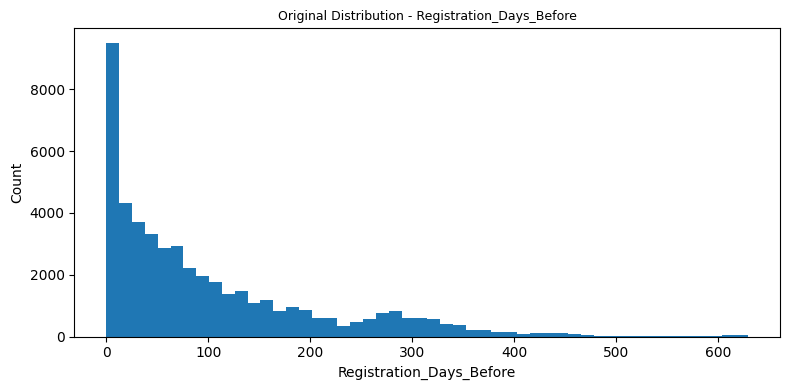

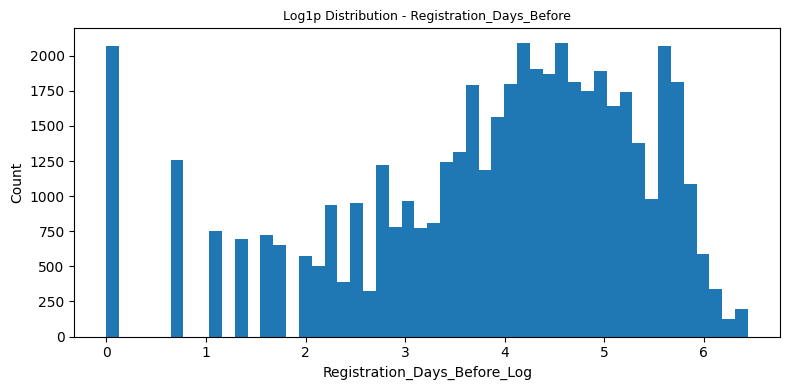

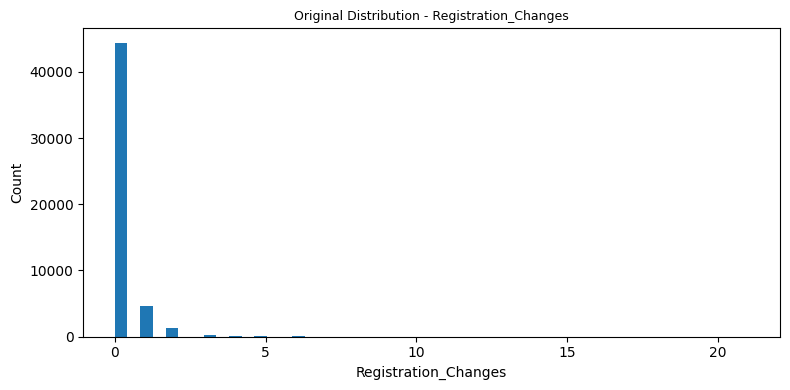

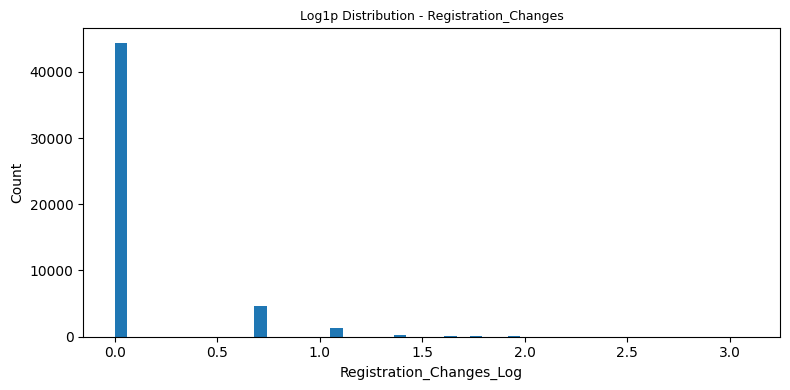

In [269]:
for col in log_check_features:

    log_col = col + "_Log"

    plt.figure(figsize=(8, 4))

    plt.hist(
        log_check[col].dropna(),
        bins=50
    )

    plt.title(
        f"Original Distribution - {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))

    plt.hist(
        log_check[log_col].dropna(),
        bins=50
    )

    plt.title(
        f"Log1p Distribution - {col}"
    )

    plt.xlabel(log_col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

In [270]:
for col in log_check_features:

    log_col = col + "_Log"

    print(f"\n--- {col} ---")

    print("Original:")

    print(
        log_check[col]
        .describe(
            percentiles=[
                0.5,
                0.75,
                0.9,
                0.95,
                0.99
            ]
        )
    )

    print("\nLog1p:")

    print(
        log_check[log_col]
        .describe(
            percentiles=[
                0.5,
                0.75,
                0.9,
                0.95,
                0.99
            ]
        )
    )


--- Registration_Days_Before ---
Original:
count    48645.000000
mean       103.203721
std        109.548377
min          0.000000
50%         65.000000
75%        150.000000
90%        277.000000
95%        326.000000
99%        447.000000
max        629.000000
Name: Registration_Days_Before, dtype: float64

Log1p:
count    48645.000000
mean         3.866574
std          1.539838
min          0.000000
50%          4.189655
75%          5.017280
90%          5.627621
95%          5.789960
99%          6.104793
max          6.445720
Name: Registration_Days_Before_Log, dtype: float64

--- Registration_Changes ---
Original:
count    50771.000000
mean         0.179965
std          0.586646
min          0.000000
50%          0.000000
75%          0.000000
90%          1.000000
95%          1.000000
99%          2.000000
max         21.000000
Name: Registration_Changes, dtype: float64

Log1p:
count    50771.000000
mean         0.106120
std          0.295352
min          0.000000
50%        

In [271]:
for col in log_check_features:

    log_col = col + "_Log"

    print(f"\n--- {col} ---")

    print(
        "Original skew:",
        log_check[col].skew()
    )

    print(
        "Log1p skew:",
        log_check[log_col].skew()
    )


--- Registration_Days_Before ---
Original skew: 1.4951453808938475
Log1p skew: -0.8481805863728743

--- Registration_Changes ---
Original skew: 6.9023078729042755
Log1p skew: 2.8958076643853503



The log-transformation analysis shows different behavior for the two registration-related features.

For `Registration_Days_Before`, applying `log1p` substantially reduces the effect of large values and produces a more balanced numeric representation while preserving the ordering of observations. Therefore, `Registration_Days_Before` will be log-transformed.

For `Registration_Changes`, applying `log1p` reduces skewness but the feature remains highly zero-inflated. Most observations still contain no registration changes, and the main useful signal is whether any change occurred at all. Therefore, the final representation for `Registration_Changes` will be binary rather than log-transformed.

#### Registration_Days_Before

The EDA showed that `Registration_Days_Before` is one of the strongest numeric predictors and has a clear non-linear relationship with the target.

The feature is strongly right-skewed: most registrations occur relatively close to the course date, while a smaller number of observations represent much earlier registrations. These high values are business-plausible and should not be treated as invalid outliers.

To reduce skewness while preserving the ordering of observations, the preprocessing pipeline applies a `log1p` transformation to `Registration_Days_Before`.

Missing values are preserved during this transformation and will be handled later by the numeric imputer.

#### Registration_Changes

`Registration_Changes` is a discrete count feature with a highly zero-inflated distribution.

A `log1p` transformation was evaluated as a possible way to reduce skewness. Although the transformation reduced the skewness, the feature remained dominated by zero values, and most observations still had no registration changes.

Therefore, the final feature-engineering decision is to represent this variable as a binary indicator: `Had_Registration_Changes`.

This indicator captures whether any registration change occurred, rather than relying on the exact number of changes.

The original `Registration_Changes` column is removed after the binary indicator is created.

### Capping Analysis

#### Waiting_List_Days

`Waiting_List_Days` is a sparse and right-skewed numeric feature. Most observations have a value of zero, while positive waiting-list durations are relatively rare.

High positive values may still be valid, so they are not treated as invalid outliers. However, very large waiting-list durations may have disproportionate influence on the model.

Therefore, the final feature-engineering decision is to cap `Waiting_List_Days` at the 95th percentile of positive waiting-list values, calculated only from the training split.

This keeps the waiting-list signal while reducing the influence of extreme positive values.

In [272]:
# Waiting_List_Days capping decision for documentation

waiting_cap_percentile = 0.95

positive_waiting_days = X_train.loc[
    X_train["Waiting_List_Days"] > 0,
    "Waiting_List_Days"
]

waiting_days_cap = positive_waiting_days.quantile(
    waiting_cap_percentile
)

print("95th percentile cap among positive waiting days:", waiting_days_cap)
print("Rows above cap in X_train:", (positive_waiting_days > waiting_days_cap).sum())

95th percentile cap among positive waiting days: 223.0
Rows above cap in X_train: 102


The 95th percentile among positive waiting-list values is 223 days. Only a small number of training observations are above this cap.

This supports using capping rather than removal: the feature remains informative, zero values are preserved, and only extreme positive waiting durations are limited.

The cap value will be learned inside the custom feature-engineering transformer using the training split only, and then applied consistently to the validation and external test sets.

## Sparse and Count-Based Binary Feature Engineering

Several count-based features are highly sparse or contain rare exact positive values.

For these variables, the EDA showed that the main useful signal is whether the event occurred, rather than the exact number of occurrences. Therefore, selected count features are converted into binary indicators.

The selected transformations are:

- `Students_Count` → `Has_Students`
- `Observers_Count` → `Has_Observers`
- `Physical_Course_Kits` → `Has_Physical_Kits`
- `Pre_Course_Supports_Tickets` → `Has_Pre_Course_Support_Tickets`

For `Students_Count`, invalid numeric values are handled before this transformation, so invalid extreme values are not converted into valid positive indicators.

For `Pre_Course_Supports_Tickets`, the motivation is not only sparsity. The EDA showed that the main target-related signal is the difference between observations with zero support tickets and observations with at least one pre-course support interaction.

After the binary indicators are created, the original count columns are removed from the modeling pipeline.

Missing values are not automatically interpreted as zero. If a value is missing, the corresponding binary indicator remains missing and is handled later by the numeric imputer.

In [273]:
# ============================================================
# Sparse and count-based binary feature decisions
# ============================================================

# Mapping of selected count features to their binary indicator names.
# These constants will be used later inside the custom preprocessing transformer.

SPARSE_COUNT_BINARY_MAPPING = {
    "Students_Count": "Has_Students",
    "Observers_Count": "Has_Observers",
    "Physical_Course_Kits": "Has_Physical_Kits",
    "Pre_Course_Supports_Tickets": "Has_Pre_Course_Support_Tickets"
}

SPARSE_COUNT_FEATURES_TO_DROP = list(SPARSE_COUNT_BINARY_MAPPING.keys())

SPARSE_COUNT_BINARY_MAPPING

{'Students_Count': 'Has_Students',
 'Observers_Count': 'Has_Observers',
 'Physical_Course_Kits': 'Has_Physical_Kits',
 'Pre_Course_Supports_Tickets': 'Has_Pre_Course_Support_Tickets'}

## Client History Feature Engineering

The client-history variables describe previous interactions between the client and the company.

The relevant original features are:

- `Returning_Client`
- `Prev_Course_Attended`
- `Prev_Course_Dropouts`

The EDA showed that previous client interaction is informative, but the original variables represent overlapping and partly incomplete views of the same business concept.

`Prev_Course_Attended` and `Prev_Course_Dropouts` are count-based features. For these variables, the exact count is less important than whether the client has any previous attendance or dropout history.

Therefore, the preprocessing pipeline will first convert the previous-history count variables into binary indicators:

- `Prev_Course_Attended` → `Had_Previous_Attendance`
- `Prev_Course_Dropouts` → `Had_Previous_Dropout`

Then, these indicators will be combined with `Returning_Client` into a consolidated history feature: `Has_Any_Company_History`.

This feature captures whether the client has any known previous interaction with the company, either through the original returning-client flag, previous attendance, or previous dropout history.

After the new history features are created, the original history-related columns are removed from the modeling pipeline.

The original `X_train` is not modified directly in this section. These transformations are implemented inside the custom feature-engineering transformer.

In [274]:
# ============================================================
# Client history feature-engineering decisions
# ============================================================

# Previous course count features will be converted into binary indicators.
HISTORY_BINARY_MAPPING = {
    "Prev_Course_Attended": "Had_Previous_Attendance",
    "Prev_Course_Dropouts": "Had_Previous_Dropout"
}

# Consolidated client-history feature.
COMPANY_HISTORY_FEATURE = "Has_Any_Company_History"

# Original history-related columns to remove after creating the new features.
HISTORY_FEATURES_TO_DROP = [
    "Returning_Client",
    "Prev_Course_Attended",
    "Prev_Course_Dropouts"
]

HISTORY_FEATURES_TO_DROP

['Returning_Client', 'Prev_Course_Attended', 'Prev_Course_Dropouts']

In [275]:
client_history_decision_table = pd.DataFrame({
    "original_feature": [
        "Prev_Course_Attended",
        "Prev_Course_Dropouts",
        "Returning_Client + Had_Previous_Attendance + Had_Previous_Dropout"
    ],
    "engineered_feature": [
        "Had_Previous_Attendance",
        "Had_Previous_Dropout",
        "Has_Any_Company_History"
    ],
    "decision": [
        "Convert count to binary indicator",
        "Convert count to binary indicator",
        "Create consolidated company-history indicator"
    ]
})

client_history_decision_table

,original_feature,engineered_feature,decision
0,Prev_Course_Attended,Had_Previous_Attendance,Convert count to binary indicator
1,Prev_Course_Dropouts,Had_Previous_Dropout,Convert count to binary indicator
2,Returning_Client + Had_Previous_Attendance + H...,Has_Any_Company_History,Create consolidated company-history indicator


## High-Cardinality Categorical Handling

Some categorical features contain a large number of unique values and a long tail of rare categories.

In this dataset, the main high-cardinality categorical features are:

- `Origin_Country`
- `Agent_ID`

Although `Agent_ID` is stored as a numeric-looking variable, it represents an identifier of the agent associated with the registration process. Therefore, it is treated as a categorical feature rather than as a continuous numeric predictor.

Using high-cardinality categorical variables directly with one-hot encoding may create many sparse columns, increase dimensionality, and make the model more sensitive to rare categories that appear only a small number of times.

To reduce this risk, rare categories are grouped into broader `"other"` categories. The grouping thresholds are learned only from the training split and then applied consistently to the validation and external test sets.

This section documents the high-cardinality handling decisions for `Origin_Country` and `Agent_ID`. The transformations are implemented later inside the custom feature-engineering transformer, and the original `X_train` is not modified directly in this section.

#### Origin_Country

The EDA showed that `Origin_Country` is a high-cardinality categorical feature with a long tail of rare countries.

Some countries appear frequently enough to provide a stable signal, while many countries appear only a small number of times. Keeping all countries as separate categories would increase the number of one-hot encoded columns and may create unstable features based on very few observations.

Therefore, rare countries are grouped into a single `"other_country"` category.

A country is kept as its own category only if it appears at least 100 times in the training split. Otherwise, it is grouped into `"other_country"`.

This threshold is learned only from the training split inside the custom feature-engineering transformer and then applied consistently to the validation and external test sets.


In [276]:
# Origin_Country rare-category grouping decision for documentation

min_country_count = 100

origin_country_source = (
    X_train_categorical_eda
    if "X_train_categorical_eda" in globals()
    else X_train
)

origin_country_clean = (
    origin_country_source["Origin_Country"]
    .astype("string")
    .str.strip()
    .str.lower()
)

origin_country_clean = origin_country_clean.replace("", np.nan)

origin_country_counts = (
    origin_country_clean
    .value_counts(dropna=False)
    .reset_index()
)

origin_country_counts.columns = ["Origin_Country", "count"]

origin_country_counts["grouping_decision"] = np.where(
    origin_country_counts["count"] >= min_country_count,
    "kept_as_original_country",
    "grouped_into_other_country"
)

origin_country_grouping_summary = (
    origin_country_counts
    .groupby("grouping_decision")
    .agg(
        n_categories=("Origin_Country", "count"),
        n_rows=("count", "sum")
    )
    .reset_index()
)

origin_country_grouping_summary["percentage_of_training_data"] = (
    origin_country_grouping_summary["n_rows"] / len(X_train) * 100
)

origin_country_grouping_summary

,grouping_decision,n_categories,n_rows,percentage_of_training_data
0,grouped_into_other_country,117,1679,3.307006
1,kept_as_original_country,31,49092,96.692994


In [277]:
origin_country_counts.sort_values("count", ascending=False).head(20)

,Origin_Country,count,grouping_decision
0,prt,21098,kept_as_original_country
1,fra,5581,kept_as_original_country
2,deu,3496,kept_as_original_country
3,esp,3129,kept_as_original_country
4,gbr,2803,kept_as_original_country
5,ita,2184,kept_as_original_country
6,bra,1118,kept_as_original_country
7,bel,1087,kept_as_original_country
8,nld,1009,kept_as_original_country
9,usa,854,kept_as_original_country


The grouping summary shows that only countries with sufficient representation in the training data are kept as separate categories.

Rare countries are grouped into `"other_country"` in order to reduce dimensionality and avoid unstable one-hot encoded columns.

The grouping rule is not applied directly to `X_train` in this section. It is implemented later inside the custom feature-engineering transformer.

### Agent_ID

`Agent_ID` is a numeric-looking feature, but it represents the identifier of the agent associated with the registration process. Therefore, it should not be treated as a continuous numeric variable.

The EDA showed that `Agent_ID` is a high-cardinality categorical feature with many unique values and a long tail of rare agents.

Keeping every agent as a separate one-hot encoded category may increase dimensionality and create unstable columns for agents that appear only a small number of times.

Therefore, `Agent_ID` is treated as a categorical feature. Missing agent values are handled as `"unknown_agent"`, and rare agents are grouped into `"other_agent"`.

An agent is kept as its own category only if it appears at least 100 times in the training split. Otherwise, it is grouped into `"other_agent"`.

This grouping threshold is learned only from the training split inside the custom feature-engineering transformer and then applied consistently to the validation and external test sets.

In [278]:
# Agent_ID rare-category grouping decision for documentation

min_agent_count = 100

agent_id_clean = (
    X_train["Agent_ID"]
    .astype("string")
    .str.strip()
    .str.lower()
)

agent_id_clean = agent_id_clean.replace("", np.nan)
agent_id_clean = agent_id_clean.fillna("unknown_agent")

agent_id_counts = (
    agent_id_clean
    .value_counts(dropna=False)
    .reset_index()
)

agent_id_counts.columns = ["Agent_ID", "count"]

agent_id_counts["grouping_decision"] = np.where(
    agent_id_counts["count"] >= min_agent_count,
    "kept_as_original_agent",
    "grouped_into_other_agent"
)

agent_id_grouping_summary = (
    agent_id_counts
    .groupby("grouping_decision")
    .agg(
        n_categories=("Agent_ID", "count"),
        n_rows=("count", "sum")
    )
    .reset_index()
)

agent_id_grouping_summary["percentage_of_training_data"] = (
    agent_id_grouping_summary["n_rows"] / len(X_train) * 100
)

agent_id_grouping_summary

,grouping_decision,n_categories,n_rows,percentage_of_training_data
0,grouped_into_other_agent,157,2731,5.379055
1,kept_as_original_agent,40,48040,94.620945


In [279]:
agent_id_counts.sort_values("count", ascending=False).head(20)

,Agent_ID,count,grouping_decision
0,184.0,17644,kept_as_original_agent
1,unknown_agent,8928,kept_as_original_agent
2,218.0,5263,kept_as_original_agent
3,104.0,2087,kept_as_original_agent
4,264.0,1895,kept_as_original_agent
5,219.0,1584,kept_as_original_agent
6,224.0,1040,kept_as_original_agent
7,205.0,874,kept_as_original_agent
8,320.0,814,kept_as_original_agent
9,158.0,705,kept_as_original_agent


The grouping summary shows that only agents with sufficient representation in the training data are kept as separate categories.

Rare agents are grouped into `"other_agent"` in order to reduce dimensionality and avoid unstable one-hot encoded columns.

The missing-agent category `"unknown_agent"` is preserved as a meaningful category rather than being treated as a numeric value.

The grouping rule is not applied directly to `X_train` in this section. It is implemented later inside the custom feature-engineering transformer.

## Categorical Missing and Unknown Handling

The missing-value analysis in Part A showed that some categorical missing values represent unavailable information rather than random noise.

Therefore, categorical missing values are not imputed using the most frequent category. Replacing missing values with the most common category could hide the fact that the information was unavailable and may remove useful signal.

For selected categorical features, missing values are handled explicitly inside the custom feature-engineering transformer:

- Missing `Agent_ID` values are represented as `"unknown_agent"`.
- Missing `Submission_Source` values are represented as `"unknown"`.
- Missing `Payment_Terms` values are represented as `"unknown"`.

Any remaining categorical missing values are handled later in the categorical preprocessing pipeline using a constant `"unknown"` value before one-hot encoding.

The original `X_train` is not modified directly in this section.

## Dimensionality Control

Several feature-engineering decisions in this part are designed to reduce unnecessary dimensionality and avoid unstable sparse features.

This is especially important because categorical variables are later encoded using one-hot encoding. If high-cardinality categorical variables are used directly, the preprocessing pipeline may create many sparse columns, some of which are based on very few observations.

The main dimensionality-control decisions are:

| Feature group | Dimensionality issue | Decision |
|---|---|---|
| `Client_ID` | Technical identifier with no meaningful numeric interpretation. | Drop from model features. |
| `Company_ID` | Mostly missing and identifier-like. | Replace with `Has_Company_ID` and drop the raw identifier. |
| `Requested_Lab_Config` + `Assigned_Lab_Config` | Two related categorical variables create redundant one-hot encoded columns. | Replace with the compact interaction feature `Lab_Config_Match`. |
| `Origin_Country` | High-cardinality categorical feature with many rare countries. | Keep only countries with sufficient training representation and group rare countries as `"other_country"`. |
| `Agent_ID` | Numeric-looking high-cardinality identifier. | Treat as categorical, preserve missing values as `"unknown_agent"`, and group rare agents as `"other_agent"`. |
| Sparse count features | Exact positive counts are rare and may create unstable numeric signals. | Convert selected count features into binary indicators and drop the original count columns. |
| Client-history features | Several overlapping variables describe previous company interaction. | Create binary history indicators and a consolidated `Has_Any_Company_History` feature. |
| `Course_Start_Date` | Raw dates can create excessive granularity. | Extract only `Course_Start_Month` and `Course_Start_DayOfWeek`, then drop the raw date. |

Together, these decisions reduce the number of sparse or redundant features before model training.

The goal is not to remove useful information, but to represent it in a more stable and compact way. This helps reduce the risk of overfitting and improves the ability of the model to generalize to validation and external test data.

The one-hot encoding step is applied only after these dimensionality-control transformations are completed.

In [280]:
dimensionality_control_summary = pd.DataFrame({
    "feature_group": [
        "Client_ID",
        "Company_ID",
        "Requested_Lab_Config + Assigned_Lab_Config",
        "Origin_Country",
        "Agent_ID",
        "Sparse count features",
        "Client-history features",
        "Course_Start_Date"
    ],
    "decision": [
        "Drop raw identifier",
        "Create Has_Company_ID and drop raw identifier",
        "Create Lab_Config_Match and drop original columns",
        "Group rare countries into other_country",
        "Group rare agents into other_agent",
        "Convert selected counts into binary indicators",
        "Create consolidated Has_Any_Company_History",
        "Extract month and day-of-week, then drop raw date"
    ]
})

dimensionality_control_summary

,feature_group,decision
0,Client_ID,Drop raw identifier
1,Company_ID,Create Has_Company_ID and drop raw identifier
2,Requested_Lab_Config + Assigned_Lab_Config,Create Lab_Config_Match and drop original columns
3,Origin_Country,Group rare countries into other_country
4,Agent_ID,Group rare agents into other_agent
5,Sparse count features,Convert selected counts into binary indicators
6,Client-history features,Create consolidated Has_Any_Company_History
7,Course_Start_Date,"Extract month and day-of-week, then drop raw date"


## Final Feature Engineering Decision Summary

Based on the EDA, missing-value analysis, numeric outlier analysis, and business interpretation of the dataset, the following preprocessing and feature-engineering decisions were selected for the modeling pipeline.

This table summarizes the final transformations that will be implemented inside the custom feature-engineering transformer and preprocessing pipeline.

| Feature group / feature | Final decision | Reasoning |
|---|---|---|
| Invalid numeric values | Replace invalid values with missing values using the validity rules defined above. | Clearly business-implausible values should not influence the model, but the full observations should not be removed. |
| `Client_ID` | Drop from model features. | Technical identifier with no meaningful predictive interpretation and no ability to generalize. |
| `Company_ID` | Create `Has_Company_ID`, then drop raw `Company_ID`. | Raw identifier is mostly missing and not meaningful as a numeric feature, but its availability is related to the target. |
| `Agent_ID` | Treat as categorical, fill missing values as `"unknown_agent"`, and group rare agents as `"other_agent"`. | Numeric-looking identifier with high cardinality and informative missingness. |
| `Origin_Country` | Group countries with fewer than 100 observations into `"other_country"`. | Reduces dimensionality and avoids unstable one-hot columns for rare countries. |
| `Requested_Lab_Config` + `Assigned_Lab_Config` | Create `Lab_Config_Match`, then drop the two original columns. | The interaction captures the main relationship identified in the EDA while reducing categorical dimensionality. |
| `Course_Start_Date` | Extract `Course_Start_Month` and `Course_Start_DayOfWeek`, then drop the raw date. | Preserves useful temporal patterns while avoiding overly granular raw date values. |
| `Registration_Days_Before` | Apply `log1p` transformation. | Reduces right skew while preserving observation order. |
| `Registration_Changes` | Create `Had_Registration_Changes`, then drop the original count feature. | `log1p` was evaluated, but the feature remained zero-inflated; the main signal is whether any change occurred. |
| `Waiting_List_Days` | Cap positive values at the 95th percentile learned from the training split. | Preserves the waiting-list signal while reducing the influence of extreme positive values. |
| `Students_Count` | Create `Has_Students`, then drop the original count feature. | Highly sparse count feature; invalid values are handled before binary transformation. |
| `Observers_Count` | Create `Has_Observers`, then drop the original count feature. | Exact positive counts are rare; the main signal is whether observers were present. |
| `Physical_Course_Kits` | Create `Has_Physical_Kits`, then drop the original count feature. | Sparse logistical count; binary representation is more stable. |
| `Pre_Course_Supports_Tickets` | Create `Has_Pre_Course_Support_Tickets`, then drop the original count feature. | EDA showed the main signal is whether more than one support interaction occurred. |
| `Prev_Course_Attended` | Create `Had_Previous_Attendance`. | Previous attendance is better represented as an indicator of history rather than an exact count. |
| `Prev_Course_Dropouts` | Create `Had_Previous_Dropout`. | Previous dropout history is informative; binary representation is more stable. |
| `Returning_Client`, `Prev_Course_Attended`, `Prev_Course_Dropouts` | Create `Has_Any_Company_History`, then drop original history columns. | Combines overlapping history-related signals into a clearer consolidated feature. |
| `Submission_Source` | Fill missing values as `"unknown"`. | Missing/unavailable source information may carry meaning and should not be replaced with the most frequent category. |
| `Payment_Terms` | Fill missing values as `"unknown"`. | Missing and unknown-like payment information are treated consistently. |
| Other categorical missing values | Impute with constant `"unknown"` before one-hot encoding. | Preserves unavailable-information signal instead of hiding it using most-frequent imputation. |
| Categorical text values | Apply standard text cleaning before encoding. | Ensures consistent category representation by lowercasing, trimming spaces, removing selected special characters, and converting empty strings to missing values. |
| Categorical encoding | Apply one-hot encoding with unknown-category handling. | Converts categorical variables into model-compatible features while safely handling unseen categories. |
| Numeric missing values | Impute using median values learned from the training data. | Robust to skewed numeric distributions and consistent across train, validation, and test. |
| Numeric scaling | Apply `StandardScaler` after numeric imputation. | Standardizes numeric features for models that are sensitive to scale. |

All transformations that require fitting, such as rare-category grouping and capping thresholds, are learned only from the training split. The fitted transformation logic is then applied consistently to the validation and external test sets.

The original `X_train` is not modified directly during this section. All transformations are implemented inside the custom feature-engineering transformer and preprocessing pipeline in order to avoid data leakage and ensure reproducibility.

## Custom Feature Engineering Transformer

In [281]:
# ============================================================
# Custom Feature Engineering Transformer
# ============================================================


class CustomFeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        min_country_count=100,
        min_agent_count=100,
        waiting_cap_percentile=0.95
    ):
        self.min_country_count = min_country_count
        self.min_agent_count = min_agent_count
        self.waiting_cap_percentile = waiting_cap_percentile

    @staticmethod
    def _clean_text_series(series):
        cleaned = (
            series
            .astype("string")
            .str.strip()
            .str.lower()
            .str.replace("?", "", regex=False)
            .str.replace(r"\s+", " ", regex=True)
            .str.replace("*", "", regex=False)
            .str.replace("#", "", regex=False)
            .str.replace(")", "", regex=False)
            .str.replace("(", "", regex=False)
            .str.replace("!", "", regex=False)
        )

        cleaned = cleaned.replace("", pd.NA)
        cleaned = cleaned.astype("object")
        cleaned = cleaned.where(pd.notna(cleaned), np.nan)

        return cleaned

    def fit(self, X, y=None):
        X = X.copy()

        # ----------------------------------------------------
        # Learn common Origin_Country categories from train only
        # ----------------------------------------------------
        if "Origin_Country" in X.columns:
            country_clean = self._clean_text_series(X["Origin_Country"])

            country_counts = country_clean.value_counts(dropna=False)

            self.common_countries_ = country_counts[
                country_counts >= self.min_country_count
            ].index
        else:
            self.common_countries_ = pd.Index([])

        # ----------------------------------------------------
        # Learn common Agent_ID categories from train only
        # ----------------------------------------------------
        if "Agent_ID" in X.columns:
            agent_clean = self._clean_text_series(X["Agent_ID"])
            agent_clean = agent_clean.fillna("unknown_agent")

            agent_counts = agent_clean.value_counts(dropna=False)

            self.common_agents_ = agent_counts[
                agent_counts >= self.min_agent_count
            ].index
        else:
            self.common_agents_ = pd.Index([])

        # ----------------------------------------------------
        # Learn Waiting_List_Days cap from positive train values only
        # ----------------------------------------------------
        if "Waiting_List_Days" in X.columns:

            waiting_values = pd.to_numeric(
                X["Waiting_List_Days"],
                errors="coerce"
            )

            positive_waiting_mask = (
                waiting_values > 0
            ).fillna(False)

            positive_waiting_days = waiting_values.loc[
                positive_waiting_mask
            ]

            self.waiting_days_cap_ = positive_waiting_days.quantile(
                self.waiting_cap_percentile
            )
        else:
            self.waiting_days_cap_ = np.nan

        return self

    def transform(self, X):
        X = X.copy()

        # ----------------------------------------------------
        # Invalid numeric values
        # ----------------------------------------------------
        for col, rules in NUMERIC_VALIDITY_RULES.items():
            if col in X.columns:

                numeric_col = pd.to_numeric(
                    X[col],
                    errors="coerce"
                )

                invalid_mask = pd.Series(False, index=X.index)

                if "min_value" in rules:
                    below_min = (
                        numeric_col < rules["min_value"]
                    ).fillna(False)

                    invalid_mask = invalid_mask | below_min

                if "max_value" in rules:
                    above_max = (
                        numeric_col > rules["max_value"]
                    ).fillna(False)

                    invalid_mask = invalid_mask | above_max

                X.loc[invalid_mask, col] = np.nan

        # ----------------------------------------------------
        # Identifier features
        # ----------------------------------------------------
        if "Company_ID" in X.columns:
            X[COMPANY_ID_INDICATOR] = X["Company_ID"].notna().astype(int)

        X = X.drop(
            columns=IDENTIFIER_COLUMNS_TO_DROP,
            errors="ignore"
        )

        # Treat Agent_ID as categorical rather than numeric
        if "Agent_ID" in X.columns:
            X["Agent_ID"] = X["Agent_ID"].astype("object")

        # ----------------------------------------------------
        # Categorical text cleaning
        # ----------------------------------------------------
        categorical_cols = X.select_dtypes(
            include=["object", "string"]
        ).columns

        for col in categorical_cols:
            X[col] = self._clean_text_series(X[col])

        # ----------------------------------------------------
        # Lab configuration interaction
        # ----------------------------------------------------
        if (
            "Requested_Lab_Config" in X.columns
            and "Assigned_Lab_Config" in X.columns
        ):

            missing_lab_config = (
                X["Requested_Lab_Config"].isna()
                | X["Assigned_Lab_Config"].isna()
            )

            configs_match = (
                X["Requested_Lab_Config"]
                .eq(X["Assigned_Lab_Config"])
                .fillna(False)
            )

            X["Lab_Config_Match"] = "mismatch"

            X.loc[
                configs_match & ~missing_lab_config,
                "Lab_Config_Match"
            ] = "match"

            X.loc[
                missing_lab_config,
                "Lab_Config_Match"
            ] = "missing"

            X = X.drop(
                columns=[
                    "Requested_Lab_Config",
                    "Assigned_Lab_Config"
                ],
                errors="ignore"
            )

        # ----------------------------------------------------
        # Meaningful categorical unknown values
        # ----------------------------------------------------
        if "Agent_ID" in X.columns:
            X["Agent_ID"] = X["Agent_ID"].fillna("unknown_agent")

        if "Submission_Source" in X.columns:
            X["Submission_Source"] = X["Submission_Source"].fillna("unknown")

        if "Payment_Terms" in X.columns:
            X["Payment_Terms"] = X["Payment_Terms"].fillna("unknown")

        # ----------------------------------------------------
        # Course_Start_Date features
        # ----------------------------------------------------
        if "Course_Start_Date" in X.columns:

            X["Course_Start_Date"] = pd.to_datetime(
                X["Course_Start_Date"],
                errors="coerce"
            )

            X["Course_Start_DayOfWeek"] = (
                X["Course_Start_Date"].dt.dayofweek
            )

            X["Course_Start_Month"] = (
                X["Course_Start_Date"].dt.month
            )

            X = X.drop(
                columns=["Course_Start_Date"],
                errors="ignore"
            )

        # ----------------------------------------------------
        # Rare Origin_Country grouping
        # ----------------------------------------------------
        if "Origin_Country" in X.columns:

            origin_country_missing = X["Origin_Country"].isna()

            country_is_common = (
                X["Origin_Country"]
                .isin(self.common_countries_)
                .fillna(False)
            )

            X["Origin_Country"] = np.where(
                origin_country_missing,
                np.nan,
                np.where(
                    country_is_common,
                    X["Origin_Country"],
                    "other_country"
                )
            )

        # ----------------------------------------------------
        # Rare Agent_ID grouping
        # ----------------------------------------------------
        if "Agent_ID" in X.columns:

            agent_is_common = (
                X["Agent_ID"]
                .isin(self.common_agents_)
                .fillna(False)
            )

            agent_is_unknown = (
                X["Agent_ID"]
                .eq("unknown_agent")
                .fillna(False)
            )

            agent_keep_mask = agent_is_common | agent_is_unknown

            X["Agent_ID"] = X["Agent_ID"].where(
                agent_keep_mask,
                "other_agent"
            )

        # ----------------------------------------------------
        # Sparse and count-based binary indicators
        # ----------------------------------------------------
        for original_col, new_col in SPARSE_COUNT_BINARY_MAPPING.items():

            if original_col in X.columns:

                numeric_col = pd.to_numeric(
                    X[original_col],
                    errors="coerce"
                )

                positive_value = (
                    numeric_col > 0
                ).fillna(False)

                X[new_col] = np.where(
                    numeric_col.isna(),
                    np.nan,
                    positive_value.astype(int)
                )

        X = X.drop(
            columns=SPARSE_COUNT_FEATURES_TO_DROP,
            errors="ignore"
        )

        # ----------------------------------------------------
        # Client history features
        # ----------------------------------------------------
        for original_col, new_col in HISTORY_BINARY_MAPPING.items():

            if original_col in X.columns:

                numeric_col = pd.to_numeric(
                    X[original_col],
                    errors="coerce"
                )

                positive_history_value = (
                    numeric_col > 0
                ).fillna(False)

                X[new_col] = np.where(
                    numeric_col.isna(),
                    np.nan,
                    positive_history_value.astype(int)
                )

        history_component_cols = []

        if "Returning_Client" in X.columns:
            history_component_cols.append("Returning_Client")

        for new_col in HISTORY_BINARY_MAPPING.values():
            if new_col in X.columns:
                history_component_cols.append(new_col)

        if history_component_cols:

            history_components = X[history_component_cols].copy()

            has_positive_history = (
                history_components
                .eq(1)
                .fillna(False)
                .any(axis=1)
            )

            has_missing_history = (
                history_components
                .isna()
                .any(axis=1)
            )

            X[COMPANY_HISTORY_FEATURE] = np.where(
                has_positive_history,
                1,
                np.where(
                    has_missing_history,
                    np.nan,
                    0
                )
            )

        X = X.drop(
            columns=HISTORY_FEATURES_TO_DROP,
            errors="ignore"
        )

        # ----------------------------------------------------
        # Registration features
        # ----------------------------------------------------
        if "Registration_Days_Before" in X.columns:

            registration_days = pd.to_numeric(
                X["Registration_Days_Before"],
                errors="coerce"
            )

            X["Registration_Days_Before"] = np.log1p(
                registration_days
            )

        if "Registration_Changes" in X.columns:

            registration_changes = pd.to_numeric(
                X["Registration_Changes"],
                errors="coerce"
            )

            had_registration_changes = (
                registration_changes > 0
            ).fillna(False)

            X["Had_Registration_Changes"] = np.where(
                registration_changes.isna(),
                np.nan,
                had_registration_changes.astype(int)
            )

            X = X.drop(
                columns=["Registration_Changes"],
                errors="ignore"
            )

        # ----------------------------------------------------
        # Waiting_List_Days capping
        # ----------------------------------------------------
        if (
            "Waiting_List_Days" in X.columns
            and not pd.isna(self.waiting_days_cap_)
        ):

            waiting_values = pd.to_numeric(
                X["Waiting_List_Days"],
                errors="coerce"
            )

            X["Waiting_List_Days"] = waiting_values.clip(
                upper=self.waiting_days_cap_
            )

        # Final compatibility cleanup
        X = X.replace({pd.NA: np.nan})

        return X

The custom feature-engineering transformer implements all feature-engineering decisions documented above.

Transformations that require fitting, such as rare-category grouping and the waiting-list cap, are learned only from the training split. Rule-based transformations, such as binary indicators, identifier handling, date extraction, and lab-configuration matching, are applied consistently during transformation.

The transformer does not remove observations. It only modifies, creates, or removes feature columns according to the decisions described in Part B.

## Preprocessing Pipeline

After defining the custom feature-engineering transformer, we build the preprocessing pipeline used before model training.

The preprocessing pipeline has two main stages:

1. `CustomFeatureEngineer` applies all feature-engineering decisions defined in Part B.
2. `ColumnTransformer` applies numeric and categorical preprocessing.

Numeric features are imputed using the median and then standardized using `StandardScaler`.

Categorical features are imputed using a constant `"unknown"` value and then encoded using one-hot encoding. Unknown categories that appear in validation or external test data are ignored safely by the encoder.

The numeric and categorical feature lists are identified after applying the custom feature-engineering transformer, because several original columns are removed and several new features are created.

In [282]:
# ============================================================
# Build Preprocessing Pipeline
# ============================================================

feature_engineer = CustomFeatureEngineer(
    min_country_count=100,
    min_agent_count=100,
    waiting_cap_percentile=0.95
)

# First, apply feature engineering temporarily only to identify
# the final numeric and categorical columns.
X_train_fe_preview = feature_engineer.fit_transform(X_train)

numeric_features = (
    X_train_fe_preview
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

categorical_features = (
    X_train_fe_preview
    .select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

print("Number of numeric features:", len(numeric_features))
print(numeric_features)

print("\nNumber of categorical features:", len(categorical_features))
print(categorical_features)

Number of numeric features: 17
['Professionals_Count', 'Practical_Hours', 'Theory_Hours', 'Registration_Days_Before', 'Waiting_List_Days', 'Daily_Tuition_Cost', 'Has_Company_ID', 'Course_Start_DayOfWeek', 'Course_Start_Month', 'Has_Students', 'Has_Observers', 'Has_Physical_Kits', 'Has_Pre_Course_Support_Tickets', 'Had_Previous_Attendance', 'Had_Previous_Dropout', 'Has_Any_Company_History', 'Had_Registration_Changes']

Number of categorical features: 10
['Origin_Country', 'Catering_Package', 'Welcome_Gift_Type', 'Enrollment_Type', 'Lanyard_Color', 'Client_Category', 'Submission_Source', 'Agent_ID', 'Payment_Terms', 'Lab_Config_Match']


In [283]:
# Numeric preprocessing:
# median imputation + scaling

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical preprocessing:
# constant missing-value imputation + one-hot encoding

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [284]:
# ============================================================
# Full Preprocessing Pipeline Without Model
# ============================================================

preprocessing_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineer),
    ("preprocessor", preprocessor)
])

In [285]:
# ============================================================
# Test Pipeline on Training and Validation Data
# ============================================================

X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_val_processed = preprocessing_pipeline.transform(X_val)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_val shape:", X_val_processed.shape)

Processed X_train shape: (50771, 130)
Processed X_val shape: (12693, 130)


In [286]:
# ============================================================
# Get Processed Feature Names
# ============================================================

num_feature_names = numeric_features

cat_feature_names = (
    preprocessing_pipeline
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

processed_feature_names = (
    list(num_feature_names)
    + list(cat_feature_names)
)

print("Total processed features:", len(processed_feature_names))
processed_feature_names

Total processed features: 130


['Professionals_Count',
 'Practical_Hours',
 'Theory_Hours',
 'Registration_Days_Before',
 'Waiting_List_Days',
 'Daily_Tuition_Cost',
 'Has_Company_ID',
 'Course_Start_DayOfWeek',
 'Course_Start_Month',
 'Has_Students',
 'Has_Observers',
 'Has_Physical_Kits',
 'Has_Pre_Course_Support_Tickets',
 'Had_Previous_Attendance',
 'Had_Previous_Dropout',
 'Has_Any_Company_History',
 'Had_Registration_Changes',
 'Origin_Country_ago',
 'Origin_Country_aus',
 'Origin_Country_aut',
 'Origin_Country_bel',
 'Origin_Country_bra',
 'Origin_Country_che',
 'Origin_Country_chn',
 'Origin_Country_cn',
 'Origin_Country_cze',
 'Origin_Country_deu',
 'Origin_Country_dnk',
 'Origin_Country_esp',
 'Origin_Country_fin',
 'Origin_Country_fra',
 'Origin_Country_gbr',
 'Origin_Country_hun',
 'Origin_Country_irl',
 'Origin_Country_isr',
 'Origin_Country_ita',
 'Origin_Country_jpn',
 'Origin_Country_lux',
 'Origin_Country_mar',
 'Origin_Country_nld',
 'Origin_Country_nor',
 'Origin_Country_other_country',
 'Origin_C

In [287]:
X_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names
)

X_processed_df.head()

,Professionals_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Waiting_List_Days,Daily_Tuition_Cost,Has_Company_ID,Course_Start_DayOfWeek,Course_Start_Month,Has_Students,Has_Observers,Has_Physical_Kits,Has_Pre_Course_Support_Tickets,Had_Previous_Attendance,Had_Previous_Dropout,Has_Any_Company_History,Had_Registration_Changes,Origin_Country_ago,Origin_Country_aus,Origin_Country_aut,Origin_Country_bel,Origin_Country_bra,Origin_Country_che,Origin_Country_chn,Origin_Country_cn,Origin_Country_cze,Origin_Country_deu,Origin_Country_dnk,Origin_Country_esp,Origin_Country_fin,Origin_Country_fra,Origin_Country_gbr,Origin_Country_hun,Origin_Country_irl,Origin_Country_isr,Origin_Country_ita,Origin_Country_jpn,Origin_Country_lux,Origin_Country_mar,Origin_Country_nld,Origin_Country_nor,Origin_Country_other_country,Origin_Country_pol,Origin_Country_prt,Origin_Country_rou,Origin_Country_rus,Origin_Country_swe,Origin_Country_tur,Origin_Country_unknown,Origin_Country_usa,Catering_Package_all inclusive,Catering_Package_lunch included,Catering_Package_no food plan,Catering_Package_standard coffee only,Catering_Package_unknown,Welcome_Gift_Type_branded notebook,Welcome_Gift_Type_portable charger,Welcome_Gift_Type_usb drive,Welcome_Gift_Type_water bottle,Enrollment_Type_affiliated admission,Enrollment_Type_contractual agreement,Enrollment_Type_general admission,Enrollment_Type_organizational arrangement,Enrollment_Type_unknown,Lanyard_Color_black,Lanyard_Color_blue,Lanyard_Color_green,Lanyard_Color_orange,Lanyard_Color_red,Client_Category_big tech & multinationals,Client_Category_defense & govtech,Client_Category_fintech & banking,Client_Category_industrial tech & iot,Client_Category_non-profit & edutech,Client_Category_saas & software houses,Client_Category_traditional it & telecomm,Client_Category_unknown,Submission_Source_b2b platforms & resellers,Submission_Source_dedicated sales team,Submission_Source_direct website registration,Submission_Source_government procurement system,Submission_Source_unknown,Agent_ID_104.0,Agent_ID_111.0,Agent_ID_118.0,Agent_ID_121.0,Agent_ID_129.0,Agent_ID_133.0,Agent_ID_138.0,Agent_ID_139.0,Agent_ID_144.0,Agent_ID_147.0,Agent_ID_158.0,Agent_ID_167.0,Agent_ID_169.0,Agent_ID_178.0,Agent_ID_184.0,Agent_ID_189.0,Agent_ID_190.0,Agent_ID_205.0,Agent_ID_217.0,Agent_ID_218.0,Agent_ID_219.0,Agent_ID_220.0,Agent_ID_222.0,Agent_ID_223.0,Agent_ID_224.0,Agent_ID_252.0,Agent_ID_258.0,Agent_ID_261.0,Agent_ID_262.0,Agent_ID_264.0,Agent_ID_277.0,Agent_ID_300.0,Agent_ID_306.0,Agent_ID_313.0,Agent_ID_314.0,Agent_ID_317.0,Agent_ID_318.0,Agent_ID_320.0,Agent_ID_321.0,Agent_ID_other_agent,Agent_ID_unknown_agent,Payment_Terms_pay upon start,Payment_Terms_prepaid non-refundable,Payment_Terms_refundable deposit,Payment_Terms_unknown,Lab_Config_Match_match,Lab_Config_Match_mismatch,Lab_Config_Match_missing
0,0.327444,0.243916,-0.792986,1.318546,-0.184844,-1.018627,-0.226425,-1.554811,1.008135,-0.251927,-0.070908,-0.163253,-0.770010,-0.142755,3.311043,2.954022,-0.37955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.327444,-0.880661,-0.112734,0.205188,-0.184844,0.449927,-0.226425,-0.513512,0.709590,-0.251927,-0.070908,-0.163253,1.298684,-0.142755,-0.302020,-0.338522,-0.37955,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

The preprocessing pipeline was successfully fitted on the training data and applied to the validation data.

Both processed datasets contain the same number of features, confirming that the feature-engineering logic and one-hot encoding are applied consistently across splits.

The final processed training set contains 130 features after numeric preprocessing, categorical encoding, and all feature-engineering transformations.

## Summary

In Part B, we translated the main findings from the exploratory data analysis into concrete feature-engineering and preprocessing decisions.

The numeric outlier analysis showed that not all extreme values should be treated in the same way. Most statistical outliers were kept when they were business-plausible, while clearly invalid values were handled using conservative validity rules. Invalid values in `Students_Count`, `Practical_Hours`, and `Daily_Tuition_Cost` were replaced with missing values inside the custom feature-engineering transformer, and are later imputed by the preprocessing pipeline.

Several feature-engineering steps were created based on the EDA findings. Identifier-like variables were handled carefully: `Client_ID` was removed, while `Company_ID` was converted into the availability indicator `Has_Company_ID` before dropping the raw identifier. `Agent_ID` was treated as a categorical feature rather than a numeric variable.

The relationship between `Requested_Lab_Config` and `Assigned_Lab_Config` was represented using the derived feature `Lab_Config_Match`. This preserves the interaction identified in the EDA while reducing the dimensionality created by one-hot encoding the two original lab-configuration columns separately.

The raw `Course_Start_Date` column was replaced with `Course_Start_Month` and `Course_Start_DayOfWeek`, preserving relevant temporal patterns while avoiding unnecessary date-level granularity.

For skewed and sparse numeric variables, different transformations were selected according to their observed behavior. `Registration_Days_Before` was transformed using `log1p` to reduce right skew. `Registration_Changes` was converted into the binary indicator `Had_Registration_Changes`, since the EDA showed that the main signal was whether any registration change occurred. `Waiting_List_Days` was capped at the 95th percentile of positive waiting-list values learned from the training split.

Highly sparse count features were converted into binary indicators. This included `Students_Count`, `Observers_Count`, `Physical_Course_Kits`, and `Pre_Course_Supports_Tickets`. The goal was to preserve the main business signal while avoiding instability caused by rare exact count values.

Client-history information was also consolidated. Binary indicators were created for previous attendance and previous dropouts, and a combined `Has_Any_Company_History` feature was created from `Returning_Client`, `Prev_Course_Attended`, and `Prev_Course_Dropouts`. The original overlapping history columns were then removed.

High-cardinality categorical variables were handled using rare-category grouping. Rare countries were grouped into `"other_country"` and rare agents into `"other_agent"`, with thresholds learned only from the training split. This reduces the number of sparse one-hot encoded columns and helps address the curse of dimensionality.

Categorical missing values were handled consistently. Selected missing values were represented as meaningful unavailable-information categories, such as `"unknown_agent"` for `Agent_ID` and `"unknown"` for `Submission_Source` and `Payment_Terms`. Remaining categorical missing values are handled using constant imputation before one-hot encoding.

All feature-engineering steps were implemented inside a custom `CustomFeatureEngineer` transformer. This ensures that the same logic is applied consistently to the training, validation, and external test sets. Transformations that require fitting, such as rare-category grouping and waiting-list capping, are learned only from the training split in order to avoid data leakage.

Finally, the preprocessing pipeline combines the custom feature-engineering transformer with numeric imputation and scaling, categorical missing-value imputation, and one-hot encoding. The processed training and validation sets contain the same number of features, confirming that the pipeline is consistent across data splits.

Overall, Part B improves the dataset by correcting invalid values, creating more informative and stable features, reducing unnecessary dimensionality, and preparing a reproducible preprocessing pipeline for the modeling stage.

# Part C - Model Training and Hyperparameter Tuning

### Goals and Modeling Strategy

The goal of Part C is to train, tune, and compare several classification models for predicting the probability that a course registration will be cancelled.

Since the project target is probabilistic and the required evaluation metric is ROC-AUC, model comparison in this section is based primarily on cross-validation ROC-AUC rather than only on accuracy or hard class predictions.

All models in this section use the same preprocessing and feature-engineering logic defined in Part B. This ensures that differences in model performance reflect the modeling approach itself, rather than inconsistent preprocessing.

The modeling strategy is based on the following steps:

1. Define a consistent modeling protocol that avoids data leakage.
2. Use cross-validation on the training split for baseline comparison.
3. Tune the hyperparameters of each candidate model using cross-validation on the training split only.
4. Compare multiple model families, including both linear and tree-based models.
5. Analyze the tuned models in terms of cross-validation performance, stability, and bias-variance / overfitting behavior.

The models considered in this section are:

- Logistic Regression
- Random Forest
- XGBoost Classifier
- HistGradientBoosting Classifier

Logistic Regression is used as an interpretable linear baseline. Random Forest and the boosting models are included because the EDA suggested that course cancellation may depend on non-linear relationships and interactions between operational, customer-related, and registration-related features.

XGBoost is included because the project instructions recommend testing a model from the XGBoost family for tabular data.

The holdout validation set is kept separate throughout Part C and is not used for baseline comparison or hyperparameter tuning. It will be used in Part D for model evaluation and final model selection.

## Data Split and Evaluation Protocol

Before Part A, the labeled training data was split into two parts:

- `X_train`, `y_train`: used for exploratory analysis, preprocessing decisions, model training, cross-validation, and hyperparameter tuning.
- `X_val`, `y_val`: held out as an internal validation set and kept separate from the training and tuning process.

This split creates an internal test-like set that can later be used in Part D to evaluate the tuned models on data that was not used for hyperparameter selection.

In Part C, all baseline comparisons and hyperparameter tuning are performed using cross-validation on `X_train` only. The holdout validation set is not used during this part.

The modeling protocol in Part C follows two stages:

1. Use cross-validation on `X_train` to compare baseline models.
2. Use cross-validation on `X_train` to tune hyperparameters for each candidate model.

The preprocessing and feature-engineering steps are included inside the model pipeline during cross-validation. This means that transformations such as rare-category grouping, waiting-list capping, imputation, scaling, and one-hot encoding are fitted only on the training folds and then applied to the corresponding validation folds.

This prevents data leakage and ensures that the cross-validation scores better reflect how the model is expected to perform on unseen data.

After Part C is completed, the tuned models will be evaluated on the holdout validation set in Part D using ROC-AUC, classification metrics, confusion matrices, and additional model interpretation tools.

After the final model is selected in Part D, it can be refitted on the full labeled training data before generating predictions for the external test set.

## Cross-Validation and Scoring Setup

In this section, we define the cross-validation strategy and scoring metric that will be used consistently for baseline comparison and hyperparameter tuning.

Since the target variable is binary and moderately imbalanced, we use stratified cross-validation in order to preserve the cancellation / non-cancellation class proportions in each fold.

The main scoring metric is ROC-AUC, because the project focuses on predicting cancellation probabilities rather than only producing hard class labels. This is also consistent with the project evaluation metric.

Cross-validation is performed only on `X_train` and `y_train`. The holdout validation set remains untouched until after hyperparameter tuning is completed.

In [288]:
# ============================================================
# Cross-Validation and Scoring Setup
# ============================================================

CV_FOLDS = 5
SCORING = "roc_auc"

cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

N_JOBS = -1

print("Cross-validation strategy:", cv_strategy)

print("Scoring metric:", SCORING)

Cross-validation strategy: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Scoring metric: roc_auc


## Full Model Pipeline Builder

In this section, we define a helper function that builds a full modeling pipeline for any candidate classifier.

Each model pipeline contains three stages:

\[
CustomFeatureEngineer \rightarrow Preprocessor \rightarrow Model
\]

The `CustomFeatureEngineer` applies the feature-engineering logic defined in Part B. The `Preprocessor` applies numeric imputation and scaling, categorical imputation, and one-hot encoding. The final step is the candidate classification model.

Using a full pipeline ensures that every model is trained and evaluated using the same preprocessing logic. It also ensures that during cross-validation, all data-dependent preprocessing steps are fitted only on the training fold and then applied to the validation fold.

In [289]:
# ============================================================
# Full Model Pipeline Builder
# ============================================================

def build_preprocessor():
    """
    Build a fresh preprocessing transformer.

    The numeric_features and categorical_features lists were identified
    after applying the custom feature-engineering transformer in Part B.
    """

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor


def build_model_pipeline(model):
    """
    Build a full sklearn pipeline:
    Custom feature engineering -> preprocessing -> model.
    """

    pipeline = Pipeline(steps=[
        (
            "feature_engineering",
            CustomFeatureEngineer(
                min_country_count=100,
                min_agent_count=100,
                waiting_cap_percentile=0.95
            )
        ),
        ("preprocessor", build_preprocessor()),
        ("model", model)
    ])

    return pipeline

In [290]:
# Sanity check: build one example pipeline
example_pipeline = build_model_pipeline(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

example_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,min_country_count,100
,min_agent_count,100
,waiting_cap_percentile,0.95
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_

## Candidate Models

In this section, we define the candidate classification models that will be compared in Part C.

The models were selected to represent different modeling approaches:

- `Logistic Regression` is used as an interpretable linear baseline.
- `Random Forest` is used as a non-linear tree-based ensemble model.
- `XGBoost Classifier` is included because gradient-boosted tree models are known to perform well on tabular datasets and are recommended in the project instructions.
- `HistGradientBoosting Classifier` is included because it is an efficient gradient-boosting model that can capture non-linear relationships and feature interactions.

At this stage, the models are only defined. Training, cross-validation, and hyperparameter tuning are performed in the following sections using full pipelines.

In [291]:
# ============================================================
# Candidate Models
# ============================================================

candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        tree_method="hist"
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

candidate_models

{'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
 'Random Forest': RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=4, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=-1,
               num_parallel_tree=None, ...),
 'HistGradientBoosting': HistGradientBoostin

In [292]:
# Build full pipelines for all candidate models
candidate_pipelines = {
    model_name: build_model_pipeline(model)
    for model_name, model in candidate_models.items()
}

candidate_pipelines.keys()

dict_keys(['Logistic Regression', 'Random Forest', 'XGBoost', 'HistGradientBoosting'])

### Baseline Cross-Validation Comparison

Before tuning hyperparameters, we first evaluate the baseline version of each candidate model using cross-validation on the training split.

The goal of this step is to obtain an initial comparison between model families under the same preprocessing and evaluation protocol.

Each baseline model is evaluated as a full pipeline, including feature engineering, preprocessing, and the model itself. Cross-validation is performed only on `X_train` and `y_train`, while the holdout validation set remains untouched.

The baseline results are used to understand which model families are promising before performing hyperparameter tuning.

In [293]:
# ============================================================
# Baseline Cross-Validation Comparison
# ============================================================

baseline_cv_results = []

for model_name, pipeline in candidate_pipelines.items():

    print(f"Running baseline cross-validation for {model_name}...")

    cv_scores = cross_val_score(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv_strategy,
        scoring=SCORING,
        n_jobs=1
    )

    result_row = {
        "Model": model_name,
        "Mean_CV_ROC_AUC": cv_scores.mean(),
        "Std_CV_ROC_AUC": cv_scores.std()
    }

    for fold_idx, score in enumerate(cv_scores, start=1):
        result_row[f"Fold_{fold_idx}_ROC_AUC"] = score

    baseline_cv_results.append(result_row)

baseline_cv_results_df = (
    pd.DataFrame(baseline_cv_results)
    .sort_values("Mean_CV_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

baseline_cv_results_df

Running baseline cross-validation for Logistic Regression...
Running baseline cross-validation for Random Forest...
Running baseline cross-validation for XGBoost...
Running baseline cross-validation for HistGradientBoosting...


,Model,Mean_CV_ROC_AUC,Std_CV_ROC_AUC,Fold_1_ROC_AUC,Fold_2_ROC_AUC,Fold_3_ROC_AUC,Fold_4_ROC_AUC,Fold_5_ROC_AUC
0,HistGradientBoosting,0.951525,0.001023,0.952623,0.951277,0.952520,0.949804,0.951403
1,XGBoost,0.937020,0.000541,0.937479,0.936202,0.937564,0.937293,0.936562
2,Random Forest,0.932387,0.001988,0.933364,0.930002,0.933931,0.934635,0.930003
3,Logistic Regression,0.920653,0.001447,0.920902,0.918970,0.919622,0.923203,0.920571


The baseline cross-validation results show that all four candidate models perform substantially better than a random classifier, with mean ROC-AUC scores above 0.92.

`HistGradientBoosting` achieved the strongest baseline performance, with a mean cross-validation ROC-AUC of approximately 0.952 and a very low standard deviation across folds. This suggests that it captures useful non-linear relationships in the data and behaves consistently across different training folds.

`XGBoost` achieved the second-best baseline performance, with a mean ROC-AUC of approximately 0.937 and the lowest standard deviation among the candidate models. This indicates stable performance, although its baseline configuration is weaker than the baseline HistGradientBoosting model.

`Random Forest` also performed well, but slightly below XGBoost. `Logistic Regression` achieved the lowest baseline ROC-AUC, although its performance is still strong. This suggests that linear relationships explain part of the cancellation pattern, but non-linear tree-based models are better suited for this prediction task.

Overall, the baseline comparison suggests that boosting-based models are the most promising model family for this dataset. However, all candidate models will still be tuned using cross-validation before evaluating the final tuned models on the holdout validation set.

### Hyperparameter Grids

In this section, we define the hyperparameter search space for each candidate model.

The grids are intentionally kept moderate in size because each parameter combination is evaluated using 5-fold cross-validation and a full pipeline that includes feature engineering, preprocessing, and model training.

For each model, the selected hyperparameters are chosen to control the main bias-variance tradeoff:

- Logistic Regression: regularization strength.
- Random Forest: number of trees, tree depth, and minimum samples per leaf.
- XGBoost: number of boosting rounds, learning rate, tree depth, subsampling, and regularization.
- HistGradientBoosting: number of boosting iterations, learning rate, number of leaf nodes, and L2 regularization.

Since the model is the final step inside the pipeline and is named `"model"`, all model hyperparameters are prefixed with `model__`.

In [294]:
# ============================================================
# Hyperparameter Grids
# ============================================================

log_reg_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"]
}

rf_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 5]
}

xgb_grid = {
    "model__n_estimators": [200, 300],
    "model__learning_rate": [0.03, 0.05, 0.08],
    "model__max_depth": [3, 4],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_lambda": [1, 5]
}

hgb_grid = {
    "model__max_iter": [200, 300],
    "model__learning_rate": [0.08, 0.1],
    "model__max_leaf_nodes": [31,127],
    "model__l2_regularization": [0.0, 0.1]
}

param_grids = {
    "Logistic Regression": log_reg_grid,
    "Random Forest": rf_grid,
    "XGBoost": xgb_grid,
    "HistGradientBoosting": hgb_grid
}

In [295]:
# Count the number of hyperparameter combinations for each model
grid_size_summary = []

for model_name, grid in param_grids.items():
    n_combinations = np.prod([len(values) for values in grid.values()])

    grid_size_summary.append({
        "Model": model_name,
        "Number_of_Combinations": n_combinations,
        "Total_Fits_with_5_Fold_CV": n_combinations * CV_FOLDS
    })

grid_size_summary_df = pd.DataFrame(grid_size_summary)
grid_size_summary_df

,Model,Number_of_Combinations,Total_Fits_with_5_Fold_CV
0,Logistic Regression,8,40
1,Random Forest,8,40
2,XGBoost,24,120
3,HistGradientBoosting,16,80


The grid size summary shows the number of hyperparameter combinations evaluated for each model.

Logistic Regression and Random Forest have relatively small grids, since their tuning focuses on a limited number of main complexity-control parameters. XGBoost and HistGradientBoosting have larger grids because boosting models are more sensitive to combinations of learning rate, model complexity, number of boosting iterations, and regularization.

Each hyperparameter combination is evaluated using 5-fold cross-validation. Therefore, the total number of model fits is larger than the number of combinations.

Although the boosting models require more fits, this is justified because they achieved the strongest baseline cross-validation performance and are expected to be the most promising model family for this tabular prediction task.

In [296]:
# ============================================================
# Grid Search Helper Function
# ============================================================

def run_grid_search(model_name, pipeline, param_grid):
    """
    Run GridSearchCV for a full model pipeline using ROC-AUC scoring.

    The search is performed only on X_train and y_train.
    The holdout validation set is not used during hyperparameter tuning.
    """

    print(f"Running GridSearchCV for {model_name}...")

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=SCORING,
        cv=cv_strategy,
        refit=True,
        return_train_score=True,
        n_jobs=1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    results_df = pd.DataFrame(grid_search.cv_results_)

    selected_columns = [
        "params",
        "mean_train_score",
        "std_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]

    results_df = (
        results_df[selected_columns]
        .sort_values("rank_test_score")
        .reset_index(drop=True)
    )

    print(f"Best {model_name} CV ROC-AUC:", grid_search.best_score_)
    print(f"Best {model_name} parameters:", grid_search.best_params_)

    return grid_search, results_df

## Model 1 - Logistic Regression

#### Model Rationale

Logistic Regression is used as an interpretable linear baseline model.

This model estimates the probability of course cancellation using a linear combination of the processed features. Although it may not capture complex non-linear relationships as well as tree-based models, it provides a useful benchmark for evaluating whether more complex models are justified.

The main hyperparameter tuned for Logistic Regression is `C`, which controls the strength of regularization. Smaller values of `C` apply stronger regularization and may reduce overfitting, while larger values allow the model to fit the training data more flexibly.

We also test whether using `class_weight="balanced"` improves performance, since the target variable is moderately imbalanced.

In [297]:
# ============================================================
# Model 1 - Logistic Regression Hyperparameter Tuning
# ============================================================

log_reg_search, log_reg_tuning_results = run_grid_search(
    model_name="Logistic Regression",
    pipeline=candidate_pipelines["Logistic Regression"],
    param_grid=log_reg_grid
)

log_reg_tuning_results

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Logistic Regression CV ROC-AUC: 0.9208238771945825
Best Logistic Regression parameters: {'model__C': 1, 'model__class_weight': 'balanced'}


,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__C': 1, 'model__class_weight': 'balanc...",0.922109,0.000369,0.920824,0.001351,1
1,"{'model__C': 10, 'model__class_weight': 'balan...",0.922100,0.000378,0.920759,0.001350,2
2,"{'model__C': 1, 'model__class_weight': None}",0.921942,0.000384,0.920653,0.001447,3
3,"{'model__C': 10, 'model__class_weight': None}",0.921932,0.000381,0.920600,0.001424,4
4,"{'model__C': 0.1, 'model__class_weight': 'bala...",0.921636,0.000374,0.920520,0.001445,5
5,"{'model__C': 0.1, 'model__class_weight': None}",0.921397,0.000380,0.920291,0.001572,6
6,"{'model__C': 0.01, 'model__class_weight': 'bal...",0.917534,0.000415,0.916744,0.001653,7
7,"{'model__C': 0.01, 'model__class_weight': None}",0.916955,0.000434,0.916180,0.001729,8


In [298]:
best_log_reg_pipeline = log_reg_search.best_estimator_
best_log_reg_params = log_reg_search.best_params_
best_log_reg_cv_auc = log_reg_search.best_score_

print("Best Logistic Regression CV ROC-AUC:", best_log_reg_cv_auc)
print("Best Logistic Regression parameters:", best_log_reg_params)

Best Logistic Regression CV ROC-AUC: 0.9208238771945825
Best Logistic Regression parameters: {'model__C': 1, 'model__class_weight': 'balanced'}


In [299]:
# Store best Logistic Regression tuning result
log_reg_best_row = log_reg_tuning_results.iloc[0]

log_reg_summary = {
    "Model": "Logistic Regression",
    "Best_Params": best_log_reg_params,
    "Mean_Train_ROC_AUC": log_reg_best_row["mean_train_score"],
    "Mean_CV_ROC_AUC": best_log_reg_cv_auc,
    "Std_CV_ROC_AUC": log_reg_best_row["std_test_score"],
    "Train_CV_Gap": log_reg_best_row["mean_train_score"] - best_log_reg_cv_auc
}

log_reg_summary

{'Model': 'Logistic Regression',
 'Best_Params': {'model__C': 1, 'model__class_weight': 'balanced'},
 'Mean_Train_ROC_AUC': np.float64(0.9221086476522894),
 'Mean_CV_ROC_AUC': np.float64(0.9208238771945825),
 'Std_CV_ROC_AUC': np.float64(0.0013509391225430317),
 'Train_CV_Gap': np.float64(0.0012847704577069186)}

### Logistic Regression Tuning Results

The best Logistic Regression model achieved a mean cross-validation ROC-AUC of approximately `0.921`.

The selected hyperparameters were:

- `C = 1`
- `class_weight = "balanced"`

`C=1` represents a moderate level of regularization. This means the model is neither too restricted nor too flexible.

The selected `class_weight="balanced"` setting adjusts the model for the moderate class imbalance in the target variable by giving relatively higher weight to the less frequent class during training.

The best model achieved a mean training ROC-AUC of approximately `0.922` and a mean cross-validation ROC-AUC of approximately `0.921`. Since the gap between the training score and the cross-validation score is very small, there is no clear indication of overfitting.

Overall, Logistic Regression provides a stable and interpretable baseline. However, its performance is lower than the baseline performance of the tree-based models, suggesting that non-linear models may be better suited for this prediction task.

## Model 2 - Random Forest

#### Model Rationale

Random Forest is a tree-based ensemble model that combines many decision trees.

Unlike Logistic Regression, Random Forest can capture non-linear relationships and interactions between features without requiring them to be specified manually. This makes it suitable for this dataset, where the EDA suggested that cancellation behavior may depend on combinations of customer history, registration timing, payment terms, and operational features.

However, Random Forest models can overfit if the individual trees are too deep or too specific to the training data. Therefore, the tuning process focuses on controlling model complexity using tree depth and minimum leaf size.

In [300]:
# ============================================================
# Model 2 - Random Forest Hyperparameter Tuning
# ============================================================

rf_search, rf_tuning_results = run_grid_search(
    model_name="Random Forest",
    pipeline=candidate_pipelines["Random Forest"],
    param_grid=rf_grid
)

rf_tuning_results

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Random Forest CV ROC-AUC: 0.9505015490314402
Best Random Forest parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__max_depth': 20, 'model__min_samples_l...",0.986132,0.000141,0.950502,0.000388,1
1,"{'model__max_depth': 20, 'model__min_samples_l...",0.985909,0.000288,0.949937,0.000327,2
2,"{'model__max_depth': 20, 'model__min_samples_l...",0.963341,0.000286,0.946145,0.000424,3
3,"{'model__max_depth': 20, 'model__min_samples_l...",0.963038,0.000381,0.945911,0.000279,4
4,"{'model__max_depth': 10, 'model__min_samples_l...",0.941458,0.000568,0.932626,0.001678,5
5,"{'model__max_depth': 10, 'model__min_samples_l...",0.941082,0.000867,0.932387,0.001988,6
6,"{'model__max_depth': 10, 'model__min_samples_l...",0.937210,0.000499,0.931519,0.001189,7
7,"{'model__max_depth': 10, 'model__min_samples_l...",0.936723,0.000555,0.931167,0.000963,8


In [301]:
best_rf_pipeline = rf_search.best_estimator_
best_rf_params = rf_search.best_params_
best_rf_cv_auc = rf_search.best_score_

print("Best Random Forest CV ROC-AUC:", best_rf_cv_auc)
print("Best Random Forest parameters:", best_rf_params)

Best Random Forest CV ROC-AUC: 0.9505015490314402
Best Random Forest parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


In [302]:
# Store best Random Forest tuning result
rf_best_row = rf_tuning_results.iloc[0]

rf_summary = {
    "Model": "Random Forest",
    "Best_Params": best_rf_params,
    "Mean_Train_ROC_AUC": rf_best_row["mean_train_score"],
    "Mean_CV_ROC_AUC": best_rf_cv_auc,
    "Std_CV_ROC_AUC": rf_best_row["std_test_score"],
    "Train_CV_Gap": rf_best_row["mean_train_score"] - best_rf_cv_auc
}

rf_summary

{'Model': 'Random Forest',
 'Best_Params': {'model__max_depth': 20,
  'model__min_samples_leaf': 1,
  'model__n_estimators': 200},
 'Mean_Train_ROC_AUC': np.float64(0.9861321565844424),
 'Mean_CV_ROC_AUC': np.float64(0.9505015490314402),
 'Std_CV_ROC_AUC': np.float64(0.0003875385325260057),
 'Train_CV_Gap': np.float64(0.03563060755300218)}

#### Random Forest Tuning Results

The best Random Forest model achieved a mean cross-validation ROC-AUC of approximately `0.951`.

The selected hyperparameters were:

- `n_estimators = 200`
- `max_depth = 20`
- `min_samples_leaf = 1`

The selected configuration uses a relatively large number of trees and allows deeper trees compared with the baseline model. This improved the cross-validation performance, suggesting that the model benefits from capturing non-linear relationships and feature interactions.

However, the mean training ROC-AUC was approximately `0.986`, while the mean cross-validation ROC-AUC was approximately `0.951`. This creates a train-CV gap of approximately `0.036`, indicating some tendency toward overfitting.

Despite this gap, the cross-validation standard deviation was very low, approximately `0.0004`, meaning that the model performed consistently across folds.

Overall, Random Forest performs substantially better than Logistic Regression and captures non-linear patterns more effectively. However, the noticeable train-CV gap suggests that more regularized boosting models may provide a better balance between predictive performance and generalization.

## Model 3 - XGBoost Classifier

#### Model Rationale

XGBoost is a gradient-boosted tree model that builds trees sequentially, where each new tree focuses on correcting the errors of the previous trees.

This model is well-suited for tabular datasets and can capture non-linear relationships and interactions between features. It is also included because the project instructions recommend using a model from the XGBoost family.

Compared with Random Forest, XGBoost usually requires more careful tuning because model performance depends on the interaction between the number of boosting rounds, learning rate, tree depth, subsampling, and regularization.

The tuning process focuses on improving predictive performance while controlling overfitting through tree complexity, learning rate, row/column subsampling, and L2 regularization.

In [303]:
# ============================================================
# Model 3 - XGBoost Hyperparameter Tuning
# ============================================================

xgb_search, xgb_tuning_results = run_grid_search(
    model_name="XGBoost",
    pipeline=candidate_pipelines["XGBoost"],
    param_grid=xgb_grid
)

xgb_tuning_results

Running GridSearchCV for XGBoost...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best XGBoost CV ROC-AUC: 0.9455593723897365
Best XGBoost parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.08, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__reg_lambda': 1, 'model__subsample': 0.8}


,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__colsample_bytree': 0.8, 'model__learn...",0.952582,0.000436,0.945559,0.000760,1
1,"{'model__colsample_bytree': 0.8, 'model__learn...",0.950540,0.000297,0.944561,0.000315,2
2,"{'model__colsample_bytree': 0.8, 'model__learn...",0.946915,0.000513,0.941782,0.000819,3
3,"{'model__colsample_bytree': 0.8, 'model__learn...",0.946072,0.000322,0.941091,0.000527,4
4,"{'model__colsample_bytree': 0.8, 'model__learn...",0.945441,0.000198,0.941026,0.000618,5
5,"{'model__colsample_bytree': 0.8, 'model__learn...",0.944623,0.000207,0.940329,0.000545,6
6,"{'model__colsample_bytree': 0.8, 'model__learn...",0.943836,0.000277,0.939699,0.000673,7
7,"{'model__colsample_bytree': 0.8, 'model__learn...",0.942581,0.000307,0.939000,0.000484,8
8,"{'model__colsample_bytree': 0.8, 'model__learn...",0.940768,0.000413,0.937020,0.000541,9
9,"{'model__colsample_bytree': 0.8, 'model__learn...",0.939277,0.000282,0.936070,0.000560,10


In [304]:
best_xgb_pipeline = xgb_search.best_estimator_
best_xgb_params = xgb_search.best_params_
best_xgb_cv_auc = xgb_search.best_score_

print("Best XGBoost CV ROC-AUC:", best_xgb_cv_auc)
print("Best XGBoost parameters:", best_xgb_params)

Best XGBoost CV ROC-AUC: 0.9455593723897365
Best XGBoost parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.08, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__reg_lambda': 1, 'model__subsample': 0.8}


In [305]:
# Store best XGBoost tuning result
xgb_best_row = xgb_tuning_results.iloc[0]

xgb_summary = {
    "Model": "XGBoost",
    "Best_Params": best_xgb_params,
    "Mean_Train_ROC_AUC": xgb_best_row["mean_train_score"],
    "Mean_CV_ROC_AUC": best_xgb_cv_auc,
    "Std_CV_ROC_AUC": xgb_best_row["std_test_score"],
    "Train_CV_Gap": xgb_best_row["mean_train_score"] - best_xgb_cv_auc
}

xgb_summary

{'Model': 'XGBoost',
 'Best_Params': {'model__colsample_bytree': 0.8,
  'model__learning_rate': 0.08,
  'model__max_depth': 4,
  'model__n_estimators': 300,
  'model__reg_lambda': 1,
  'model__subsample': 0.8},
 'Mean_Train_ROC_AUC': np.float64(0.9525824905312147),
 'Mean_CV_ROC_AUC': np.float64(0.9455593723897365),
 'Std_CV_ROC_AUC': np.float64(0.0007602244987551459),
 'Train_CV_Gap': np.float64(0.007023118141478157)}

### XGBoost Tuning Results

The best XGBoost model achieved a mean cross-validation ROC-AUC of approximately `0.945`.

The selected hyperparameters were:

- `n_estimators = 300`
- `learning_rate = 0.08`
- `max_depth = 4`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `reg_lambda = 1`

The selected configuration uses a moderate tree depth and a relatively gradual boosting process. The row and column subsampling parameters help reduce overfitting by training each boosting iteration on only part of the available rows and features.

The mean training ROC-AUC was approximately `0.953`, while the mean cross-validation ROC-AUC was approximately `0.945`. The train-CV gap is approximately `0.007`, which suggests that the model generalizes well and does not show strong signs of overfitting.

The cross-validation standard deviation was also very low, approximately `0.0004`, indicating stable performance across folds.

Overall, XGBoost performed better than Logistic Regression and showed much less overfitting than Random Forest. However, its cross-validation ROC-AUC was still lower than the tuned Random Forest result, so it will be compared with the other tuned models before selecting the final model.

## Model 4 - HistGradientBoosting Classifier

#### Model Rationale

HistGradientBoosting is a gradient-boosting model from scikit-learn that builds trees sequentially, where each tree improves the errors made by the previous ones.

Like XGBoost, it can capture non-linear relationships and interactions between features, which makes it suitable for this tabular prediction task. It is also computationally efficient because it uses histogram-based binning during training.

Based on the baseline cross-validation results, HistGradientBoosting was the strongest initial model. Therefore, we include it as a main candidate and tune its key hyperparameters.

The tuning process focuses on controlling the number of boosting iterations, learning rate, tree complexity, and L2 regularization in order to balance predictive performance and overfitting risk.

In [306]:
# ============================================================
# Model 4 - HistGradientBoosting Hyperparameter Tuning
# ============================================================

hgb_search, hgb_tuning_results = run_grid_search(
    model_name="HistGradientBoosting",
    pipeline=candidate_pipelines["HistGradientBoosting"],
    param_grid=hgb_grid
)

hgb_tuning_results

Running GridSearchCV for HistGradientBoosting...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best HistGradientBoosting CV ROC-AUC: 0.9557326387184885
Best HistGradientBoosting parameters: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_iter': 200, 'model__max_leaf_nodes': 127}


,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
0,"{'model__l2_regularization': 0.1, 'model__lear...",0.988883,0.001812,0.955733,0.000642,1
1,"{'model__l2_regularization': 0.1, 'model__lear...",0.988883,0.001812,0.955733,0.000642,1
2,"{'model__l2_regularization': 0.0, 'model__lear...",0.988974,0.001015,0.955699,0.000962,3
3,"{'model__l2_regularization': 0.0, 'model__lear...",0.988974,0.001015,0.955699,0.000962,3
4,"{'model__l2_regularization': 0.1, 'model__lear...",0.986335,0.002286,0.955544,0.000907,5
5,"{'model__l2_regularization': 0.1, 'model__lear...",0.986335,0.002286,0.955544,0.000907,5
6,"{'model__l2_regularization': 0.0, 'model__lear...",0.986243,0.002969,0.955254,0.000749,7
7,"{'model__l2_regularization': 0.0, 'model__lear...",0.986243,0.002969,0.955254,0.000749,7
8,"{'model__l2_regularization': 0.1, 'model__lear...",0.973125,0.004373,0.952761,0.000971,9
9,"{'model__l2_regularization': 0.1, 'model__lear...",0.972146,0.000995,0.952745,0.000868,10


In [307]:
best_hgb_pipeline = hgb_search.best_estimator_
best_hgb_params = hgb_search.best_params_
best_hgb_cv_auc = hgb_search.best_score_

print("Best HistGradientBoosting CV ROC-AUC:", best_hgb_cv_auc)
print("Best HistGradientBoosting parameters:", best_hgb_params)

Best HistGradientBoosting CV ROC-AUC: 0.9557326387184885
Best HistGradientBoosting parameters: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_iter': 200, 'model__max_leaf_nodes': 127}


In [308]:
# Store best HistGradientBoosting tuning result
hgb_best_row = hgb_tuning_results.iloc[0]

hgb_summary = {
    "Model": "HistGradientBoosting",
    "Best_Params": best_hgb_params,
    "Mean_Train_ROC_AUC": hgb_best_row["mean_train_score"],
    "Mean_CV_ROC_AUC": best_hgb_cv_auc,
    "Std_CV_ROC_AUC": hgb_best_row["std_test_score"],
    "Train_CV_Gap": hgb_best_row["mean_train_score"] - best_hgb_cv_auc
}

hgb_summary

{'Model': 'HistGradientBoosting',
 'Best_Params': {'model__l2_regularization': 0.1,
  'model__learning_rate': 0.1,
  'model__max_iter': 200,
  'model__max_leaf_nodes': 127},
 'Mean_Train_ROC_AUC': np.float64(0.9888833384227361),
 'Mean_CV_ROC_AUC': np.float64(0.9557326387184885),
 'Std_CV_ROC_AUC': np.float64(0.0006418382464300018),
 'Train_CV_Gap': np.float64(0.033150699704247666)}

### HistGradientBoosting Tuning Results

The best HistGradientBoosting model achieved a mean cross-validation ROC-AUC of approximately `0.956`, which is the strongest cross-validation performance among the models tuned so far.

The selected hyperparameters were:

- `max_iter = 200`
- `learning_rate = 0.1`
- `max_leaf_nodes = 127`
- `l2_regularization = 0.1`

The selected configuration uses a relatively high number of leaf nodes, allowing the model to capture complex non-linear relationships and feature interactions. The selected L2 regularization helps control model complexity and reduce overfitting risk.

The mean training ROC-AUC was approximately `0.989`, while the mean cross-validation ROC-AUC was approximately `0.956`. This creates a train-CV gap of approximately `0.033`, indicating some tendency toward overfitting.

However, the cross-validation standard deviation was very low, approximately `0.0006`, suggesting that the model performs consistently across folds.

Overall, HistGradientBoosting achieved the best cross-validation ROC-AUC among the tuned models so far. Although it shows some overfitting tendency, its strong and stable validation-fold performance makes it a leading candidate for the final model comparison.

## Tuned Models Cross-Validation Comparison

In this section, we compare the best tuned version of each candidate model based on 5-fold cross-validation on the training split.

The comparison focuses on three main criteria:

- Mean cross-validation ROC-AUC, which reflects predictive performance.
- Standard deviation across folds, which reflects stability.
- The gap between training ROC-AUC and cross-validation ROC-AUC, which helps identify potential overfitting.

The holdout validation set is still not used at this stage. It will be used only after this cross-validation-based comparison.

In [309]:
# ============================================================
# Tuned Models Cross-Validation Comparison
# ============================================================

tuned_cv_comparison_df = pd.DataFrame([
    log_reg_summary,
    rf_summary,
    xgb_summary,
    hgb_summary
])

def classify_train_cv_gap(gap):
    if gap < 0.01:
        return "Low"
    elif gap < 0.03:
        return "Moderate"
    else:
        return "Noticeable"

tuned_cv_comparison_df["Overfitting_Risk"] = (
    tuned_cv_comparison_df["Train_CV_Gap"]
    .apply(classify_train_cv_gap)
)

tuned_cv_comparison_df = (
    tuned_cv_comparison_df
    .sort_values("Mean_CV_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

tuned_cv_comparison_display = tuned_cv_comparison_df.copy()

numeric_cols_to_round = [
    "Mean_Train_ROC_AUC",
    "Mean_CV_ROC_AUC",
    "Std_CV_ROC_AUC",
    "Train_CV_Gap"
]

tuned_cv_comparison_display[numeric_cols_to_round] = (
    tuned_cv_comparison_display[numeric_cols_to_round]
    .round(4)
)

tuned_cv_comparison_display[
    [
        "Model",
        "Mean_CV_ROC_AUC",
        "Std_CV_ROC_AUC",
        "Mean_Train_ROC_AUC",
        "Train_CV_Gap",
        "Overfitting_Risk",
        "Best_Params"
    ]
]

,Model,Mean_CV_ROC_AUC,Std_CV_ROC_AUC,Mean_Train_ROC_AUC,Train_CV_Gap,Overfitting_Risk,Best_Params
0,HistGradientBoosting,0.9557,0.0006,0.9889,0.0332,Noticeable,"{'model__l2_regularization': 0.1, 'model__lear..."
1,Random Forest,0.9505,0.0004,0.9861,0.0356,Noticeable,"{'model__max_depth': 20, 'model__min_samples_l..."
2,XGBoost,0.9456,0.0008,0.9526,0.0070,Low,"{'model__colsample_bytree': 0.8, 'model__learn..."
3,Logistic Regression,0.9208,0.0014,0.9221,0.0013,Low,"{'model__C': 1, 'model__class_weight': 'balanc..."


The tuned cross-validation comparison shows that `HistGradientBoosting` achieved the strongest mean cross-validation ROC-AUC, approximately `0.956`.

`Random Forest` achieved the second-best cross-validation ROC-AUC, approximately `0.951`, followed by `XGBoost` with approximately `0.946`, and `Logistic Regression` with approximately `0.921`.

The comparison also shows different generalization patterns across models. `Logistic Regression` and `XGBoost` have low train-CV gaps, suggesting stable generalization and limited overfitting. In contrast, `Random Forest` and `HistGradientBoosting` achieve higher cross-validation performance but also show noticeable train-CV gaps, indicating some tendency toward overfitting.

Despite this, `HistGradientBoosting` remains the leading model at this stage because it achieves the highest mean cross-validation ROC-AUC while maintaining a very low standard deviation across folds. This suggests that although the model is more complex, its cross-validation performance is strong and consistent.

The next step is to evaluate the tuned models once on the holdout validation set, which was not used during baseline comparison or hyperparameter tuning.

## Bias-Variance and Overfitting Discussion


In this section, we examined the tuned models not only by their ROC-AUC performance, but also by the gap between training ROC-AUC and cross-validation ROC-AUC.

`Logistic Regression` is the simplest model. It has relatively high bias because it assumes a linear relationship between the features and the log-odds of cancellation. However, it showed a very small train-CV gap, indicating low variance and no meaningful overfitting. Its lower ROC-AUC suggests that the model is too simple to capture all relevant patterns in the data.

`XGBoost` achieved stronger performance than Logistic Regression while keeping a small train-CV gap. This suggests a good balance between flexibility and generalization. Its regularization-related hyperparameters, including limited tree depth, row subsampling, column subsampling, and L2 regularization, helped control overfitting.

`Random Forest` achieved high cross-validation and holdout validation ROC-AUC, but it also showed a noticeable train-CV gap. This indicates that the model learned some training-specific patterns. However, its holdout validation performance remained strong, meaning that the overfitting tendency did not lead to poor generalization on unseen validation data.

`HistGradientBoosting` achieved the best ROC-AUC in both cross-validation and holdout validation. At the same time, it showed a noticeable train-CV gap, indicating some overfitting tendency due to its higher model complexity. The tuning process addressed this risk by testing learning rate, number of iterations, tree complexity through `max_leaf_nodes`, and `l2_regularization`.

Overall, the results show a clear bias-variance tradeoff. Simpler models generalized very stably but achieved lower ROC-AUC, while more complex tree-based models achieved stronger predictive performance but showed larger train-CV gaps. Since `HistGradientBoosting` achieved the highest ROC-AUC in cross-validation, its additional complexity is justified for this prediction task.

## Summary

In Part C, we trained, tuned, and compared several classification models for predicting course cancellation probability.

The modeling process was designed to avoid data leakage. The holdout validation set was kept separate and was not used during model training, baseline comparison, or hyperparameter tuning. Instead, all model comparison and tuning steps in this part were performed using 5-fold stratified cross-validation on `X_train` only.

All models were trained and evaluated as full pipelines:

\[
CustomFeatureEngineer -> Preprocessor -> Model
\]

This ensured that feature engineering, imputation, scaling, one-hot encoding, and model training were fitted separately within each cross-validation fold.

Four candidate models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost Classifier
- HistGradientBoosting Classifier

Logistic Regression was used as an interpretable linear baseline. Random Forest, XGBoost, and HistGradientBoosting were included because the EDA suggested that the prediction task may involve non-linear relationships and interactions between operational, customer-related, and registration-related features. XGBoost was also included because the project instructions recommend testing a model from the XGBoost family for tabular data.

Hyperparameter tuning was performed for each model using ROC-AUC as the scoring metric. The tuning process tested parameters related to regularization, tree complexity, learning rate, number of estimators, and overfitting control.

The tuned cross-validation comparison showed that `HistGradientBoosting` achieved the strongest mean cross-validation ROC-AUC, approximately `0.956`, followed by `Random Forest`, `XGBoost`, and `Logistic Regression`.

The bias-variance analysis showed that simpler models, especially Logistic Regression, had very small train-CV gaps but lower predictive performance. More complex tree-based models achieved stronger ROC-AUC scores but showed larger train-CV gaps, indicating some overfitting tendency.

Overall, `HistGradientBoosting` is the strongest candidate after Part C because it achieved the highest cross-validation ROC-AUC while maintaining stable performance across folds. However, the final model selection is not completed in this part.

In Part D, the tuned models will be evaluated on the holdout validation set using ROC-AUC, classification metrics, confusion matrices, and model interpretation methods. The final model will be selected after this full evaluation.

# Part D - Model Evaluation and Interpretation

## Goals

The goal of Part D is to evaluate the tuned models from Part C on the holdout validation set and analyze their performance in the context of the course-cancellation prediction task.

Unlike Part C, which focused on model training and hyperparameter tuning using cross-validation on `X_train`, this part uses the holdout validation set `X_val`, which was kept separate from the tuning process.

The evaluation in this section focuses on the following goals:

1. Evaluate all tuned models on the holdout validation set.
2. Compare the models using ROC-AUC, accuracy, precision, recall, and F1-score.
3. Use confusion matrices to understand the types of classification errors made by each model.
4. Analyze whether the strongest cross-validation model also generalizes well to unseen holdout data.
5. Test whether a simple tree-based ensemble improves performance compared with the individual tuned models.
6. Select the final model based on the full evaluation results.
7. Interpret the selected model using SHAP in order to understand which features contribute most to its predictions.

Since the business goal is to predict cancellation risk, ROC-AUC remains the main evaluation metric because it measures how well the model ranks cancelled registrations above non-cancelled registrations across different decision thresholds.

However, classification metrics and confusion matrices are also important because they show how the model behaves at a specific classification threshold. This helps understand practical tradeoffs between identifying likely cancellations and avoiding false alarms.

The final model selection will be based on both predictive performance and generalization behavior on the holdout validation set.


### Evaluation Metrics Explanation

In this section, we define the evaluation metrics used to compare the tuned models on the holdout validation set.

The target variable is binary:

- `1` = the course registration was cancelled.
- `0` = the course registration was not cancelled.

Since the project focuses on predicting cancellation probabilities, ROC-AUC remains the main evaluation metric. However, threshold-based classification metrics are also examined in order to understand how the models behave when probability predictions are converted into class predictions.

For the threshold-based metrics, a default classification threshold of `0.5` is used:


y_hat =
\begin{cases}
1, & \text{if predicted probability} \geq 0.5 \\
0, & \text{otherwise}
\end{cases}


The following metrics are used:

**ROC-AUC** measures the model’s ability to rank cancelled registrations above non-cancelled registrations across all possible classification thresholds. A higher ROC-AUC means that the model is better at assigning higher cancellation probabilities to observations that truly cancelled.

**Accuracy** measures the overall proportion of correct predictions:


Accuracy is useful as a general measure, but it can be less informative when the classes are imbalanced or when the cost of different error types is not equal.

**Precision** measures, among the observations predicted as cancellations, how many were actually cancellations:


In this business context, higher precision means that when the model flags a registration as likely to cancel, it is more likely to be correct. Low precision would mean more false alarms for the operations team.

**Recall** measures, among all actual cancellations, how many were correctly identified by the model:


In this business context, higher recall means that the model identifies more of the registrations that truly end up being cancelled. Low recall would mean missing many cancellation-risk cases.

**F1-score** is the harmonic mean of precision and recall:


F1-score is useful when we want a balanced view of precision and recall.

**Confusion Matrix** summarizes the number of correct and incorrect predictions by class:

- True Negative (TN): the model predicted no cancellation, and the course was not cancelled.
- False Positive (FP): the model predicted cancellation, but the course was not cancelled.
- False Negative (FN): the model predicted no cancellation, but the course was cancelled.
- True Positive (TP): the model predicted cancellation, and the course was cancelled.

In this project, the two error types do not necessarily have the same business cost.

A false negative means that the model predicts that a course registration will not be cancelled, while in reality it is cancelled. This is especially important because missed cancellations may cause the company to allocate infrastructure, equipment, catering, and operational resources unnecessarily, while also losing the opportunity to fill the empty seats with other groups.

A false positive means that the model predicts a cancellation risk, while in reality the course is not cancelled. This may lead to unnecessary operational attention, but it is generally less costly than missing a true cancellation.

Therefore, recall for the positive class (`Dropped_Course = 1`) is particularly important, because it reflects the model’s ability to identify actual cancellations. However, precision is also considered, since too many false alarms may reduce the practical usefulness of the model for the operations team.

For this reason, the evaluation considers both ranking performance using ROC-AUC and threshold-based metrics such as accuracy, precision, recall, F1-score, and the confusion matrix.

## Holdout Validation Evaluation Of Tuned Models

After completing hyperparameter tuning using cross-validation on `X_train`, we evaluate the best tuned version of each model on the holdout validation set.

The holdout validation set was not used during baseline comparison or hyperparameter tuning. Therefore, it provides an internal test-like estimate of how the tuned models generalize to unseen data.

In this section, each best tuned pipeline is evaluated on `X_val` using ROC-AUC. The results are compared with the cross-validation scores in order to check whether the validation performance is consistent with the tuning results.

In [310]:
# ============================================================
# Holdout Validation Evaluation of Tuned Models
# ============================================================

best_tuned_pipelines = {
    "Logistic Regression": best_log_reg_pipeline,
    "Random Forest": best_rf_pipeline,
    "XGBoost": best_xgb_pipeline,
    "HistGradientBoosting": best_hgb_pipeline
}

CLASSIFICATION_THRESHOLD = 0.5

holdout_validation_results = []
holdout_proba_predictions = {}
holdout_class_predictions = {}

for model_name, pipeline in best_tuned_pipelines.items():

    print(f"Evaluating {model_name} on holdout validation set...")

    y_val_proba = pipeline.predict_proba(X_val)[:, 1]
    y_val_pred = (y_val_proba >= CLASSIFICATION_THRESHOLD).astype(int)

    holdout_proba_predictions[model_name] = y_val_proba
    holdout_class_predictions[model_name] = y_val_pred

    validation_auc = roc_auc_score(y_val, y_val_proba)

    holdout_validation_results.append({
        "Model": model_name,
        "Holdout_Validation_ROC_AUC": validation_auc
    })

holdout_validation_df = pd.DataFrame(holdout_validation_results)

holdout_validation_comparison_df = (
    tuned_cv_comparison_df[
        [
            "Model",
            "Mean_CV_ROC_AUC",
            "Std_CV_ROC_AUC",
            "Train_CV_Gap",
            "Overfitting_Risk"
        ]
    ]
    .merge(holdout_validation_df, on="Model", how="left")
)

holdout_validation_comparison_df["CV_Holdout_Gap"] = (
    holdout_validation_comparison_df["Mean_CV_ROC_AUC"]
    - holdout_validation_comparison_df["Holdout_Validation_ROC_AUC"]
)

holdout_validation_comparison_display = holdout_validation_comparison_df.copy()

numeric_cols_to_round = [
    "Mean_CV_ROC_AUC",
    "Std_CV_ROC_AUC",
    "Train_CV_Gap",
    "Holdout_Validation_ROC_AUC",
    "CV_Holdout_Gap"
]

holdout_validation_comparison_display[numeric_cols_to_round] = (
    holdout_validation_comparison_display[numeric_cols_to_round]
    .round(4)
)

holdout_validation_comparison_display = (
    holdout_validation_comparison_display
    .sort_values("Holdout_Validation_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

holdout_validation_comparison_display

Evaluating Logistic Regression on holdout validation set...
Evaluating Random Forest on holdout validation set...
Evaluating XGBoost on holdout validation set...
Evaluating HistGradientBoosting on holdout validation set...


,Model,Mean_CV_ROC_AUC,Std_CV_ROC_AUC,Train_CV_Gap,Overfitting_Risk,Holdout_Validation_ROC_AUC,CV_Holdout_Gap
0,HistGradientBoosting,0.9557,0.0006,0.0332,Noticeable,0.9595,-0.0038
1,Random Forest,0.9505,0.0004,0.0356,Noticeable,0.9526,-0.0021
2,XGBoost,0.9456,0.0008,0.0070,Low,0.9470,-0.0014
3,Logistic Regression,0.9208,0.0014,0.0013,Low,0.9243,-0.0035


In [311]:
# Highest ROC-AUC model on the holdout validation set
highest_holdout_auc_model_name = holdout_validation_comparison_display.loc[0, "Model"]
highest_holdout_auc = holdout_validation_comparison_display.loc[0, "Holdout_Validation_ROC_AUC"]

print("Highest holdout validation ROC-AUC model:", highest_holdout_auc_model_name)
print("Highest holdout validation ROC-AUC:", highest_holdout_auc)

Highest holdout validation ROC-AUC model: HistGradientBoosting
Highest holdout validation ROC-AUC: 0.9595


The holdout validation results are consistent with the cross-validation comparison.

`HistGradientBoosting` achieved the strongest holdout validation ROC-AUC, approximately `0.960`, followed by `Random Forest` with approximately `0.952`, `XGBoost` with approximately `0.947`, and `Logistic Regression` with approximately `0.924`.

For all models, the holdout validation ROC-AUC is slightly higher than the mean cross-validation ROC-AUC, resulting in a negative CV-holdout gap. This suggests that the cross-validation estimates were not overly optimistic and that the tuned models generalize well to the unseen holdout validation set.

Although `HistGradientBoosting` showed a noticeable train-CV gap during cross-validation, its strong holdout validation ROC-AUC indicates that this did not lead to a drop in ranking performance on unseen data.

At this stage, `HistGradientBoosting` has the strongest ROC-AUC performance. However, final model selection will be made only after comparing additional threshold-based metrics and confusion matrices.

In [312]:
best_holdout_model_name = holdout_validation_comparison_display.loc[0, "Model"]
best_holdout_model_auc = holdout_validation_comparison_display.loc[0, "Holdout_Validation_ROC_AUC"]

print("Best holdout validation model:", best_holdout_model_name)
print("Best holdout validation ROC-AUC:", best_holdout_model_auc)

Best holdout validation model: HistGradientBoosting
Best holdout validation ROC-AUC: 0.9595


## Classification Metrics Comparison

In addition to ROC-AUC, we evaluate the tuned models using threshold-based classification metrics on the holdout validation set.

A default threshold of `0.5` is used to convert predicted cancellation probabilities into class predictions.

This comparison helps us understand how each model performs when it is used as a classifier, not only as a probability-ranking model.


In [313]:
# ============================================================
# Classification Metrics Comparison
# ============================================================

classification_metrics_results = []

for model_name in best_tuned_pipelines.keys():

    y_val_proba = holdout_proba_predictions[model_name]
    y_val_pred = holdout_class_predictions[model_name]

    classification_metrics_results.append({
        "Model": model_name,
        "ROC_AUC": roc_auc_score(y_val, y_val_proba),
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision_Class_1": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall_Class_1": recall_score(y_val, y_val_pred, zero_division=0),
        "F1_Class_1": f1_score(y_val, y_val_pred, zero_division=0)
    })

classification_metrics_df = pd.DataFrame(classification_metrics_results)

classification_metrics_display = (
    classification_metrics_df
    .sort_values("ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

metrics_cols_to_round = [
    "ROC_AUC",
    "Accuracy",
    "Precision_Class_1",
    "Recall_Class_1",
    "F1_Class_1"
]

classification_metrics_display[metrics_cols_to_round] = (
    classification_metrics_display[metrics_cols_to_round]
    .round(4)
)

classification_metrics_display

,Model,ROC_AUC,Accuracy,Precision_Class_1,Recall_Class_1,F1_Class_1
0,HistGradientBoosting,0.9595,0.8899,0.8882,0.8401,0.8635
1,Random Forest,0.9526,0.8777,0.9174,0.7747,0.8400
2,XGBoost,0.9470,0.8732,0.8831,0.8000,0.8395
3,Logistic Regression,0.9243,0.8409,0.8018,0.8184,0.8100


The classification metrics comparison shows that `HistGradientBoosting` achieved the strongest overall performance on the holdout validation set.

It achieved the highest ROC-AUC, approximately `0.960`, the highest accuracy, approximately `0.890`, and the highest F1-score for the cancellation class, approximately `0.864`.

In addition, `HistGradientBoosting` achieved the highest recall for the positive class (`Dropped_Course = 1`), approximately `0.840`. This is important in the business context because recall reflects the model’s ability to identify actual course cancellations. Missing true cancellations may lead to unnecessary allocation of infrastructure, equipment, catering, and operational resources.

`Random Forest` achieved the highest precision for the cancellation class, approximately `0.917`, meaning that when it predicts a cancellation, it is often correct. However, its recall is lower, approximately `0.775`, meaning that it misses more actual cancellations compared with the other leading models.

`XGBoost` achieved balanced performance, with strong precision and recall, but its ROC-AUC, accuracy, and F1-score were lower than those of `HistGradientBoosting`.

`Logistic Regression` achieved relatively high recall, approximately `0.818`, but lower precision, accuracy, and ROC-AUC. This suggests that while it identifies many cancellations, it also produces more false positives compared with the stronger tree-based models.

Overall, `HistGradientBoosting` provides the best balance between ranking performance, overall classification accuracy, and the ability to identify actual cancellations. This makes it the strongest model at this stage, although final model selection will also consider the confusion matrix analysis.

## Confusion Matrix Comparison

In this section, we compare the confusion matrices of the tuned models on the holdout validation set.

The confusion matrix helps us understand not only how many predictions were correct, but also what types of mistakes each model makes.

For this project, the most important error type is the false negative:

- A false negative means that the model predicted that a course would not be cancelled, but it was actually cancelled.
- This is important because missed cancellations may lead to unnecessary allocation of infrastructure, equipment, catering, and operational resources.

False positives are also considered, since they may create unnecessary operational attention, but they are generally less costly than missing actual cancellations.

The confusion matrices are calculated using the default classification threshold of `0.5`.

In [314]:
# ============================================================
# Confusion Matrix Summary
# ============================================================

confusion_matrix_results = []
confusion_matrices = {}

for model_name in best_tuned_pipelines.keys():

    y_val_pred = holdout_class_predictions[model_name]

    cm = confusion_matrix(y_val, y_val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    confusion_matrices[model_name] = cm

    confusion_matrix_results.append({
        "Model": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "False_Positive_Rate": fp / (fp + tn),
        "False_Negative_Rate": fn / (fn + tp),
        "Recall_Class_1": tp / (tp + fn),
        "Precision_Class_1": tp / (tp + fp)
    })

confusion_matrix_summary_df = pd.DataFrame(confusion_matrix_results)

confusion_matrix_summary_display = (
    confusion_matrix_summary_df
    .sort_values("False_Negative_Rate", ascending=True)
    .reset_index(drop=True)
)

rate_cols = [
    "False_Positive_Rate",
    "False_Negative_Rate",
    "Recall_Class_1",
    "Precision_Class_1"
]

confusion_matrix_summary_display[rate_cols] = (
    confusion_matrix_summary_display[rate_cols]
    .round(4)
)

confusion_matrix_summary_display

,Model,TN,FP,FN,TP,False_Positive_Rate,False_Negative_Rate,Recall_Class_1,Precision_Class_1
0,HistGradientBoosting,6877,556,841,4419,0.0748,0.1599,0.8401,0.8882
1,Logistic Regression,6369,1064,955,4305,0.1431,0.1816,0.8184,0.8018
2,XGBoost,6876,557,1052,4208,0.0749,0.2000,0.8000,0.8831
3,Random Forest,7066,367,1185,4075,0.0494,0.2253,0.7747,0.9174


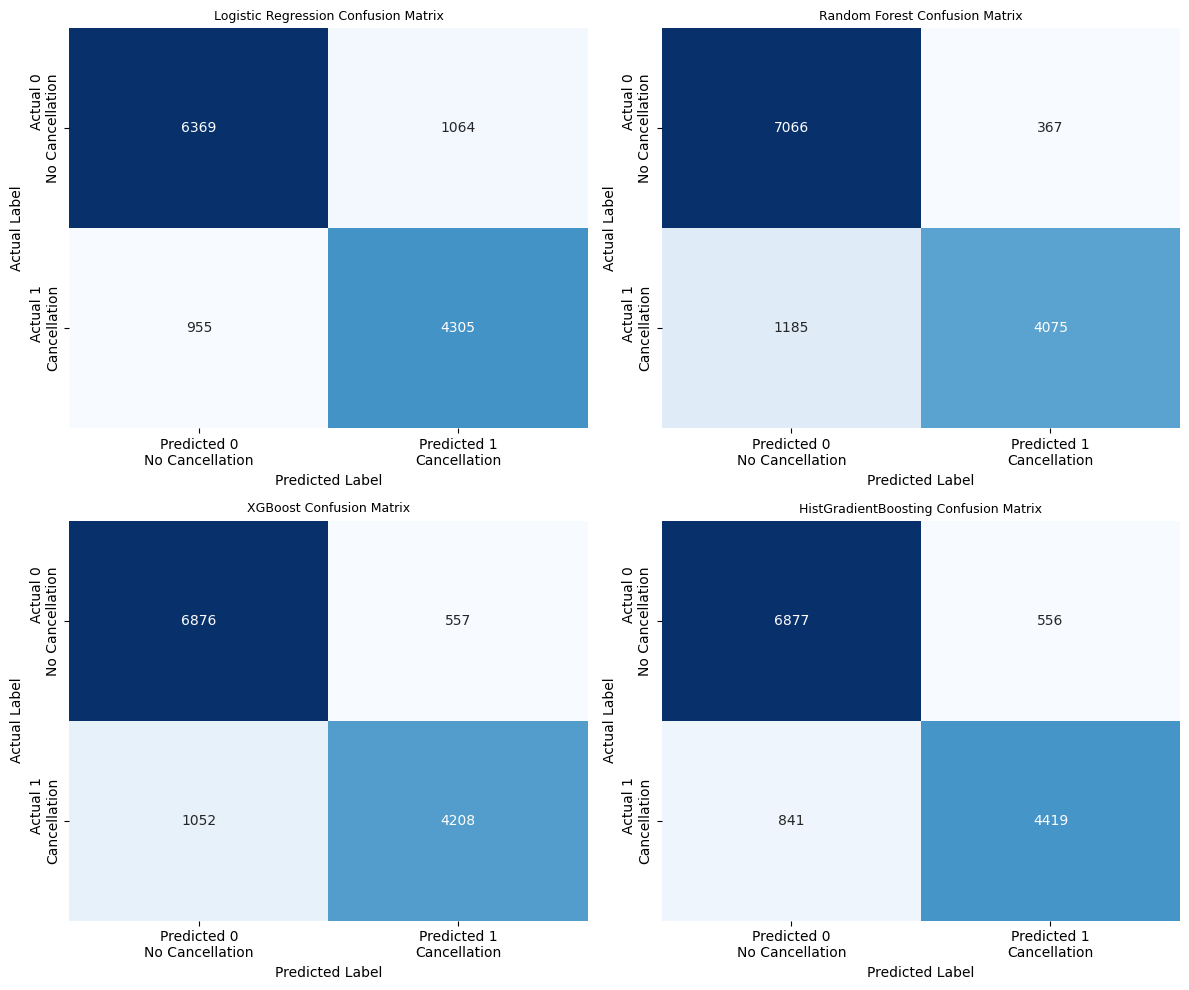

In [315]:
# ============================================================
# Confusion Matrix Plots
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted 0\nNo Cancellation", "Predicted 1\nCancellation"],
        yticklabels=["Actual 0\nNo Cancellation", "Actual 1\nCancellation"],
        ax=ax
    )

    ax.set_title(f"{model_name} Confusion Matrix")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

The confusion matrix comparison provides a more detailed view of the types of errors made by each model at the default threshold of `0.5`.

Across all models, the total number of actual cancellations in the holdout validation set is `5,260`. Therefore, the number of false negatives directly indicates how many actual cancellations each model failed to identify.

`HistGradientBoosting` produced the lowest number of false negatives, with `841` missed cancellations. This means it correctly identified `4,419` actual cancellations, which is the strongest cancellation-detection performance among the compared models.

`Random Forest` produced the lowest number of false positives, with only `369` non-cancelled observations incorrectly predicted as cancellations. This explains its high precision. However, it also produced the highest number of false negatives, missing `1,186` actual cancellations. In the business context of this project, this is less desirable because missed cancellations may lead to unnecessary allocation of infrastructure, equipment, catering, and operational resources.

`XGBoost` showed a balanced confusion matrix, with fewer false positives than HistGradientBoosting but more missed cancellations. It missed `1,045` actual cancellations, which is higher than HistGradientBoosting.

`Logistic Regression` identified many actual cancellations, but it also produced the highest number of false positives, with `1,059` non-cancelled observations incorrectly classified as cancellations. This makes it less operationally efficient, because it may create too many false alarms.

Overall, the confusion matrices support the conclusion from the classification metrics. `HistGradientBoosting` provides the best balance for this business problem: it achieves strong overall performance while minimizing false negatives more effectively than the other models. Since identifying actual cancellations is especially important in this context, this strengthens `HistGradientBoosting` as the leading model before the final selection stage.

## ROC Curve Comparison on Holdout Validation Set

In this section, we visualize the ROC curves of the tuned models on the holdout validation set.

The ROC curve shows the tradeoff between the true positive rate and the false positive rate across different classification thresholds. Since the project focuses on predicting cancellation probabilities, this visualization helps compare how well each model ranks cancelled observations above non-cancelled observations.

The curves are based only on the holdout validation set, which was not used during hyperparameter tuning.

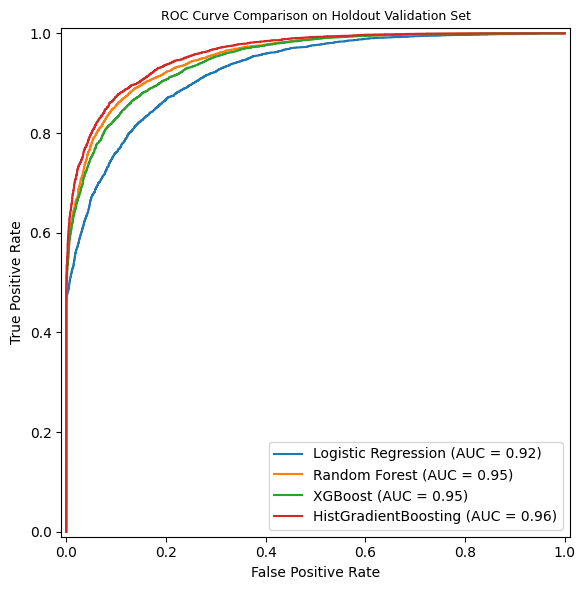

In [316]:
# ============================================================
# ROC Curve Comparison on Holdout Validation Set
# ============================================================

holdout_proba_predictions = {}

plt.figure(figsize=(8, 6))

for model_name, pipeline in best_tuned_pipelines.items():

    y_val_proba = pipeline.predict_proba(X_val)[:, 1]
    holdout_proba_predictions[model_name] = y_val_proba

    RocCurveDisplay.from_predictions(
        y_val,
        y_val_proba,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curve Comparison on Holdout Validation Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

The ROC curve comparison confirms the holdout validation results.

`HistGradientBoosting` achieved the strongest ROC curve, with a holdout validation ROC-AUC of approximately `0.960`. It is followed by `Random Forest` with approximately `0.952`, `XGBoost` with approximately `0.947`, and `Logistic Regression` with approximately `0.924`.

The tree-based ensemble models outperform the linear Logistic Regression baseline across most of the ROC curve. This supports the conclusion that non-linear relationships and feature interactions are important for predicting course cancellation.

Among the ensemble models, `HistGradientBoosting` provides the best ranking ability on the holdout validation set. Since it also achieved the highest mean cross-validation ROC-AUC, it remains the leading candidate for the final model.

The strong holdout validation performance suggests that the model generalizes well to unseen data, even though the cross-validation analysis showed some train-CV gap.

## Ensemble Experiment - Tree-Based Models

As an additional experiment, we test a simple soft-voting ensemble that averages the predicted cancellation probabilities from the three tuned tree-based models: Random Forest, XGBoost, and HistGradientBoosting.

This experiment does not train a new model. Instead, it combines the holdout validation probability predictions already generated by the tuned models.

We use equal weights for the three models in order to avoid tuning ensemble weights on the holdout validation set. The goal is to check whether combining different tree-based model families improves ranking performance compared with each individual model.

In [317]:
# ============================================================
# Ensemble Experiment - Tree-Based Models
# ============================================================

rf_holdout_proba = holdout_proba_predictions["Random Forest"]
xgb_holdout_proba = holdout_proba_predictions["XGBoost"]
hgb_holdout_proba = holdout_proba_predictions["HistGradientBoosting"]

tree_ensemble_holdout_proba = (
    rf_holdout_proba
    + xgb_holdout_proba
    + hgb_holdout_proba
) / 3

tree_ensemble_holdout_auc = roc_auc_score(
    y_val,
    tree_ensemble_holdout_proba
)

tree_ensemble_comparison_df = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Holdout_Validation_ROC_AUC": roc_auc_score(y_val, rf_holdout_proba)
    },
    {
        "Model": "XGBoost",
        "Holdout_Validation_ROC_AUC": roc_auc_score(y_val, xgb_holdout_proba)
    },
    {
        "Model": "HistGradientBoosting",
        "Holdout_Validation_ROC_AUC": roc_auc_score(y_val, hgb_holdout_proba)
    },
    {
        "Model": "Tree-Based Soft Ensemble",
        "Holdout_Validation_ROC_AUC": tree_ensemble_holdout_auc
    }
])

tree_ensemble_comparison_df = (
    tree_ensemble_comparison_df
    .sort_values("Holdout_Validation_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

tree_ensemble_comparison_df["Holdout_Validation_ROC_AUC"] = (
    tree_ensemble_comparison_df["Holdout_Validation_ROC_AUC"]
    .round(4)
)

tree_ensemble_comparison_df

,Model,Holdout_Validation_ROC_AUC
0,HistGradientBoosting,0.9595
1,Tree-Based Soft Ensemble,0.9574
2,Random Forest,0.9526
3,XGBoost,0.9470


In [318]:
# ============================================================
# Ensemble Overfitting Diagnostic
# ============================================================

tree_model_train_holdout_results = []

tree_model_pipelines = {
    "Random Forest": best_rf_pipeline,
    "XGBoost": best_xgb_pipeline,
    "HistGradientBoosting": best_hgb_pipeline
}

train_proba_predictions = {}

for model_name, pipeline in tree_model_pipelines.items():

    y_train_proba = pipeline.predict_proba(X_train)[:, 1]
    y_val_proba = holdout_proba_predictions[model_name]

    train_proba_predictions[model_name] = y_train_proba

    train_auc = roc_auc_score(y_train, y_train_proba)
    holdout_auc = roc_auc_score(y_val, y_val_proba)

    tree_model_train_holdout_results.append({
        "Model": model_name,
        "Train_ROC_AUC": train_auc,
        "Holdout_Validation_ROC_AUC": holdout_auc,
        "Train_Holdout_Gap": train_auc - holdout_auc
    })

# Tree-based soft ensemble
tree_ensemble_train_proba = (
    train_proba_predictions["Random Forest"]
    + train_proba_predictions["XGBoost"]
    + train_proba_predictions["HistGradientBoosting"]
) / 3

tree_ensemble_holdout_proba = (
    holdout_proba_predictions["Random Forest"]
    + holdout_proba_predictions["XGBoost"]
    + holdout_proba_predictions["HistGradientBoosting"]
) / 3

tree_model_train_holdout_results.append({
    "Model": "Tree-Based Soft Ensemble",
    "Train_ROC_AUC": roc_auc_score(y_train, tree_ensemble_train_proba),
    "Holdout_Validation_ROC_AUC": roc_auc_score(y_val, tree_ensemble_holdout_proba),
    "Train_Holdout_Gap": (
        roc_auc_score(y_train, tree_ensemble_train_proba)
        - roc_auc_score(y_val, tree_ensemble_holdout_proba)
    )
})

tree_overfitting_diagnostic_df = pd.DataFrame(tree_model_train_holdout_results)

tree_overfitting_diagnostic_df = (
    tree_overfitting_diagnostic_df
    .sort_values("Holdout_Validation_ROC_AUC", ascending=False)
    .reset_index(drop=True)
)

tree_overfitting_diagnostic_df[
    ["Train_ROC_AUC", "Holdout_Validation_ROC_AUC", "Train_Holdout_Gap"]
] = tree_overfitting_diagnostic_df[
    ["Train_ROC_AUC", "Holdout_Validation_ROC_AUC", "Train_Holdout_Gap"]
].round(4)

tree_overfitting_diagnostic_df

,Model,Train_ROC_AUC,Holdout_Validation_ROC_AUC,Train_Holdout_Gap
0,HistGradientBoosting,0.9916,0.9595,0.0321
1,Tree-Based Soft Ensemble,0.9844,0.9574,0.0270
2,Random Forest,0.9834,0.9526,0.0308
3,XGBoost,0.9511,0.9470,0.0041


The tree-based soft ensemble slightly reduced the train-holdout gap compared with the standalone HistGradientBoosting model.

The ensemble achieved a train-holdout gap of approximately `0.027`, compared with approximately `0.032` for HistGradientBoosting. This suggests that averaging the predictions of several tree-based models can slightly reduce overfitting tendency.

However, the ensemble achieved a lower holdout validation ROC-AUC, approximately `0.957`, compared with approximately `0.960` for HistGradientBoosting.

This means that the ensemble improved the generalization gap slightly, but did not improve the main evaluation metric. Since ROC-AUC is the primary metric for this project, the ensemble does not outperform the standalone HistGradientBoosting model.

Therefore, the ensemble is kept as an additional experiment, but HistGradientBoosting remains the strongest candidate for the final model selection.

## Final Model Selection After Evaluation

After evaluating all tuned models on the holdout validation set, `HistGradientBoosting` was selected as the final model.

The selection is based on the full evaluation in Part D, not only on the cross-validation results from Part C.

`HistGradientBoosting` achieved the strongest overall performance across the main evaluation criteria:

- It achieved the highest holdout validation ROC-AUC, approximately `0.960`.
- It achieved the highest accuracy, approximately `0.890`.
- It achieved the highest F1-score for the cancellation class, approximately `0.864`.
- It achieved the highest recall for the cancellation class, approximately `0.840`.
- It produced the lowest number of false negatives, missing `841` actual cancellations.

The false-negative result is especially important in this business context, because missed cancellations may lead to unnecessary allocation of infrastructure, equipment, catering, and operational resources.

Although `Random Forest` achieved higher precision, it missed more actual cancellations. `XGBoost` showed balanced performance but did not outperform `HistGradientBoosting`. Logistic Regression was useful as an interpretable baseline, but achieved lower overall performance.

The optional tree-based soft ensemble slightly reduced the train-holdout gap, but it did not improve the holdout validation ROC-AUC compared with the standalone `HistGradientBoosting` model.

Therefore, `HistGradientBoosting` provides the best overall balance between ranking performance, classification performance, and business relevance for this prediction task.

The selected model will now be analyzed more deeply using model interpretation methods, including SHAP.

In [319]:
# ============================================================
# Selected Model for Evaluation
# ============================================================

selected_model_name = "HistGradientBoosting"
selected_model_pipeline = best_hgb_pipeline

selected_model_cv_auc = best_hgb_cv_auc
selected_model_holdout_auc = roc_auc_score(
    y_val,
    selected_model_pipeline.predict_proba(X_val)[:, 1]
)

print("Selected model:", selected_model_name)
print("Selected model mean CV ROC-AUC:", selected_model_cv_auc)
print("Selected model holdout validation ROC-AUC:", selected_model_holdout_auc)

Selected model: HistGradientBoosting
Selected model mean CV ROC-AUC: 0.9557326387184885
Selected model holdout validation ROC-AUC: 0.9595018540789482


## Detailed Analysis of the Selected Model
After completing the model comparison and selecting `HistGradientBoosting` as the final model, the rest of Part D focuses on a deeper analysis of this selected model.

The goal is not to repeat the general performance comparison, but to better understand how the selected model behaves at the observation level.

The detailed analysis focuses on two questions:

1. **Prediction confidence:** Are model errors more common when the predicted cancellation probability is close to the decision threshold?
2. **Model interpretation:** Which features contribute most to the model’s cancellation predictions?

To support this analysis, we first create a validation-level dataframe containing the actual label, predicted probability, predicted class, and prediction outcome type for each observation in the holdout validation set.

In [320]:
# ============================================================
# Detailed Analysis Setup - Selected Model
# ============================================================

selected_model_name = "HistGradientBoosting"
selected_model_pipeline = best_hgb_pipeline

SELECTED_MODEL_THRESHOLD = 0.5

selected_y_val_proba = selected_model_pipeline.predict_proba(X_val)[:, 1]
selected_y_val_pred = (selected_y_val_proba >= SELECTED_MODEL_THRESHOLD).astype(int)

selected_model_validation_predictions = pd.DataFrame({
    "Actual": y_val.values,
    "Predicted": selected_y_val_pred,
    "Predicted_Probability": selected_y_val_proba
}, index=X_val.index)

def classify_prediction_outcome(row):
    if row["Actual"] == 0 and row["Predicted"] == 0:
        return "True Negative"
    elif row["Actual"] == 0 and row["Predicted"] == 1:
        return "False Positive"
    elif row["Actual"] == 1 and row["Predicted"] == 0:
        return "False Negative"
    else:
        return "True Positive"

selected_model_validation_predictions["Prediction_Outcome"] = (
    selected_model_validation_predictions
    .apply(classify_prediction_outcome, axis=1)
)

selected_model_validation_predictions["Distance_From_Threshold"] = (
    selected_model_validation_predictions["Predicted_Probability"]
    - SELECTED_MODEL_THRESHOLD
).abs()

selected_model_validation_predictions.head()

,Actual,Predicted,Predicted_Probability,Prediction_Outcome,Distance_From_Threshold
1680,1,1,0.914603,True Positive,0.414603
22463,0,1,0.771152,False Positive,0.271152
280,1,1,0.998651,True Positive,0.498651
37402,0,0,0.026898,True Negative,0.473102
1517,0,0,0.021196,True Negative,0.478804


### Prediction Confidence Analysis

In this section, we analyze the confidence level of the selected `HistGradientBoosting` model on the holdout validation set.

Since the model outputs cancellation probabilities, predictions close to the decision threshold of `0.5` are considered less confident. In these cases, a small change in the predicted probability could change the predicted class.

Predictions farther away from the threshold are considered more confident:

- Probabilities close to `0` indicate strong confidence in no cancellation.
- Probabilities close to `1` indicate strong confidence in cancellation.
- Probabilities close to `0.5` indicate lower confidence.

This analysis is diagnostic only. It does not change the classification threshold, but helps identify whether model errors are concentrated among lower-confidence predictions.

In [321]:
# ============================================================
# Prediction Confidence Analysis
# ============================================================

confidence_analysis_df = selected_model_validation_predictions.copy()

confidence_analysis_df["Correct_Prediction"] = (
    confidence_analysis_df["Actual"] == confidence_analysis_df["Predicted"]
)

confidence_analysis_df["Error"] = (
    confidence_analysis_df["Correct_Prediction"] == False
)

confidence_analysis_df["Confidence_Group"] = pd.cut(
    confidence_analysis_df["Distance_From_Threshold"],
    bins=[-np.inf, 0.10, 0.30, np.inf],
    labels=[
        "Low confidence (probability close to 0.5)",
        "Medium confidence",
        "High confidence"
    ]
)

confidence_summary_df = (
    confidence_analysis_df
    .groupby("Confidence_Group", observed=False)
    .agg(
        count=("Actual", "count"),
        mean_predicted_probability=("Predicted_Probability", "mean"),
        actual_cancellation_rate=("Actual", "mean"),
        accuracy=("Correct_Prediction", "mean"),
        error_rate=("Error", "mean"),
        false_negative_count=("Prediction_Outcome", lambda x: (x == "False Negative").sum()),
        false_positive_count=("Prediction_Outcome", lambda x: (x == "False Positive").sum())
    )
    .reset_index()
)

confidence_summary_display = confidence_summary_df.copy()

confidence_summary_display[
    [
        "mean_predicted_probability",
        "actual_cancellation_rate",
        "accuracy",
        "error_rate"
    ]
] = confidence_summary_display[
    [
        "mean_predicted_probability",
        "actual_cancellation_rate",
        "accuracy",
        "error_rate"
    ]
].round(4)

confidence_summary_display

,Confidence_Group,count,mean_predicted_probability,actual_cancellation_rate,accuracy,error_rate,false_negative_count,false_positive_count
0,Low confidence (probability close to 0.5),832,0.4959,0.5012,0.5385,0.4615,203,181
1,Medium confidence,2160,0.4628,0.4574,0.7079,0.2921,357,274
2,High confidence,9701,0.3938,0.3974,0.9606,0.0394,281,101


In [322]:
# ============================================================
# Prediction Outcomes by Confidence Group
# ============================================================

confidence_outcome_counts = pd.crosstab(
    confidence_analysis_df["Confidence_Group"],
    confidence_analysis_df["Prediction_Outcome"]
)

confidence_outcome_rates = pd.crosstab(
    confidence_analysis_df["Confidence_Group"],
    confidence_analysis_df["Prediction_Outcome"],
    normalize="index"
).round(4)

display(confidence_outcome_counts)
display(confidence_outcome_rates)

Prediction_Outcome,False Negative,False Positive,True Negative,True Positive
Confidence_Group,,,,
Low confidence (probability close to 0.5),203,181,234,214
Medium confidence,357,274,898,631
High confidence,281,101,5745,3574


Prediction_Outcome,False Negative,False Positive,True Negative,True Positive
Confidence_Group,,,,
Low confidence (probability close to 0.5),0.2440,0.2175,0.2812,0.2572
Medium confidence,0.1653,0.1269,0.4157,0.2921
High confidence,0.0290,0.0104,0.5922,0.3684


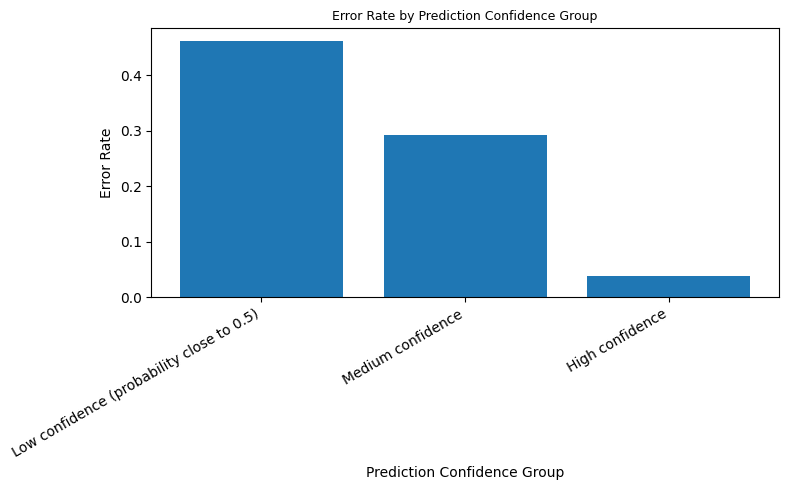

In [323]:
# ============================================================
# Error Rate by Confidence Group
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    confidence_summary_df["Confidence_Group"].astype(str),
    confidence_summary_df["error_rate"]
)

plt.title("Error Rate by Prediction Confidence Group")
plt.xlabel("Prediction Confidence Group")
plt.ylabel("Error Rate")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

The prediction confidence analysis shows that the selected model is substantially less accurate when predicted probabilities are close to the decision threshold of `0.5`.

The low-confidence group contains observations with predicted probabilities close to `0.5`. In this group, the model achieved accuracy of approximately `0.539`, with an error rate of approximately `0.462`. This indicates that when the model is uncertain, its predictions are much more likely to be incorrect.

The medium-confidence group achieved better performance, with accuracy of approximately `0.708` and an error rate of approximately `0.292`.

The high-confidence group achieved the strongest performance by far, with accuracy of approximately `0.961` and an error rate of only approximately `0.039`. This suggests that predictions far from the threshold are much more reliable.

The outcome breakdown supports this pattern. In the low-confidence group, prediction outcomes are relatively mixed, with similar proportions of true positives, true negatives, false positives, and false negatives. In contrast, the high-confidence group is dominated by correct predictions, especially true negatives and true positives, while false positives and false negatives are relatively rare.

This means that the model’s lower-confidence predictions are mainly concentrated around borderline cases where the cancellation probability is close to the decision boundary. These observations may require more cautious interpretation in a real operational setting.

Overall, the confidence analysis shows that the model provides highly reliable predictions when it assigns probabilities far from `0.5`, while predictions close to the threshold should be treated as less certain.

### SHAP Model Interpretation

In this section, we use SHAP values to interpret the selected `HistGradientBoosting` model.

SHAP values help explain how each feature contributes to the model’s prediction for each observation. A positive SHAP value means that the feature pushes the prediction toward a higher cancellation probability, while a negative SHAP value means that the feature pushes the prediction toward a lower cancellation probability.

Since the selected model is trained as part of a full pipeline, SHAP is calculated after applying the same feature engineering and preprocessing steps used during model training.

The analysis focuses on:

1. Global feature importance: which features contribute most to the model overall.
2. Direction of impact: whether feature values tend to increase or decrease the predicted cancellation risk.
3. Interpretation of the model’s main decision drivers in the business context.



In [324]:
# ============================================================
# Prepare Processed Validation Data for SHAP
# ============================================================

# Extract fitted steps from the selected model pipeline
selected_feature_engineer = selected_model_pipeline.named_steps["feature_engineering"]
selected_preprocessor = selected_model_pipeline.named_steps["preprocessor"]
selected_hgb_model = selected_model_pipeline.named_steps["model"]

# Apply the fitted feature engineering and preprocessing steps to X_val
X_val_fe_for_shap = selected_feature_engineer.transform(X_val)
X_val_processed_for_shap = selected_preprocessor.transform(X_val_fe_for_shap)

# Convert sparse matrix to dense if needed
if hasattr(X_val_processed_for_shap, "toarray"):
    X_val_processed_for_shap = X_val_processed_for_shap.toarray()

# Get processed feature names
numeric_feature_names = selected_preprocessor.transformers_[0][2]

categorical_feature_names = selected_preprocessor.transformers_[1][2]
onehot_feature_names = (
    selected_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_feature_names)
)

processed_feature_names = (
    list(numeric_feature_names)
    + list(onehot_feature_names)
)

X_val_processed_for_shap_df = pd.DataFrame(
    X_val_processed_for_shap,
    columns=processed_feature_names,
    index=X_val.index
)

print("Processed validation shape for SHAP:", X_val_processed_for_shap_df.shape)
X_val_processed_for_shap_df.head()

Processed validation shape for SHAP: (12693, 130)


,Professionals_Count,Practical_Hours,Theory_Hours,Registration_Days_Before,Waiting_List_Days,Daily_Tuition_Cost,Has_Company_ID,Course_Start_DayOfWeek,Course_Start_Month,Has_Students,Has_Observers,Has_Physical_Kits,Has_Pre_Course_Support_Tickets,Had_Previous_Attendance,Had_Previous_Dropout,Has_Any_Company_History,Had_Registration_Changes,Origin_Country_ago,Origin_Country_aus,Origin_Country_aut,Origin_Country_bel,Origin_Country_bra,Origin_Country_che,Origin_Country_chn,Origin_Country_cn,Origin_Country_cze,Origin_Country_deu,Origin_Country_dnk,Origin_Country_esp,Origin_Country_fin,Origin_Country_fra,Origin_Country_gbr,Origin_Country_hun,Origin_Country_irl,Origin_Country_isr,Origin_Country_ita,Origin_Country_jpn,Origin_Country_lux,Origin_Country_mar,Origin_Country_nld,Origin_Country_nor,Origin_Country_other_country,Origin_Country_pol,Origin_Country_prt,Origin_Country_rou,Origin_Country_rus,Origin_Country_swe,Origin_Country_tur,Origin_Country_unknown,Origin_Country_usa,Catering_Package_all inclusive,Catering_Package_lunch included,Catering_Package_no food plan,Catering_Package_standard coffee only,Catering_Package_unknown,Welcome_Gift_Type_branded notebook,Welcome_Gift_Type_portable charger,Welcome_Gift_Type_usb drive,Welcome_Gift_Type_water bottle,Enrollment_Type_affiliated admission,Enrollment_Type_contractual agreement,Enrollment_Type_general admission,Enrollment_Type_organizational arrangement,Enrollment_Type_unknown,Lanyard_Color_black,Lanyard_Color_blue,Lanyard_Color_green,Lanyard_Color_orange,Lanyard_Color_red,Client_Category_big tech & multinationals,Client_Category_defense & govtech,Client_Category_fintech & banking,Client_Category_industrial tech & iot,Client_Category_non-profit & edutech,Client_Category_saas & software houses,Client_Category_traditional it & telecomm,Client_Category_unknown,Submission_Source_b2b platforms & resellers,Submission_Source_dedicated sales team,Submission_Source_direct website registration,Submission_Source_government procurement system,Submission_Source_unknown,Agent_ID_104.0,Agent_ID_111.0,Agent_ID_118.0,Agent_ID_121.0,Agent_ID_129.0,Agent_ID_133.0,Agent_ID_138.0,Agent_ID_139.0,Agent_ID_144.0,Agent_ID_147.0,Agent_ID_158.0,Agent_ID_167.0,Agent_ID_169.0,Agent_ID_178.0,Agent_ID_184.0,Agent_ID_189.0,Agent_ID_190.0,Agent_ID_205.0,Agent_ID_217.0,Agent_ID_218.0,Agent_ID_219.0,Agent_ID_220.0,Agent_ID_222.0,Agent_ID_223.0,Agent_ID_224.0,Agent_ID_252.0,Agent_ID_258.0,Agent_ID_261.0,Agent_ID_262.0,Agent_ID_264.0,Agent_ID_277.0,Agent_ID_300.0,Agent_ID_306.0,Agent_ID_313.0,Agent_ID_314.0,Agent_ID_317.0,Agent_ID_318.0,Agent_ID_320.0,Agent_ID_321.0,Agent_ID_other_agent,Agent_ID_unknown_agent,Payment_Terms_pay upon start,Payment_Terms_prepaid non-refundable,Payment_Terms_refundable deposit,Payment_Terms_unknown,Lab_Config_Match_match,Lab_Config_Match_mismatch,Lab_Config_Match_missing
1680,0.327444,-0.880661,-0.112734,-0.215265,-0.184844,-1.018627,-0.226425,-0.513512,0.411045,-0.251927,-0.070908,-0.163253,-0.770010,-0.142755,-0.302020,-0.338522,-0.379550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
22463,0.327444,0.243916,-0.792986,0.262864,-0.184844,-0.367475,-0.226425,-1.554811,-0.783134,-0.251927,-0.070908,-0.163253,-0.770010,-0.142755,-0.302020,-0.338522,-0.379550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [325]:
# ============================================================
# Calculate SHAP Values on the Full Holdout Validation Set
# ============================================================

# SHAP is calculated on the full processed validation set.
# This is used for model interpretation only, not for model training or tuning.
X_val_shap_full = X_val_processed_for_shap_df.copy()

shap_explainer = shap.TreeExplainer(selected_hgb_model)
shap_values_raw = shap_explainer.shap_values(X_val_shap_full)

# Handle different SHAP output formats
if isinstance(shap_values_raw, list):
    shap_values_selected = shap_values_raw[1] if len(shap_values_raw) > 1 else shap_values_raw[0]
else:
    shap_values_array = np.asarray(shap_values_raw)

    if shap_values_array.ndim == 3 and shap_values_array.shape[-1] == 2:
        shap_values_selected = shap_values_array[:, :, 1]
    else:
        shap_values_selected = shap_values_array

print("SHAP data shape:", X_val_shap_full.shape)
print("SHAP values shape:", shap_values_selected.shape)

SHAP data shape: (12693, 130)
SHAP values shape: (12693, 130)


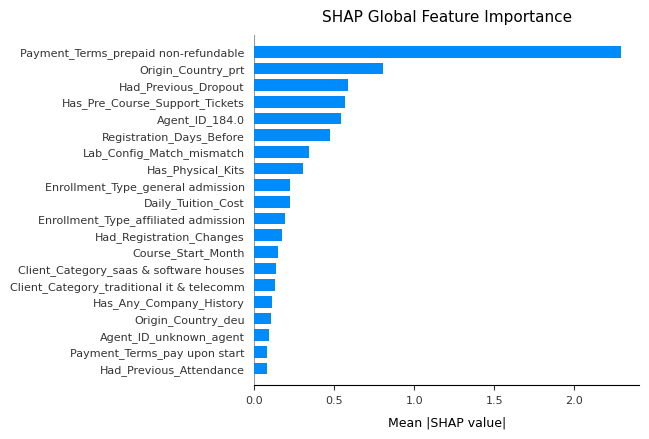

In [326]:
# ============================================================
# SHAP Global Feature Importance - Bar Plot
# ============================================================

shap.summary_plot(
    shap_values_selected,
    X_val_shap_full,
    plot_type="bar",
    max_display=20,
    show=False,
    plot_size=(7, 5)
)

fig = plt.gcf()
ax = plt.gca()

# Shorter axis label to avoid clipping in the exported notebook/PDF
ax.set_xlabel("Mean |SHAP value|", fontsize=9, labelpad=8)

# Smaller tick labels
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)

plt.title("SHAP Global Feature Importance", fontsize=11, pad=10)

# Manual margins: left for long feature names, bottom/right for x-axis label
fig.subplots_adjust(
    left=0.42,
    right=0.97,
    bottom=0.18,
    top=0.88
)

plt.show()

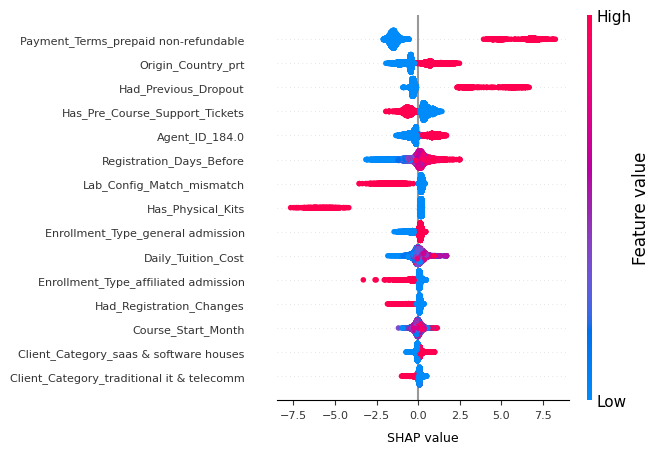

In [327]:
# ============================================================
# SHAP Summary Plot - Direction of Impact
# ============================================================

shap.summary_plot(
    shap_values_selected,
    X_val_shap_full,
    max_display=15,
    show=False,
    plot_size=(7, 5)
)

fig = plt.gcf()
ax = plt.gca()

# Shorter x-axis label to avoid clipping
ax.set_xlabel("SHAP value", fontsize=9, labelpad=8)

# Smaller tick labels
ax.tick_params(axis="x", labelsize=8)
ax.tick_params(axis="y", labelsize=8)

# Adjust margins:
# left  - long feature names
# right - color bar
# bottom - x-axis label
fig.subplots_adjust(
    left=0.36,
    right=0.88,
    bottom=0.18,
    top=0.95
)

plt.show()

In [328]:
# ============================================================
# SHAP Feature Importance Table
# ============================================================

shap_importance_df = pd.DataFrame({
    "Processed_Feature": X_val_shap_full.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values_selected).mean(axis=0)
})

shap_importance_df = (
    shap_importance_df
    .sort_values("Mean_Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

shap_importance_df.head(20)

,Processed_Feature,Mean_Absolute_SHAP
0,Payment_Terms_prepaid non-refundable,2.291630
1,Origin_Country_prt,0.801938
2,Had_Previous_Dropout,0.582692
3,Has_Pre_Course_Support_Tickets,0.563470
4,Agent_ID_184.0,0.543367
5,Registration_Days_Before,0.472722
6,Lab_Config_Match_mismatch,0.338166
7,Has_Physical_Kits,0.303372
8,Enrollment_Type_general admission,0.223433
9,Daily_Tuition_Cost,0.221316


In [329]:
# ============================================================
# Group SHAP Importance Back to Original Feature Names
# ============================================================

def map_processed_feature_to_original(feature_name):

    if feature_name in numeric_feature_names:
        return feature_name

    for original_cat_feature in sorted(categorical_feature_names, key=len, reverse=True):
        prefix = original_cat_feature + "_"
        if feature_name.startswith(prefix):
            return original_cat_feature

    return feature_name

shap_importance_df["Original_Feature"] = (
    shap_importance_df["Processed_Feature"]
    .apply(map_processed_feature_to_original)
)

grouped_shap_importance_df = (
    shap_importance_df
    .groupby("Original_Feature", as_index=False)
    .agg(
        Total_Mean_Absolute_SHAP=("Mean_Absolute_SHAP", "sum"),
        Number_of_Processed_Features=("Processed_Feature", "count")
    )
    .sort_values("Total_Mean_Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

grouped_shap_importance_df.head(20)

,Original_Feature,Total_Mean_Absolute_SHAP,Number_of_Processed_Features
0,Payment_Terms,2.373292,4
1,Origin_Country,1.205243,33
2,Agent_ID,0.888608,41
3,Had_Previous_Dropout,0.582692,1
4,Has_Pre_Course_Support_Tickets,0.563470,1
5,Registration_Days_Before,0.472722,1
6,Enrollment_Type,0.457056,5
7,Lab_Config_Match,0.395600,3
8,Client_Category,0.366670,8
9,Has_Physical_Kits,0.303372,1


The SHAP analysis provides insight into the main drivers of the selected `HistGradientBoosting` model.

The most influential feature group is `Payment_Terms`, and the strongest individual processed feature is `Payment_Terms_prepaid non-refundable`. This is consistent with the EDA, where payment terms showed a strong relationship with course cancellation. The SHAP results suggest that the model relies heavily on payment-term information when estimating cancellation risk.

`Origin_Country` is also highly influential, especially specific country indicators such as `Origin_Country_prt`. This indicates that cancellation risk differs across country groups. Since this feature is one-hot encoded, the grouped importance combines the contribution of several country indicators.

`Agent_ID` is another important grouped feature , with Agent_ID_184.0 being its most influential individual category. This suggests that different agents are associated with different cancellation patterns. However, this should be interpreted carefully: `Agent_ID` is an identifier-like categorical feature, so its importance reflects historical patterns associated with agents rather than a direct causal relationship.

Several engineered features from Part B also appear among the most important predictors. These include `Has_Pre_Course_Support_Tickets`, `Had_Previous_Dropout`, `Registration_Days_Before`, `Lab_Config_Match`, and `Has_Physical_Kits`. This supports the feature-engineering decisions made earlier, since the model uses these derived variables as meaningful predictors.

The SHAP results also show that both operational features and customer-history features contribute to the model’s predictions. For example, previous dropout history, support-ticket activity, registration timing, lab-configuration match status, and physical-kit requirements all help explain cancellation-risk predictions.

When interpreting the grouped SHAP table, it is important to note that some original features, such as `Origin_Country` and `Agent_ID`, are represented by many one-hot encoded columns. Their grouped SHAP importance is therefore the total contribution across multiple encoded categories. In contrast, features such as `Had_Previous_Dropout`, `Has_Pre_Course_Support_Tickets` or `Registration_Days_Before` appear as single processed features.

Overall, the SHAP analysis confirms that the selected model does not rely solely on a single feature. Instead, its predictions are driven by a combination of payment behavior, geographic patterns, agent-related historical patterns, registration timing, operational requirements, and client-history indicators.

These findings support the interpretability of the final model and help explain why `HistGradientBoosting` achieved strong predictive performance on the holdout validation set.

## Summary

In Part D, we evaluated the tuned models from Part C on the holdout validation set and analyzed their performance using both ranking-based and threshold-based evaluation methods.

The holdout validation evaluation showed that `HistGradientBoosting` achieved the highest ROC-AUC, approximately `0.960`, followed by `Random Forest`, `XGBoost`, and `Logistic Regression`. This confirmed that the strongest cross-validation model from Part C also generalized well to unseen validation data.

In addition to ROC-AUC, the models were compared using accuracy, precision, recall, F1-score, and confusion matrices. This was important because the business goal is not only to rank cancellation risk, but also to understand how the model performs when predictions are converted into cancellation / no-cancellation decisions.

The classification metrics and confusion matrix comparison showed that `HistGradientBoosting` provided the best overall balance. It achieved the highest accuracy, the highest F1-score for the cancellation class, and the highest recall for actual cancellations. It also produced the lowest number of false negatives, missing `841` actual cancellations.

This is especially important in the business context, because missed cancellations may lead to unnecessary allocation of infrastructure, equipment, catering, and operational resources.

A simple tree-based soft ensemble was also tested as an additional experiment. Although the ensemble slightly reduced the train-holdout gap, it did not improve the holdout validation ROC-AUC compared with the standalone `HistGradientBoosting` model. Therefore, the ensemble was not selected as the final model.

After the full evaluation, `HistGradientBoosting` was selected as the final model.

The prediction confidence analysis showed that model errors are concentrated mainly among observations with predicted probabilities close to the decision threshold of `0.5`. High-confidence predictions, where probabilities are far from the threshold, were substantially more accurate.

Finally, SHAP analysis was used to interpret the selected model. The most influential features included `Payment_Terms`, `Origin_Country`, `Agent_ID`, `Has_Pre_Course_Support_Tickets`, `Had_Previous_Dropout`, `Registration_Days_Before`, and `Lab_Config_Match`. These results show that the model relies on a combination of payment behavior, geographic patterns, agent-related historical patterns, registration timing, operational requirements, and client-history indicators.

Overall, Part D confirms that `HistGradientBoosting` is both the strongest-performing model and an interpretable final choice for predicting course cancellation probability.

# Part E - Final Summary

### Final Model Summary

After training, tuning, and evaluating multiple classification models, `HistGradientBoosting` was selected as the final model for generating predictions on the external test dataset.

The model was selected after the full evaluation process in Part D. It achieved the strongest overall performance on the holdout validation set, including:

- Holdout validation ROC-AUC of approximately `0.960`
- Accuracy of approximately `0.890`
- Precision for the cancellation class of approximately `0.888`
- Recall for the cancellation class of approximately `0.840`
- F1-score for the cancellation class of approximately `0.864`

The model also produced the lowest number of false negatives among the compared models, missing `841` actual cancellations on the holdout validation set. This is important in the business context because missed cancellations may lead to unnecessary allocation of infrastructure, equipment, catering, and operational resources.

A tree-based soft ensemble was also tested, but it did not improve the holdout validation ROC-AUC compared with the standalone `HistGradientBoosting` model. Therefore, the ensemble was kept as an additional experiment but was not selected as the final model.

The SHAP analysis showed that the final model relies on a combination of payment behavior, geographic patterns, agent-related historical patterns, registration timing, operational requirements, and client-history indicators. Important feature groups included `Payment_Terms`, `Origin_Country`, `Agent_ID`, `Has_Pre_Course_Support_Tickets`, `Had_Previous_Dropout`, `Registration_Days_Before`, and `Lab_Config_Match`.

After final model selection, the model is retrained on the full available labeled training data before generating predictions for the external test dataset. This allows the final submission model to use all available labeled observations while keeping the model architecture and hyperparameters fixed based on the tuning and evaluation process.

In [330]:
# ============================================================
# Create Full Labeled Training Data
# ============================================================

X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)
print("Target distribution in y_full:")
print(y_full.value_counts(normalize=True))

X_full shape: (63464, 28)
y_full shape: (63464,)
Target distribution in y_full:
Dropped_Course
0    0.585608
1    0.414392
Name: proportion, dtype: float64


In [331]:
# ============================================================
# Create Dense Preprocessor for Final Submission Model
# ============================================================

# Preview feature-engineered full training data to identify final column types
final_feature_engineer_preview = CustomFeatureEngineer(
    min_country_count=100,
    min_agent_count=100,
    waiting_cap_percentile=0.95
)

X_full_fe_preview = final_feature_engineer_preview.fit_transform(X_full)

final_numeric_features = (
    X_full_fe_preview
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

final_categorical_features = (
    X_full_fe_preview
    .select_dtypes(include=["object", "string"])
    .columns
    .tolist()
)

print("Number of final numeric features:", len(final_numeric_features))
print("Number of final categorical features:", len(final_categorical_features))

# Dense OneHotEncoder, compatible with different sklearn versions
try:
    dense_onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    dense_onehot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

numeric_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", dense_onehot_encoder)
])

preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_dense, final_numeric_features),
        ("cat", categorical_transformer_dense, final_categorical_features)
    ]
)

print("Dense preprocessor was created successfully.")

Number of final numeric features: 17
Number of final categorical features: 10
Dense preprocessor was created successfully.


In [332]:
# ============================================================
# Train Final Submission Model on Full Training Data
# ============================================================

final_submission_pipeline = Pipeline(steps=[
    ("feature_engineering", CustomFeatureEngineer(
        min_country_count=100,
        min_agent_count=100,
        waiting_cap_percentile=0.95
    )),
    ("preprocessor", preprocessor_dense),
    ("model", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=127,
        l2_regularization=0.1,
        random_state=42
    ))
])

final_submission_pipeline.fit(X_full, y_full)

print("Final submission pipeline was trained on the full available labeled training data.")

Final submission pipeline was trained on the full available labeled training data.


In [333]:
# ============================================================
# Generate Predictions for Test Data
# ============================================================

test_df = pd.read_csv("Test_Data_No_Target.csv")

# Save Client_ID for submission
test_client_ids = test_df["Client_ID"].copy()

# Predict cancellation probabilities using the final pipeline
test_proba = final_submission_pipeline.predict_proba(test_df)[:, 1]

# Create submission file
submission = pd.DataFrame({
    "Client_ID": test_client_ids,
    "Drop_Probability": test_proba
})

submission.head()

,Client_ID,Drop_Probability
0,62246,0.078480
1,43031,0.999921
2,26571,0.096563
3,77694,0.999921
4,22185,0.107608


In [334]:
# ============================================================
# Create Full Labeled Training Data
# ============================================================

X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)
print("Target distribution in y_full:")
print(y_full.value_counts(normalize=True))

X_full shape: (63464, 28)
y_full shape: (63464,)
Target distribution in y_full:
Dropped_Course
0    0.585608
1    0.414392
Name: proportion, dtype: float64


In [336]:
# ============================================================
# Save and Validate Submission File
# ============================================================

submission.to_csv(
    "Group_04_Submission.csv",
    index=False
)

print("Submission shape:", submission.shape)
print("Probabilities between 0 and 1:", submission["Drop_Probability"].between(0, 1).all())
print("Missing probabilities:", submission["Drop_Probability"].isna().sum())
print("Missing Client IDs:", submission["Client_ID"].isna().sum())
print("Unique Client IDs:", submission["Client_ID"].nunique())
print("Total rows:", len(submission))
print("Submission columns:", submission.columns.tolist())

submission.head()

Submission shape: (15866, 2)
Probabilities between 0 and 1: True
Missing probabilities: 0
Missing Client IDs: 0
Unique Client IDs: 15866
Total rows: 15866
Submission columns: ['Client_ID', 'Drop_Probability']


,Client_ID,Drop_Probability
0,62246,0.078480
1,43031,0.999921
2,26571,0.096563
3,77694,0.999921
4,22185,0.107608
